# Stock Price Prediction

In [1]:
# ============================
# Simplified paper replication
# Strategy-embedded loss + PBWA weighting
# Using free OHLCV from yfinance
# ============================

import os
import math
import random
import numpy as np
import pandas as pd

import yfinance as yf

import torch
import torch.nn as nn
from torch.optim import Adam


## 1. Experiment setup for Reproducibility

In [2]:
# ----------------------------
# Reproducibility
# ----------------------------
def set_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seeds(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Data acquisition & ingestion (universe definition included)

In [3]:
# ----------------------------
# Universe: S&P500 tickers (free) -> Data acquisition and universe definition
# ----------------------------

def load_sp500_tickers_yf():
    t = yf.Ticker("^GSPC")
    tickers = list(t.constituents.keys()) if getattr(t, "constituents", None) else None
    if not tickers:
        raise RuntimeError("yfinance constituents not available in your version.")
    return [x.replace(".", "-") for x in tickers]

In [4]:
# ----------------------------
# Data download (OHLCV) -> data ingestion / raw data acquisition
# ----------------------------
def download_ohlcv(tickers, start="2010-01-01", end="2024-01-31", auto_adjust=False):
    """
    Returns: dict with keys Open, High, Low, Close, Volume as DataFrames [date x ticker]
    yfinance can be flaky; download in chunks.
    """
    if end is None:
        end = pd.Timestamp.today().strftime("%Y-%m-%d")

    chunks = []
    chunk_size = 100
    for i in range(0, len(tickers), chunk_size):
        chunks.append(tickers[i:i+chunk_size])

    frames = []
    for ch in chunks:
        data = yf.download(
            ch, start=start, end=end, auto_adjust=auto_adjust,
            group_by="column", threads=True, progress=False
        )
        # If multiple tickers, columns are MultiIndex: (field, ticker)
        if isinstance(data.columns, pd.MultiIndex):
            frames.append(data)
        else:
            # single ticker edge case
            data.columns = pd.MultiIndex.from_product([data.columns, ch])
            frames.append(data)

    data = pd.concat(frames, axis=1).sort_index()
    out = {}
    for field in ["Open", "High", "Low", "Close", "Volume"]:
        out[field] = data[field].copy()
    return out

In [5]:
# ----------------------------
# Main runner -> data prep / universe selection
# ----------------------------
def load_default_tickers_minimal():
    # A small, liquid starter set (expand as you like).
    tickers = [
        "AAPL","MSFT","AMZN","NVDA","GOOGL","META","BRK-B","JPM","XOM","UNH",
        "V","MA","LLY","AVGO","COST","PG","HD","ABBV","KO","PEP",
        "ADBE","CRM","WMT","CSCO","ACN","MCD","TMO","ABT","INTC","NFLX"
    ]
    return [t.replace(".", "-") for t in tickers]

## 3. Universe selection & preprocessing

In [6]:
# ----------------------------
# Liquidity filter (avg dollar volume) -> data preprocessing / universe selection, esta version puede causar overlap y en vez de usar los 20 usa solo 17 pero no porque detecta lo mejor 
# si no por overlap
# ----------------------------
def make_universe_mask(
    data,
    tickers,
    top_n=21,
    short_w=60,        # short-term liquidity window
    long_w=252,        # long-term baseline for "becoming important"
    core_frac=0.70,    # 80% slots = absolute liquidity (stable tradability)
    min_dolv=1e6,      # minimum long-term $ volume to avoid microcap noise
    eps=1e-12,
):
    """
    Returns a boolean DataFrame mask[date, ticker] indicating whether ticker is in the tradable universe at date t.
    Causal at open: uses Close.shift(1) and Volume.shift(1) so universe at t only uses info up to t-1.

    Universe design:
      - CORE bucket: top core_n by trailing (short_w) dollar volume
      - GROWTH bucket: top growth_n by liquidity acceleration (log(dolv_short) - log(dolv_long)),
        but only if dolv_long >= min_dolv (to avoid tiny illiquid names).
    """
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu  # daily $ volume (lagged)

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    core_n = max(1, int(round(top_n * core_frac)))
    growth_n = max(0, top_n - core_n)

    # CORE: strongest absolute liquidity
    core_rank = dolv_short.rank(axis=1, ascending=False, method="first")
    core_mask = core_rank.le(core_n)

    if growth_n > 0:
        dolv_long = dolv1.rolling(long_w, min_periods=long_w).mean()
        # "becoming important": liquidity acceleration vs its own history
        growth_score = (np.log(dolv_short + eps) - np.log(dolv_long + eps))

        # guardrail: only consider names that are at least somewhat tradable long-term
        eligible = dolv_long.ge(min_dolv)

        growth_rank = growth_score.where(eligible).rank(axis=1, ascending=False, method="first")
        growth_mask = growth_rank.le(growth_n)
    else:
        growth_mask = core_mask & False  # all False, same shape

    mask = (core_mask | growth_mask).fillna(False)
    return mask


# ----------------------------
# Liquidity filter v2 (buffered / threshold) -> universe selection
# ----------------------------
def make_universe_mask_v2(
    data,
    tickers,
    target_n=21,
    short_w=60,
    min_dolv_short=5e6,      # minimum trailing $ volume (lagged)
    buffer_mult=1.5,         # allow more than target_n names (captures "missed" opportunities)
    cap_max_names=None,      # hard cap if you want
    eps=1e-12,
):
    """
    A more permissive liquidity universe that avoids over-pruning when len(tickers) >> target_n.

    Idea:
      - Compute trailing short_w avg dollar volume (lagged).
      - Keep ALL names above a minimum $-volume threshold (min_dolv_short),
        but also (optionally) cap the daily universe to a buffered top-K by liquidity:
          K = ceil(buffer_mult * target_n)
      - This keeps tradability, while giving the model a bigger opportunity set than a strict top-N.

    Returns mask[date, ticker] (bool).
    """
    target_n = int(max(1, target_n))
    close = data["Close"][tickers].shift(1)
    volu  = data["Volume"][tickers].shift(1)
    dolv1 = close * volu

    dolv_short = dolv1.rolling(short_w, min_periods=short_w).mean()

    eligible = dolv_short.ge(min_dolv_short)

    # Buffered cap by liquidity rank (optional)
    K = int(np.ceil(buffer_mult * target_n))
    if cap_max_names is not None:
        K = int(min(K, cap_max_names))

    if K is not None and K > 0:
        rank = dolv_short.rank(axis=1, ascending=False, method="first")
        topk = rank.le(K)
        mask = (eligible & topk).fillna(False)
    else:
        mask = eligible.fillna(False)

    return mask


## 4. Feature engineering & label construction

In [7]:
# ----------------------------
# Features (all shifted by 1 day) -> feature engineering / technical indicators
# ----------------------------
def rsi(close: pd.DataFrame, window: int = 14):
    delta = close.diff()
    up = delta.clip(lower=0)
    down = (-delta).clip(lower=0)
    roll_up = up.rolling(window, min_periods=window).mean()
    roll_down = down.rolling(window, min_periods=window).mean()
    rs = roll_up / (roll_down + 1e-12)
    return 100 - (100 / (1 + rs))

In [8]:
def cs_zscore(df: pd.DataFrame, eps: float = 1e-12) -> pd.DataFrame:
    mu = df.mean(axis=1)
    sd = df.std(axis=1, ddof=0)
    return df.sub(mu, axis=0).div(sd + eps, axis=0)

def close_location_value(high, low, close, eps: float = 1e-12):
    # CLV in [-1, 1]
    rng = (high - low).replace(0, np.nan)
    clv = ((close - low) - (high - close)) / (rng + eps)
    return clv.fillna(0.0)

def upper_wick_ratio(open_, high, low, close, eps: float = 1e-12):
    body_top = np.maximum(open_, close)
    rng = (high - low).replace(0, np.nan)
    return ((high - body_top) / (rng + eps)).fillna(0.0)

def lower_wick_ratio(open_, high, low, close, eps: float = 1e-12):
    body_bottom = np.minimum(open_, close)
    rng = (high - low).replace(0, np.nan)
    return ((body_bottom - low) / (rng + eps)).fillna(0.0)

In [9]:
def add_batch_intraday_lagged(feats: dict, data: dict) -> dict:
    open_ = data["Open"]
    high = data["High"]
    low = data["Low"]
    close = data["Close"]
    volu = data["Volume"]

    out = dict(feats)

    # prior-day overnight gap: O_{t-1}/C_{t-2} - 1
    gap = open_ / close.shift(1) - 1.0
    out["gap_lag1"] = gap.shift(1)

    # prior-day intraday return: C_{t-1}/O_{t-1} - 1
    intraday_ret = close / open_ - 1.0
    out["intraday_ret_lag1"] = intraday_ret.shift(1)

    # prior-day high-low range relative to open
    hl_range = (high - low) / (open_ + 1e-12)
    out["hl_range_lag1"] = hl_range.shift(1)

    # prior-day close location value
    clv = close_location_value(high, low, close)
    out["clv_lag1"] = clv.shift(1)

    # prior-day wick structure
    out["upper_wick_lag1"] = upper_wick_ratio(open_, high, low, close).shift(1)
    out["lower_wick_lag1"] = lower_wick_ratio(open_, high, low, close).shift(1)

    return out

In [11]:
def add_batch_cross_sectional(feats: dict) -> dict:
    out = dict(feats)

    base_names = [
        "mom252", "vol20", "volz20",
        "intraday_ret_lag1", "hl_range_lag1", "clv_lag1"
    ]

    for name in base_names:
        if name in out:
            out[f"{name}_z"] = cs_zscore(out[name])

    return out

In [12]:
def download_context_data(start="2010-01-01", end=None): #2024-01-31
    context_tickers = [
        "^N225",    # Japan
        "^GDAXI",   # Germany
        "^FTSE",    # UK
        "^VIX",     # volatility
        "^TNX",     # US 10Y yield proxy
        "CL=F",     # crude oil
        "GC=F",     # gold
        "DX-Y.NYB", # dollar index
    ]
    return download_ohlcv(context_tickers, start=start, end=end, auto_adjust=True)

In [13]:
def align_context_to_equity_index(context_series: pd.Series, target_index: pd.Index) -> pd.Series:
    return context_series.reindex(target_index).ffill()

def add_batch_structural(feats: dict, context_data: dict, target_index: pd.Index) -> dict:
    out = dict(feats)
    close_ctx = context_data["Close"].sort_index()
    ctx_ret = close_ctx.pct_change()

    mapping = {
        "nikkei_ret": "^N225",
        "dax_ret": "^GDAXI",
        "ftse_ret": "^FTSE",
        "vix_ret": "^VIX",
        "tnx_ret": "^TNX",
        "oil_ret": "CL=F",
        "gold_ret": "GC=F",
        "dxy_ret": "DX-Y.NYB",
    }

    for feat_name, tk in mapping.items():
        if tk in ctx_ret.columns:
            s = align_context_to_equity_index(ctx_ret[tk], target_index).shift(1)
            # Broadcast same daily context to all stocks
            out[feat_name] = pd.DataFrame(
                np.repeat(s.values[:, None], len(next(iter(feats.values())).columns), axis=1),
                index=target_index,
                columns=next(iter(feats.values())).columns,
            )

    return out

In [14]:
def add_batch_interactions(feats: dict) -> dict:
    out = dict(feats)

    interactions = [
        ("gap_lag1", "nikkei_ret"),
        ("clv_lag1", "vix_ret"),
        ("mom252_z", "oil_ret"),
        ("vol20_z", "dxy_ret"),
        ("intraday_ret_lag1_z", "dax_ret"),
    ]

    for a, b in interactions:
        if a in out and b in out:
            out[f"{a}__x__{b}"] = out[a] * out[b]

    return out

In [15]:
def _normalize_feature_batches(feature_batches):
    """
    Normalize the feature_batches argument to a clean ordered list.
    Valid names:
      - "intraday_lagged"
      - "cross_sectional"
      - "structural"
      - "interactions"
    """
    valid = {"intraday_lagged", "cross_sectional", "structural", "interactions"}

    if feature_batches is None:
        return []

    if isinstance(feature_batches, str):
        feature_batches = [feature_batches]

    feature_batches = [str(x).strip().lower() for x in feature_batches]

    bad = [x for x in feature_batches if x not in valid]
    if bad:
        raise ValueError(f"Unknown feature batch(es): {bad}. Valid: {sorted(valid)}")

    # interactions depend on structural and/or cross-sectional features
    if "interactions" in feature_batches and "intraday_lagged" not in feature_batches:
        # interactions use intraday features in the examples, so add dependency automatically
        feature_batches = ["intraday_lagged"] + feature_batches

    # keep order but remove duplicates
    out = []
    seen = set()
    for x in feature_batches:
        if x not in seen:
            out.append(x)
            seen.add(x)
    return out

In [16]:
def make_features(data, feature_batches=None, context_data=None):
    """
    Base features + optional feature batches.

    Parameters
    ----------
    data : dict
        OHLCV dict from download_ohlcv()
    feature_batches : list[str] or None
        Any subset of:
          - "intraday_lagged"
          - "cross_sectional"
          - "structural"
          - "interactions"
    context_data : dict or None
        Optional OHLCV dict for structural context variables (downloaded separately)

    Returns
    -------
    feats : dict[str, pd.DataFrame]
    y : pd.DataFrame
    """
    feature_batches = _normalize_feature_batches(feature_batches)

    close = data["Close"]
    open_ = data["Open"]
    high = data["High"]
    low = data["Low"]
    volu = data["Volume"]

    # Target: same-day open->close return
    y = (close / open_) - 1.0

    # Base features
    cc = close.pct_change()

    mom20 = close / close.shift(20) - 1
    mom60 = close / close.shift(60) - 1
    mom252 = close / close.shift(252) - 1
    rev5 = close / close.shift(5) - 1

    vol20 = cc.rolling(20, min_periods=20).std(ddof=0)

    ma20 = close.rolling(20, min_periods=20).mean()
    ma60 = close.rolling(60, min_periods=60).mean()
    prc_ma20 = close / (ma20 + 1e-12) - 1
    prc_ma60 = close / (ma60 + 1e-12) - 1

    vma20 = volu.rolling(20, min_periods=20).mean()
    vsd20 = volu.rolling(20, min_periods=20).std(ddof=0)
    volz20 = (volu - vma20) / (vsd20 + 1e-12)

    rsi14 = rsi(close, 14) / 100.0

    feats = {
        "mom20": mom20,
        "mom60": mom60,
        "mom252": mom252,
        "rev5": rev5,
        "vol20": vol20,
        "prc_ma20": prc_ma20,
        "prc_ma60": prc_ma60,
        "volz20": volz20,
        "rsi14": rsi14,
    }

    # Shift base features by 1 day so they are known before today's open
    feats = {k: v.shift(1) for k, v in feats.items()}

    # ----------------------------
    # Optional feature batches
    # ----------------------------
    if "intraday_lagged" in feature_batches:
        feats = add_batch_intraday_lagged(feats, data)

    if "cross_sectional" in feature_batches:
        feats = add_batch_cross_sectional(feats)

    if "structural" in feature_batches:
        if context_data is None:
            raise ValueError("feature_batches includes 'structural' but context_data was not provided.")
        feats = add_batch_structural(feats, context_data, y.index)

    if "interactions" in feature_batches:
        # interactions often depend on structural features
        if "structural" not in feature_batches:
            raise ValueError("feature_batches includes 'interactions' but 'structural' is not enabled.")
        feats = add_batch_interactions(feats)

    return feats, y

## 5. Dataset preparation & batching

In [17]:
# ----------------------------
# Build day-batches of sequences -> data preparation / batching,
# ----------------------------
def build_day_batches(feats_dict, y, tickers, seq_len=20, start_date=None, end_date=None, universe_mask=None, min_names=20):


    """
    For each date t, we create X: [n_stocks, seq_len, n_features], Y: [n_stocks]
    Sequences are constructed from shifted features, so they end at t (feature at t uses info up to t-1).
    """
    feat_names = list(feats_dict.keys())
    dates = y.index

    if start_date is not None:
        dates = dates[dates >= pd.to_datetime(start_date)]
    if end_date is not None:
        dates = dates[dates <= pd.to_datetime(end_date)]

    # Stack features into (date x ticker x feat)
    # We'll keep in pandas for alignment then convert per day.
    F = []
    for fn in feat_names:
        df = feats_dict[fn][tickers]
        F.append(df)
    # shape: list of DFs
    # We'll fetch rolling windows per ticker per day.
    # Efficient enough for ~200 tickers, ~3000 days.

    batches = []
    for t in dates:
        # Need seq_len rows ending at t
        idx_pos = y.index.get_loc(t)
        if idx_pos < seq_len:
            continue
        window_dates = y.index[idx_pos - seq_len + 1 : idx_pos + 1]

        # Build X for all tickers: [n, seq_len, f]
        X_list = []
        for fn in feat_names:
            X_list.append(feats_dict[fn].loc[window_dates, tickers].values[:, :])
        X = np.stack(X_list, axis=-1)  # [seq_len, n, f]
        X = np.transpose(X, (1, 0, 2)) # [n, seq_len, f]

        Y = y.loc[t, tickers].values  # [n]

        # Drop tickers with any NaNs in sequence or label
        # Drop tickers with any NaNs in sequence or label
        mask = np.isfinite(Y)
        mask &= np.isfinite(X).all(axis=(1, 2))

        # NEW: apply dynamic universe membership at date t
        if universe_mask is not None:
            um = universe_mask.loc[t, tickers].values
            um = np.asarray(um, dtype=bool)
            mask &= um

        if mask.sum() < min_names:
            continue

        # inside build_day_batches, right before append
        tks_masked = list(np.array(tickers)[mask])
        batches.append((t, X[mask], Y[mask], tks_masked))


    return batches, feat_names

## 6. Model architecture

In [18]:
# ----------------------------
# Model: LSTM -> scalar return -> model architecture
# ----------------------------
class LSTMAlpha(nn.Module):
    def __init__(self, n_features, hidden=32, num_layers=1, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 1),
        )

    def forward(self, x):
        # x: [batch=n_stocks, seq_len, n_features]
        out, _ = self.lstm(x)
        last = out[:, -1, :]          # last step
        pred = self.head(last).squeeze(-1)
        return pred

## 7. Training 

In [19]:
# ----------------------------
# Train (one day = one batch)
# Strategy-embedded objective -> training
# ----------------------------
def train_model(
    batches_train,
    batches_val,
    n_features,
    lam=0.5,                # strategy weight
    k_turn=0.1,             # turnover penalty weight
    k_conc=0.1,             # concentration penalty weight
    gamma=0.0,
    max_w=0.02,
    lr=1e-3,
    epochs=5,
    weight_mode="long",     # "long" or "long_short"
    gross_long=1.0,
    gross_short=1.0,
    hidden=64,
    num_layers=1,
    dropout=0.0,
    grad_clip_norm=5.0,
):
    """
    Trains LSTMAlpha using:
        loss = MSE - lam * PnL + k_turn * turnover + k_conc * concentration

    Key fix:
    - Turnover is now computed in ticker-map space, so it remains active
      even when today's active ticker set changes.
    """
    model = LSTMAlpha(n_features=n_features, hidden=hidden, num_layers=num_layers, dropout=dropout).to(DEVICE)
    opt = Adam(model.parameters(), lr=lr)

    best_val = -np.inf
    best_state = None

    def _weights_from_pred(pred):
        # TRAINING: use method="cash" so caps are enforced without breaking gradients
        if weight_mode == "long_short":
            return pbwa_long_short_weights(
                pred,
                gamma=gamma,
                max_abs_w=max_w,
                gross_long=gross_long,
                gross_short=gross_short,
                method="cash",
            )
        else:
            return pbwa_weights(
                pred,
                gamma=gamma,
                max_w=max_w,
                method="cash",
            )

    def _turnover_vs_prev_map_torch(w, tks, prev_w_map):
        """
        Compute L1 turnover in ticker-map space:
            sum_{union of tickers} |w_t - w_{t-1}|

        - Current weights w are torch tensors (so gradients flow through current-day weights).
        - Previous weights are treated as constants (stored as floats from detached prior step).
        """
        if prev_w_map is None:
            return torch.tensor(0.0, device=w.device, dtype=w.dtype)

        curr_set = set(tks)
        turn = torch.tensor(0.0, device=w.device, dtype=w.dtype)

        # Current tickers: compare current weight to previous mapped weight (or 0)
        for i, tk in enumerate(tks):
            prev_val = float(prev_w_map.get(tk, 0.0))
            turn = turn + torch.abs(w[i] - prev_val)

        # Tickers that were held yesterday but are absent today:
        # current implied weight = 0, so full prior weight is turnover
        for tk, prev_val in prev_w_map.items():
            if tk not in curr_set:
                turn = turn + torch.tensor(abs(float(prev_val)), device=w.device, dtype=w.dtype)

        return turn

    for ep in range(1, epochs + 1):
        model.train()
        prev_w_map = None
        tr_pnl = []
        tr_mse = []
        tr_turn = []

        for (dt, X_np, Y_np, _tks) in batches_train:
            X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)

            pred = model(X)
            mse = torch.mean((pred - Y) ** 2)

            w = _weights_from_pred(pred)
            pnl = torch.sum(w * Y)  # gross realized portfolio return for that day

            # penalties
            conc = torch.sum(w ** 2)
            turn = _turnover_vs_prev_map_torch(w, _tks, prev_w_map)

            loss = mse - lam * pnl + k_turn * turn + k_conc * conc

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_norm)
            opt.step()

            # store detached weights as plain floats for tomorrow's turnover reference
            w_det = w.detach().cpu().numpy()
            prev_w_map = {tk: float(wi) for tk, wi in zip(_tks, w_det)}

            tr_pnl.append(float(pnl.detach().cpu().item()))
            tr_mse.append(float(mse.detach().cpu().item()))
            tr_turn.append(float(turn.detach().cpu().item()))

        # Validation: still evaluate with the same turnover logic for consistency
        model.eval()
        with torch.no_grad():
            val_pnl = []
            val_mse = []
            val_turn = []
            prev_val_w_map = None

            for (dt, X_np, Y_np, _tks) in batches_val:
                X = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
                Y = torch.tensor(Y_np, dtype=torch.float32, device=DEVICE)

                pred = model(X)
                mse = torch.mean((pred - Y) ** 2)

                w = _weights_from_pred(pred)
                pnl = torch.sum(w * Y)
                turn = _turnover_vs_prev_map_torch(w, _tks, prev_val_w_map)

                w_det = w.detach().cpu().numpy()
                prev_val_w_map = {tk: float(wi) for tk, wi in zip(_tks, w_det)}

                val_pnl.append(float(pnl.cpu().item()))
                val_mse.append(float(mse.cpu().item()))
                val_turn.append(float(turn.cpu().item()))

        # Keep same selection logic for now (gross pnl), but now turnover is at least consistent in the loss
        val_score = np.mean(val_pnl)
        if val_score > best_val:
            best_val = val_score
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {ep:02d} | train pnl {np.mean(tr_pnl):+.6f} | train mse {np.mean(tr_mse):.6f} "
            f"| train turn {np.mean(tr_turn):.6f} | val pnl {np.mean(val_pnl):+.6f} "
            f"| val mse {np.mean(val_mse):.6f} | val turn {np.mean(val_turn):.6f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

## 8. Trading strategy & execution (portfolio construction + rules)

In [20]:
# ----------------------------
# PBWA weights (PyTorch) -> portfolio construction / execution logic
# ----------------------------
def _project_capped_simplex_np(u, z=1.0, cap=0.02, max_iter=100, tol=1e-12):
    """
    Project vector u onto the capped simplex:
        {w : sum(w)=z, 0<=w<=cap}

    If infeasible (cap * n < z), returns a capped best-effort vector (sum < z),
    which you can interpret as residual cash / reduced gross.
    """
    u = np.asarray(u, dtype=float)
    n = u.size

    if n == 0:
        return u.copy()

    if cap * n < z - 1e-12:
        # infeasible: cannot reach target gross under the cap
        return np.clip(u, 0.0, cap)

    lo = float(u.min() - cap)
    hi = float(u.max())

    for _ in range(max_iter):
        tau = 0.5 * (lo + hi)
        w = np.clip(u - tau, 0.0, cap)
        s = w.sum()

        if abs(s - z) <= tol:
            break

        if s > z:
            lo = tau
        else:
            hi = tau

    tau = 0.5 * (lo + hi)
    return np.clip(u - tau, 0.0, cap)


def pbwa_weights(pred, gamma=0.0, max_w=0.02, eps=1e-12, method="cash"):
    """
    Long-only PBWA weights.

    method:
      - "cash": enforce caps, do NOT renormalize upward; residual is cash
      - "project": exact capped-simplex projection (best for backtest/live)
    """
    if method not in ("cash", "project"):
        raise ValueError("method must be 'cash' or 'project'")

    # Torch path
    if torch.is_tensor(pred):
        raw = torch.relu(pred - gamma)

        if raw.sum().item() <= eps:
            return torch.zeros_like(raw)

        if method == "cash":
            w = raw / (raw.sum() + eps)
            w = torch.clamp(w, max=max_w)
            # IMPORTANT: do NOT renormalize upward
            # only guard against numerical overflow above 1
            s = w.sum()
            if s.item() > 1.0 + 1e-8:
                w = w / (s + eps)
            return w

        # method == "project"
        u = raw.detach().cpu().numpy()
        w_np = _project_capped_simplex_np(u, z=1.0, cap=max_w)
        return torch.tensor(w_np, dtype=pred.dtype, device=pred.device)

    # NumPy path
    pred_np = np.asarray(pred, dtype=float)
    raw = np.maximum(0.0, pred_np - gamma)

    if raw.sum() <= eps:
        return np.zeros_like(raw)

    if method == "cash":
        w = raw / (raw.sum() + eps)
        w = np.clip(w, 0.0, max_w)
        s = w.sum()
        if s > 1.0 + 1e-8:
            w = w / (s + eps)
        return w

    return _project_capped_simplex_np(raw, z=1.0, cap=max_w)


def pbwa_long_short_weights(
    pred,
    gamma=0.0,
    max_abs_w=0.02,
    gross_long=1.0,
    gross_short=1.0,
    eps=1e-12,
    method="cash",
):
    """
    Long-short analogue of PBWA.

    method:
      - "cash": enforce per-name caps, but allow realized gross < target if infeasible
      - "project": exact capped-simplex projection on each side
    """
    if method not in ("cash", "project"):
        raise ValueError("method must be 'cash' or 'project'")

    # Torch path
    if torch.is_tensor(pred):
        raw_long = torch.relu(pred - gamma)
        raw_short = torch.relu(-pred - gamma)

        if raw_long.sum().item() <= eps and raw_short.sum().item() <= eps:
            return torch.zeros_like(pred)

        if method == "cash":
            w_long = torch.zeros_like(pred)
            w_short = torch.zeros_like(pred)

            sL = raw_long.sum()
            sS = raw_short.sum()

            if sL.item() > eps:
                w_long = gross_long * (raw_long / (sL + eps))
            if sS.item() > eps:
                w_short = gross_short * (raw_short / (sS + eps))

            # IMPORTANT: cap and DO NOT renormalize upward
            w_long = torch.clamp(w_long, max=max_abs_w)
            w_short = torch.clamp(w_short, max=max_abs_w)

            return w_long - w_short

        # method == "project"
        uL = raw_long.detach().cpu().numpy()
        uS = raw_short.detach().cpu().numpy()

        wL_np = _project_capped_simplex_np(uL, z=gross_long, cap=max_abs_w)
        wS_np = _project_capped_simplex_np(uS, z=gross_short, cap=max_abs_w)

        w_np = wL_np - wS_np
        return torch.tensor(w_np, dtype=pred.dtype, device=pred.device)

    # NumPy path
    pred_np = np.asarray(pred, dtype=float)
    raw_long = np.maximum(0.0, pred_np - gamma)
    raw_short = np.maximum(0.0, -pred_np - gamma)

    if raw_long.sum() <= eps and raw_short.sum() <= eps:
        return np.zeros_like(pred_np)

    if method == "cash":
        w_long = np.zeros_like(pred_np)
        w_short = np.zeros_like(pred_np)

        if raw_long.sum() > eps:
            w_long = gross_long * (raw_long / (raw_long.sum() + eps))
        if raw_short.sum() > eps:
            w_short = gross_short * (raw_short / (raw_short.sum() + eps))

        w_long = np.clip(w_long, 0.0, max_abs_w)
        w_short = np.clip(w_short, 0.0, max_abs_w)

        return w_long - w_short

    wL = _project_capped_simplex_np(raw_long, z=gross_long, cap=max_abs_w)
    wS = _project_capped_simplex_np(raw_short, z=gross_short, cap=max_abs_w)
    return wL - wS

## 9. Backtesting & analytics

In [21]:
def backtest_batches(
    model,
    batches,
    tc_bps_per_side=10.0,
    slip_bps=5.0,
    gamma=0.0,
    max_w=0.02,
    weight_mode="long",      # "long" or "long_short"
    gross_long=1.0,          # only used for long_short
    gross_short=1.0,         # only used for long_short
    weight_fn=None,          # optional custom weighting function: w = weight_fn(pred)
    tol=1e-8,
    # NEW: rebalance logic (weekly + exceptions)
    rebalance_rule="D",      # "D" (daily) or e.g. "W-MON", "W-FRI"
    shock_consecutive_down=0,# 0 disables; if >0, triggers an off-cycle rebalance after N down days
    shock_proxy_rets=None,   # optional pd.Series (date->proxy return), e.g. SPY open->close
    # NEW: smoother for predictions (avoid acting on pure t-1 noise)
    pred_smooth_span=None,   # int span for EMA; None disables
):
    """
    Backtest one-day batches.

    Execution model:
      - We trade at open and earn open->close returns (Y), consistent with make_features().

    Rebalance:
      - If rebalance_rule == "D": recompute weights every day.
      - If rebalance_rule == "W-MON"/"W-FRI": recompute weights only on that weekday; hold weights otherwise.
      - Optional "shock" exception: if the proxy return is negative for shock_consecutive_down days in a row,
        we force a rebalance on the NEXT day after the streak is observed (causal timing).

    Holdings:
      - Saves BOTH long and short holdings (signed weights) with a "side" column.
    """
    model.eval()
    cost_rate = (tc_bps_per_side + slip_bps) * 1e-4  # bps -> fraction

    # --- safety: ensure inputs are torch tensors on the same device/dtype as the model
    try:
        _p0 = next(model.parameters())
        _model_device = _p0.device
        _model_dtype = _p0.dtype
    except StopIteration:
        _model_device = torch.device("cpu")
        _model_dtype = torch.float32

    # --- helpers
    def _parse_rebalance_rule(rule):
        rule = str(rule).upper().strip()
        if rule in ("D", "DAILY"):
            return ("D", None)
        if rule.startswith("W-"):
            wd = rule.split("-", 1)[1]
            map_wd = {"MON": 0, "TUE": 1, "WED": 2, "THU": 3, "FRI": 4, "SAT": 5, "SUN": 6}
            if wd not in map_wd:
                raise ValueError(f"Unknown weekly weekday in rebalance_rule={rule}")
            return ("W", map_wd[wd])
        if rule in ("W", "WEEKLY"):
            return ("W", 0)  # default Monday
        raise ValueError(f"Unsupported rebalance_rule={rule}. Use 'D' or 'W-MON'/'W-FRI' etc.")

    freq_kind, weekly_wd = _parse_rebalance_rule(rebalance_rule)

    def _is_rebalance_date(dt):
        if freq_kind == "D":
            return True
        # weekly
        return pd.to_datetime(dt).weekday() == weekly_wd

    def _turnover_L1(w_map, prev_map):
        if prev_map is None:
            return 0.0
        keys = set(w_map.keys()) | set(prev_map.keys())
        return float(sum(abs(w_map.get(k, 0.0) - prev_map.get(k, 0.0)) for k in keys))

    def _action_counts(w_map, prev_map):
        # Uses aligned union of tickers so changing universe still counts
        keys = set(w_map.keys()) | (set(prev_map.keys()) if prev_map else set())
        if not keys:
            return 0, 0, 0.0, 0.0, 0, 0

        buys_n = sells_n = 0
        buy_not = sell_not = 0.0
        for k in keys:
            dw = w_map.get(k, 0.0) - (prev_map.get(k, 0.0) if prev_map else 0.0)
            if dw > tol:
                buys_n += 1
                buy_not += dw
            elif dw < -tol:
                sells_n += 1
                sell_not += -dw
        n_long = sum(1 for v in w_map.values() if v > tol)
        n_short = sum(1 for v in w_map.values() if v < -tol)
        return buys_n, sells_n, float(buy_not), float(sell_not), int(n_long), int(n_short)

    # --- state
    records = []                 # stock-level holdings (long + short)
    dates = []
    gross = []
    net = []
    turnover = []

    buys_cnt = []
    sells_cnt = []
    buy_notional = []
    sell_notional = []
    n_long_list = []
    n_short_list = []
    rebalance_flag = []

    prev_w_map = None            # executed weights from previous day (dict)
    target_w_map = None          # last rebalanced target weights (dict)
    ema_pred = {}                # ticker -> smoothed pred
    consec_down = 0              # IMPORTANT: streak available at start of day is based only on PRIOR days

    # EMA alpha (if enabled)
    if pred_smooth_span is not None:
        span = int(max(1, pred_smooth_span))
        alpha = 2.0 / (span + 1.0)
    else:
        alpha = None

    # normalize proxy returns index for fast lookups
    proxy = None
    if shock_proxy_rets is not None:
        proxy = shock_proxy_rets.copy()
        proxy.index = pd.to_datetime(proxy.index)

    with torch.no_grad():
        for (dt, X, Y, tks) in batches:
            dt = pd.to_datetime(dt)

            # --- ensure X,Y are torch tensors (model expects torch inputs)
            if not torch.is_tensor(X):
                X = torch.tensor(X, dtype=_model_dtype, device=_model_device)
            else:
                X = X.to(device=_model_device, dtype=_model_dtype)

            if not torch.is_tensor(Y):
                Y = torch.tensor(Y, dtype=_model_dtype, device=_model_device)
            else:
                Y = Y.to(device=_model_device, dtype=_model_dtype)

            # ==========================================================
            # CAUSAL REBALANCE DECISION:
            # Use ONLY the existing streak from PRIOR days to decide
            # whether to rebalance TODAY.
            # ==========================================================
            scheduled = _is_rebalance_date(dt)
            triggered = bool(shock_consecutive_down and (consec_down >= int(shock_consecutive_down)))
            do_rebalance = (target_w_map is None) or scheduled or triggered

            # --- always compute preds (lets us smooth, even on hold-days)
            pred = model(X)  # [n]
            pred_np = pred.detach().cpu().numpy()
            raw_map = dict(zip(tks, pred_np))
            y_np = Y.detach().cpu().numpy()

            # smooth prediction per ticker (EMA)
            if alpha is not None:
                for tk, pi in zip(tks, pred_np):
                    prev = ema_pred.get(tk, pi)
                    ema_pred[tk] = alpha * float(pi) + (1.0 - alpha) * float(prev)
                signal_np = np.array([ema_pred.get(tk, float(pi)) for tk, pi in zip(tks, pred_np)], dtype=float)
            else:
                signal_np = pred_np.astype(float)

            # --- choose weights
            if do_rebalance:
                sig = torch.tensor(signal_np, dtype=pred.dtype, device=pred.device)

                if weight_mode == "long_short":
                    w = pbwa_long_short_weights(
                        sig,
                        gamma=gamma,
                        max_abs_w=max_w,
                        gross_long=gross_long,
                        gross_short=gross_short,
                        method="project",   # exact cap-respecting backtest weights
    )
                else:
                    w = pbwa_weights(
                        sig,
                        gamma=gamma,
                        max_w=max_w,
                        method="project",   # exact cap-respecting backtest weights
                        )

                w_np = w.detach().cpu().numpy()
                target_w_map = dict(zip(tks, w_np))
                rebalance_flag.append(1)
            else:
                # hold last target weights, apply to today's active tickers only (missing -> cash)
                w_np = np.array([target_w_map.get(tk, 0.0) for tk in tks], dtype=float)
                rebalance_flag.append(0)

            w_map = dict(zip(tks, w_np))

            # --- returns + costs
            g = float(np.sum(w_np * y_np))

            to = _turnover_L1(w_map, prev_w_map)
            c = cost_rate * to
            n = g - c

            # --- store holdings (long + short)
            for tk, wi, pi, ri in zip(tks, w_np, signal_np, y_np):
                if abs(wi) > tol:
                    records.append({
                        "date": dt,
                        "ticker": tk,
                        "weight": float(wi),              # signed
                        "abs_weight": float(abs(wi)),
                        "side": "long" if wi > 0 else "short",
                        "pred_used": float(pi),           # signal used for sizing (smoothed if enabled)
                        "pred_raw": float(raw_map.get(tk, np.nan)),
                        "ret": float(ri),
                        "rebalanced": int(do_rebalance),
                    })

            b_n, s_n, b_not, s_not, nL, nS = _action_counts(w_map, prev_w_map)

            dates.append(dt)
            gross.append(g)
            net.append(n)
            turnover.append(to)

            buys_cnt.append(b_n)
            sells_cnt.append(s_n)
            buy_notional.append(b_not)
            sell_notional.append(s_not)
            n_long_list.append(nL)
            n_short_list.append(nS)

            # ==========================================================
            # CAUSAL STREAK UPDATE:
            # Update the streak ONLY AFTER today's return is realized.
            # This updated streak can affect TOMORROW, not today.
            # ==========================================================
            if shock_consecutive_down and shock_consecutive_down > 0:
                if proxy is not None and dt in proxy.index:
                    px = float(proxy.loc[dt])
                else:
                    # fallback proxy: equal-weight "market" of today's active names
                    # This is now causal because it is applied only AFTER today's trading.
                    px = float(np.mean(y_np))
                consec_down = (consec_down + 1) if (px < 0.0) else 0
            else:
                consec_down = 0

            prev_w_map = w_map.copy()

    idx = pd.to_datetime(dates)
    sr = pd.Series(net, index=idx).sort_index()
    gr = pd.Series(gross, index=idx).sort_index()
    to = pd.Series(turnover, index=idx).sort_index()
    eq = (1 + sr.fillna(0)).cumprod()

    holdings = pd.DataFrame(records).sort_values(["date", "abs_weight"], ascending=[True, False])
    return {
        "net": sr,
        "gross": gr,
        "equity": eq,
        "turnover": to,
        "holdings": holdings,
        "buys_count": pd.Series(buys_cnt, index=idx).sort_index(),
        "sells_count": pd.Series(sells_cnt, index=idx).sort_index(),
        "buy_notional": pd.Series(buy_notional, index=idx).sort_index(),
        "sell_notional": pd.Series(sell_notional, index=idx).sort_index(),
        "n_long": pd.Series(n_long_list, index=idx).sort_index(),
        "n_short": pd.Series(n_short_list, index=idx).sort_index(),
        "rebalanced": pd.Series(rebalance_flag, index=idx).sort_index(),
    }

## 10. Evaluation reporting & debugging

In [22]:
def trades_on_date(bt_out, date): # -> evaluation / reporting / debugging
    """Convenience: inspect buy/sell counts for a specific date."""
    d = pd.to_datetime(date)
    return {
        "buys_count": float(bt_out["buys_count"].loc[d]),
        "sells_count": float(bt_out["sells_count"].loc[d]),
        "buy_notional": float(bt_out["buy_notional"].loc[d]),
        "sell_notional": float(bt_out["sell_notional"].loc[d]),
        "n_long": float(bt_out["n_long"].loc[d]),
        "n_short": float(bt_out["n_short"].loc[d]),
    }

In [23]:
def average_trades(bt_out): #-> evaluation / reporting
    """Convenience: average buy/sell counts over the backtest period."""
    return {
        "avg_buys_per_day": float(bt_out["buys_count"].mean()),
        "avg_sells_per_day": float(bt_out["sells_count"].mean()),
        "avg_buy_notional_per_day": float(bt_out["buy_notional"].mean()),
        "avg_sell_notional_per_day": float(bt_out["sell_notional"].mean()),
        "avg_n_long_positions": float(bt_out["n_long"].mean()),
        "avg_n_short_positions": float(bt_out["n_short"].mean()),
    }

In [24]:
def perf_summary(daily_rets, freq=252): # -> evaluation/reporting
    r = daily_rets.dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)
    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()
    cagr = eq.iloc[-1] ** (freq / len(r)) - 1
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgDailyTurnover": float(np.mean(np.abs(r*0 + 1)))  # placeholder, fill separately if desired
    }

In [25]:
def perf_block(rets, freq=252): # -> evaluation/reporting
    r = rets.dropna()
    ev = r.mean()
    vv = r.var(ddof=0)
    sharpe = (ev / (r.std(ddof=0) + 1e-12)) * np.sqrt(freq)
    eq = (1+r).cumprod()
    mdd = (eq/eq.cummax()-1).min()
    cagr = eq.iloc[-1]**(freq/len(r)) - 1
    return {"E_daily": float(ev), "V_daily": float(vv), "Sharpe": float(sharpe), "CAGR": float(cagr), "MaxDD": float(mdd)}


## 11. Performance & risk attribution

In [26]:
def alpha_beta(strat_rets, mkt_rets): #-> evaluation / performance attribution
    x = mkt_rets.align(strat_rets, join="inner")[0].values
    y = strat_rets.align(mkt_rets, join="inner")[0].values
    X = np.column_stack([np.ones_like(x), x])
    # OLS
    b = np.linalg.lstsq(X, y, rcond=None)[0]
    alpha, beta = b[0], b[1]
    # t-stat alpha
    resid = y - X @ b
    s2 = (resid @ resid) / (len(y) - 2)
    var_b = s2 * np.linalg.inv(X.T @ X)
    se_alpha = np.sqrt(var_b[0,0])
    t_alpha = alpha / (se_alpha + 1e-12)
    return alpha, beta, t_alpha


In [27]:
def rolling_alpha_beta(strat, mkt, window=252): # -> evaluation / risk attribution
    df = pd.concat([strat, mkt], axis=1, join="inner")
    df.columns = ["s", "m"]
    alphas, betas = [], []
    idx = []

    for i in range(window, len(df)+1):
        sub = df.iloc[i-window:i]
        x = sub["m"].values
        y = sub["s"].values
        X = np.column_stack([np.ones_like(x), x])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        alpha, beta = b[0], b[1]
        idx.append(sub.index[-1])
        alphas.append(alpha * 252)   # annualize
        betas.append(beta)

    return pd.Series(alphas, index=idx, name="alpha_rolling_yr"), pd.Series(betas, index=idx, name="beta_rolling")

## 12. Experiment Driver

In [28]:
def run_experiment(
    start="2010-01-01",
    end='2025-12-31',
    top_n=200,
    seq_len=20,
    train_end="2017-12-31",
    val_end="2019-12-31",
    gamma=0.0,
    max_w=0.02,
    tc_bps=10.0,
    slip_bps=5.0,
    epochs=6,
    lr=1e-3,
    lam_embedded=0.8,
    k_turn=0.05,
    k_conc=0.05,
    hidden=64,
    num_layers=1,
    dropout=0.0,
    grad_clip_norm=5.0,
    tickers=None,
    weight_mode="long",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="buffered_v2",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="D",
    shock_consecutive_down=0,
    pred_smooth_span=None,
    feature_batches=None,   # NEW
):
    """
    Runs the full pipeline:
    - download data
    - build features + day-batches
    - train baseline (MSE) and embedded (MSE - lam*PnL + penalties)
    - backtest both

    universe_mode:
      - "strict_top_n": original dynamic top-N liquidity universe (core + growth bucket).
      - "buffered_v2": keep a buffered top-K by liquidity AND a $-volume threshold (less pruning).

    rebalance_rule:
      - "D": daily rebalance (original).
      - "W-MON"/"W-FRI": weekly rebalance; holds weights on other days.

    shock_consecutive_down:
      - if >0, forces an off-cycle rebalance after N consecutive down days in the proxy (SPY).
    """
    if tickers is None:
        print("No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)")
        tickers = load_default_tickers_minimal()

    bench = "SPY"
    all_tickers = list(dict.fromkeys(tickers + [bench]))  # preserve order, remove dupes
    
    feature_batches = _normalize_feature_batches(feature_batches)

    data = download_ohlcv(all_tickers, start=start, end=end, auto_adjust=True)

    # Download structural context data only if needed
    context_data = None
    if ("structural" in feature_batches) or ("interactions" in feature_batches):
        print("Downloading structural context data...")
        context_data = download_context_data(start=start, end=end)

    # --- Universe selection (NO leakage): dynamic + causal
    base_univ = tickers

    top_n = int(top_n)
    top_n = max(1, min(top_n, len(base_univ)))
    min_names = max(2, int(np.ceil(0.6 * top_n)))   # 60% of top_n, minimum 2

    if len(base_univ) > top_n:
        if str(universe_mode).lower() in ("buffered_v2","v2","buffered","threshold"):
            universe_mask = make_universe_mask_v2(
                data,
                base_univ,
                target_n=top_n,
                short_w=60,
                min_dolv_short=universe_min_dolv_short,
                buffer_mult=universe_buffer_mult,
            )
        else:
            universe_mask = make_universe_mask(
                data,
                base_univ,
                top_n=top_n,
                short_w=60,
                long_w=252,
                core_frac=0.70,
                min_dolv=1e6,
            )
    else:
        universe_mask = pd.DataFrame(True, index=data["Close"].index, columns=base_univ)

    feats, y = make_features(
        data,
        feature_batches=feature_batches,
        context_data=context_data,
    )
    # IMPORTANT: pass tickers=base_univ (not prefiltered) + universe_mask for per-day selection
    batches_all, feat_names = build_day_batches(
        feats, y,
        tickers=base_univ,
        seq_len=seq_len,
        universe_mask=universe_mask,
        min_names=min_names
    )
    
    
    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    print(f"Train days: {len(batches_train)}, Val days: {len(batches_val)}, Test days: {len(batches_test)}")
    print(f"Features: {feat_names}")
    avg_names = np.mean([len(b[3]) for b in batches_all]) if len(batches_all) else 0.0
    print(f"Avg active universe size per day: {avg_names:.1f} | target top_n={top_n} | universe_mode={universe_mode}")

    print(f"Weight mode: {weight_mode} | gross_long={gross_long}, gross_short={gross_short}")
    print(f"Execution: rebalance_rule={rebalance_rule}, shock_consecutive_down={shock_consecutive_down}, pred_smooth_span={pred_smooth_span}")

    n_features = len(feat_names)

    print("\n=== Train baseline (MSE only) ===")
    model_base = train_model(
        batches_train, batches_val, n_features,
        lam=0.0, k_turn=0.0, k_conc=0.0,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        grad_clip_norm=grad_clip_norm,
    )

    print("\n=== Train strategy-embedded ===")
    model_emb = train_model(
        batches_train, batches_val, n_features,
        lam=lam_embedded, k_turn=k_turn, k_conc=k_conc,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        grad_clip_norm=grad_clip_norm,
    )

    # ----------------------------
    # Expose last trained artifacts (so we can save/freeze and re-use the final model)
    # ----------------------------
    global LAST_MODEL_BASE, LAST_MODEL_EMB, LAST_RUN_DATA, LAST_RUN_UNIVERSE, LAST_FEAT_NAMES, LAST_RUN_CFG
    LAST_MODEL_BASE = model_base
    LAST_MODEL_EMB  = model_emb
    LAST_RUN_DATA   = data
    LAST_RUN_UNIVERSE = base_univ
    LAST_FEAT_NAMES = feat_names
    LAST_RUN_CFG = dict(
        seq_len=seq_len,
        gamma=gamma,
        max_w=max_w,
        lr=lr,
        epochs=epochs,
        lam_embedded=lam_embedded,
        k_turn=k_turn,
        k_conc=k_conc,
        hidden=hidden,
        num_layers=num_layers,
        dropout=dropout,
        grad_clip_norm=grad_clip_norm,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        tc_bps=tc_bps,
        slip_bps=slip_bps,
        universe_mode=universe_mode,
        universe_buffer_mult=universe_buffer_mult,
        universe_min_dolv_short=universe_min_dolv_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        pred_smooth_span=pred_smooth_span,
        feature_batches=feature_batches,
        start=start,
        end=end,
        top_n=top_n,
        train_end=train_end,
        val_end=val_end,
    )

    # Proxy for shocks: SPY open->close (matches y label); pass full series, backtest looks up by date
    spy_rets_full = (data["Close"][["SPY"]] / data["Open"][["SPY"]] - 1.0)["SPY"]

    bt_base = backtest_batches(
        model_base, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    bt_emb = backtest_batches(
        model_emb, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=pred_smooth_span,
    )

    spy = spy_rets_full.reindex(bt_base["net"].index).dropna()
    spy_eq = (1 + spy).cumprod()

    return {
        "baseline": bt_base,
        "embedded": bt_emb,
        "spy_rets": spy,
        "spy_eq": spy_eq,
        "feat_names": feat_names,
        "universe": base_univ,
        "weight_mode": weight_mode,
        "gross_long": gross_long,
        "gross_short": gross_short,
        "universe_mode": universe_mode,
        "rebalance_rule": rebalance_rule,
        "shock_consecutive_down": shock_consecutive_down,
        "pred_smooth_span": pred_smooth_span,
        "feature_batches": feature_batches,
        "config": LAST_RUN_CFG,
    }


## 12A. Research workflow helpers for methods A-N

> **Run this after:** Sections **1 to 12**.  
> **What this adds:** a reusable cached pipeline layer so the search methods can plug into your existing notebook without rewriting the main experiment logic.  
> **Connected to:** `download_ohlcv()`, `download_context_data()`, `make_universe_mask()`, `make_universe_mask_v2()`, `make_features()`, `build_day_batches()`, `train_model()`, `backtest_batches()`, and `run_experiment()`.  
> **Expected output:** a `bundle` dictionary with cached data, context data, universe mask, engineered features, batches, splits, and the evaluation config.  

This subsection is the glue. Instead of redownloading data and manually reconnecting every stage, the methods below call a shared `build_research_bundle(...)` helper and then reuse the same pipeline pieces you already defined in Sections 2 to 12.


In [29]:

# ----------------------------
# Research helpers for methods A-N
# Connected to Sections 2-12
# ----------------------------
from itertools import combinations, product
from collections import defaultdict
from copy import deepcopy
import warnings

from sklearn.feature_selection import mutual_info_regression
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from scipy.optimize import minimize
from scipy.stats import qmc

STRUCTURAL_INPUT_TO_FEATURE = {
    "nikkei": "nikkei_ret",
    "dax": "dax_ret",
    "ftse": "ftse_ret",
    "vix": "vix_ret",
    "tnx": "tnx_ret",
    "oil": "oil_ret",
    "gold": "gold_ret",
    "dxy": "dxy_ret",
}

FEATURE_FAMILY_CANDIDATES = {
    "base": ["mom20","mom60","mom252","rev5","vol20","prc_ma20","prc_ma60","volz20","rsi14"],
    "intraday_lagged": ["gap_lag1","intraday_ret_lag1","hl_range_lag1","clv_lag1","upper_wick_lag1","lower_wick_lag1"],
    "cross_sectional": ["mom252_z","vol20_z","volz20_z","intraday_ret_lag1_z","hl_range_lag1_z","clv_lag1_z"],
    "structural": list(STRUCTURAL_INPUT_TO_FEATURE.values()),
    "interactions": [
        "gap_lag1__x__nikkei_ret",
        "clv_lag1__x__vix_ret",
        "mom252_z__x__oil_ret",
        "vol20_z__x__dxy_ret",
        "intraday_ret_lag1_z__x__dax_ret",
    ],
}

BUNDLE_KEYS = {
    "start", "end", "tickers", "top_n", "seq_len", "train_end", "val_end",
    "feature_batches", "universe_mode", "universe_buffer_mult",
    "universe_min_dolv_short", "universe_core_frac", "universe_min_dolv",
    "universe_short_w", "universe_long_w", "min_names"
}

def get_default_research_config(overrides=None):
    base = dict(
        start="2010-01-01",
        end="2025-12-31",
        tickers=load_default_tickers_minimal(),
        top_n=20,
        seq_len=20,
        train_end="2017-12-31",
        val_end="2019-12-31",
        feature_batches=["intraday_lagged", "cross_sectional", "structural"],
        universe_mode="buffered_v2",
        universe_buffer_mult=1.5,
        universe_min_dolv_short=5e6,
        universe_core_frac=0.70,
        universe_min_dolv=1e6,
        universe_short_w=60,
        universe_long_w=252,
        gamma=0.0,
        max_w=0.02,
        tc_bps=10.0,
        slip_bps=5.0,
        epochs=6,
        lr=1e-3,
        lam_embedded=0.8,
        k_turn=0.05,
        k_conc=0.05,
        hidden=64,
        num_layers=1,
        dropout=0.0,
        grad_clip_norm=5.0,
        weight_mode="long_short",
        gross_long=1.0,
        gross_short=1.0,
        rebalance_rule="W-FRI",
        shock_consecutive_down=3,
        pred_smooth_span=5,
        min_names=None,
    )
    if "LAST_RUN_CFG" in globals() and isinstance(LAST_RUN_CFG, dict):
        base.update({k: v for k, v in LAST_RUN_CFG.items() if v is not None})
    if overrides:
        base.update(deepcopy(overrides))
    base["feature_batches"] = _normalize_feature_batches(base.get("feature_batches"))
    return base

def infer_feature_families_from_names(feat_names):
    out = defaultdict(list)
    for fn in feat_names:
        placed = False
        for fam, fam_feats in FEATURE_FAMILY_CANDIDATES.items():
            if fn in fam_feats:
                out[fam].append(fn)
                placed = True
                break
        if not placed:
            out["other"].append(fn)
    return dict(out)

def filter_feature_dict(feats, keep_feature_names):
    keep = set(keep_feature_names)
    return {k: v for k, v in feats.items() if k in keep}

def filter_feature_dict_by_input_groups(feats, selected_input_groups):
    if selected_input_groups is None:
        return dict(feats)
    allowed = {STRUCTURAL_INPUT_TO_FEATURE[g] for g in selected_input_groups if g in STRUCTURAL_INPUT_TO_FEATURE}
    out = {}
    for k, v in feats.items():
        if k in STRUCTURAL_INPUT_TO_FEATURE.values():
            if k in allowed:
                out[k] = v
        else:
            out[k] = v
    return out

def summarize_backtest_extended(bt_out, spy_rets=None, freq=252):
    net = bt_out["net"].dropna()
    gross = bt_out["gross"].dropna()
    out = {}
    if len(net) >= 10:
        eq = (1 + net).cumprod()
        peak = eq.cummax()
        dd = eq / peak - 1
        out.update({
            "net_sharpe": float((net.mean() / (net.std(ddof=0) + 1e-12)) * np.sqrt(freq)),
            "net_cagr": float(eq.iloc[-1] ** (freq / len(net)) - 1),
            "net_maxdd": float(dd.min()),
            "final_equity": float(eq.iloc[-1]),
        })
    else:
        out.update({"net_sharpe": np.nan, "net_cagr": np.nan, "net_maxdd": np.nan, "final_equity": np.nan})

    if len(gross) >= 10:
        eqg = (1 + gross).cumprod()
        peakg = eqg.cummax()
        ddg = eqg / peakg - 1
        out.update({
            "gross_sharpe": float((gross.mean() / (gross.std(ddof=0) + 1e-12)) * np.sqrt(freq)),
            "gross_cagr": float(eqg.iloc[-1] ** (freq / len(gross)) - 1),
            "gross_maxdd": float(ddg.min()),
        })
    else:
        out.update({"gross_sharpe": np.nan, "gross_cagr": np.nan, "gross_maxdd": np.nan})

    turn = bt_out.get("turnover", pd.Series(dtype=float))
    out["avg_turnover"] = float(turn.reindex(net.index).mean()) if len(turn) else np.nan
    out["n_test_days"] = int(len(net))

    if spy_rets is not None and len(net) >= 30:
        aligned = pd.concat([net.rename("strat"), spy_rets.rename("spy")], axis=1).dropna()
        if len(aligned) >= 30:
            a, b, t = alpha_beta(aligned["strat"], aligned["spy"])
            out["alpha"] = float(a)
            out["beta"] = float(b)
            out["alpha_tstat"] = float(t)
        else:
            out["alpha"] = np.nan
            out["beta"] = np.nan
            out["alpha_tstat"] = np.nan
    else:
        out["alpha"] = np.nan
        out["beta"] = np.nan
        out["alpha_tstat"] = np.nan

    return out

def normalize_objective_name(metric):
    m = str(metric).lower().strip()
    aliases = {
        "sharpe": "net_sharpe",
        "net_sharpe": "net_sharpe",
        "gross_sharpe": "gross_sharpe",
        "alpha": "alpha",
        "cagr": "net_cagr",
        "net_cagr": "net_cagr",
        "final_equity": "final_equity",
        "equity": "final_equity",
        "maxdd": "net_maxdd",
        "net_maxdd": "net_maxdd",
    }
    if m not in aliases:
        raise ValueError(f"Unknown objective '{metric}'. Valid: {sorted(aliases)}")
    return aliases[m]

def get_metric_value(summary_dict, metric):
    metric = normalize_objective_name(metric)
    return float(summary_dict.get(metric, np.nan))

def aggregate_scores(rows_df, metric="net_sharpe", aggregate="median"):
    metric = normalize_objective_name(metric)
    vals = pd.to_numeric(rows_df[metric], errors="coerce").dropna()
    if len(vals) == 0:
        return np.nan
    if aggregate == "median":
        return float(vals.median())
    if aggregate == "mean":
        return float(vals.mean())
    if aggregate == "min":
        return float(vals.min())
    if aggregate == "max":
        return float(vals.max())
    raise ValueError("aggregate must be one of: median, mean, min, max")

def panel_to_long(feats, y, tickers=None, date_index=None, feature_names=None):
    feature_names = list(feats.keys()) if feature_names is None else list(feature_names)
    if tickers is None:
        tickers = list(next(iter(feats.values())).columns)
    if date_index is None:
        date_index = y.index

    parts = []
    for fn in feature_names:
        s = feats[fn].loc[date_index, tickers].stack(dropna=False).rename(fn)
        parts.append(s)
    X = pd.concat(parts, axis=1)
    y_long = y.loc[date_index, tickers].stack(dropna=False).rename("target")
    df = X.join(y_long, how="inner")
    df = df.replace([np.inf, -np.inf], np.nan).dropna()
    return df

def _score_feature_frame_single_feature(feats, y, feature_name, date_index=None):
    df = panel_to_long(feats, y, date_index=date_index, feature_names=[feature_name])
    if df.empty:
        return np.nan
    x = df[[feature_name]].values
    tgt = df["target"].values
    try:
        mi = mutual_info_regression(x, tgt, random_state=42)
        return float(mi[0])
    except Exception:
        return float(np.abs(np.corrcoef(df[feature_name].values, tgt)[0, 1]))

def compute_abs_corr_redundancy(feats, feature_names, y, date_index=None):
    df = panel_to_long(feats, y, date_index=date_index, feature_names=feature_names)
    if df.empty:
        return pd.DataFrame(np.nan, index=feature_names, columns=feature_names)
    corr = df[feature_names].corr(method="spearman").abs()
    return corr

def build_research_bundle(config=None, data=None, context_data=None,
                          selected_input_groups=None,
                          selected_feature_names=None,
                          verbose=True):
    cfg = get_default_research_config(config)
    tickers = list(cfg["tickers"])
    bench = "SPY"
    all_tickers = list(dict.fromkeys(tickers + [bench]))

    if data is None:
        data = download_ohlcv(all_tickers, start=cfg["start"], end=cfg["end"], auto_adjust=True)

    feature_batches = list(cfg["feature_batches"])
    needs_structural = ("structural" in feature_batches) or ("interactions" in feature_batches) or (selected_input_groups is not None)
    if context_data is None and needs_structural:
        context_data = download_context_data(start=cfg["start"], end=cfg["end"])

    top_n = int(max(1, min(int(cfg["top_n"]), len(tickers))))
    min_names = cfg["min_names"]
    if min_names is None:
        min_names = max(2, int(np.ceil(0.6 * top_n)))

    if len(tickers) > top_n:
        if str(cfg["universe_mode"]).lower() in ("buffered_v2", "v2", "buffered", "threshold"):
            universe_mask = make_universe_mask_v2(
                data,
                tickers,
                target_n=top_n,
                short_w=int(cfg.get("universe_short_w", 60)),
                min_dolv_short=float(cfg.get("universe_min_dolv_short", 5e6)),
                buffer_mult=float(cfg.get("universe_buffer_mult", 1.5)),
                cap_max_names=cfg.get("cap_max_names", None),
            )
        else:
            universe_mask = make_universe_mask(
                data,
                tickers,
                top_n=top_n,
                short_w=int(cfg.get("universe_short_w", 60)),
                long_w=int(cfg.get("universe_long_w", 252)),
                core_frac=float(cfg.get("universe_core_frac", 0.70)),
                min_dolv=float(cfg.get("universe_min_dolv", 1e6)),
            )
    else:
        universe_mask = pd.DataFrame(True, index=data["Close"].index, columns=tickers)

    feats, y = make_features(data, feature_batches=feature_batches, context_data=context_data)

    if selected_input_groups is not None:
        feats = filter_feature_dict_by_input_groups(feats, selected_input_groups)

    if selected_feature_names is not None:
        feats = filter_feature_dict(feats, selected_feature_names)

    batches_all, feat_names = build_day_batches(
        feats,
        y,
        tickers=tickers,
        seq_len=int(cfg["seq_len"]),
        universe_mask=universe_mask,
        min_names=int(min_names),
    )
    train_end_dt = pd.to_datetime(cfg["train_end"])
    val_end_dt = pd.to_datetime(cfg["val_end"])

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    spy_rets_full = (data["Close"][["SPY"]] / data["Open"][["SPY"]] - 1.0)["SPY"]

    bundle = dict(
        config=cfg,
        data=data,
        context_data=context_data,
        universe_mask=universe_mask,
        feats=feats,
        y=y,
        feat_names=feat_names,
        tickers=tickers,
        batches_all=batches_all,
        batches_train=batches_train,
        batches_val=batches_val,
        batches_test=batches_test,
        spy_rets=spy_rets_full,
        feature_families=infer_feature_families_from_names(feat_names),
        selected_input_groups=selected_input_groups,
        selected_feature_names=selected_feature_names,
    )
    if verbose:
        print(f"Bundle built | train={len(batches_train)} val={len(batches_val)} test={len(batches_test)} | n_features={len(feat_names)}")
        print("Feature names:", feat_names)
    return bundle

def _train_single_embedded_from_bundle(bundle, config_overrides=None, seed=42):
    cfg = get_default_research_config(bundle["config"])
    if config_overrides:
        cfg.update(deepcopy(config_overrides))
    set_seeds(int(seed))
    model_emb = train_model(
        bundle["batches_train"],
        bundle["batches_val"],
        n_features=len(bundle["feat_names"]),
        lam=float(cfg["lam_embedded"]),
        k_turn=float(cfg["k_turn"]),
        k_conc=float(cfg["k_conc"]),
        gamma=float(cfg["gamma"]),
        max_w=float(cfg["max_w"]),
        lr=float(cfg["lr"]),
        epochs=int(cfg["epochs"]),
        weight_mode=cfg["weight_mode"],
        gross_long=float(cfg["gross_long"]),
        gross_short=float(cfg["gross_short"]),
        hidden=int(cfg["hidden"]),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg["dropout"]),
        grad_clip_norm=float(cfg["grad_clip_norm"]),
    )
    bt = backtest_batches(
        model_emb,
        bundle["batches_test"],
        tc_bps_per_side=float(cfg["tc_bps"]),
        slip_bps=float(cfg["slip_bps"]),
        gamma=float(cfg["gamma"]),
        max_w=float(cfg["max_w"]),
        weight_mode=cfg["weight_mode"],
        gross_long=float(cfg["gross_long"]),
        gross_short=float(cfg["gross_short"]),
        rebalance_rule=cfg["rebalance_rule"],
        shock_consecutive_down=int(cfg["shock_consecutive_down"]),
        shock_proxy_rets=bundle["spy_rets"],
        pred_smooth_span=cfg.get("pred_smooth_span", None),
    )
    return model_emb, bt

def evaluate_embedded_bundle(bundle, config_overrides=None,
                             objective="sharpe",
                             seed_list=(42,),
                             aggregate="median",
                             return_details=False,
                             verbose=False):
    rows = []
    details = {}
    for seed in seed_list:
        model_emb, bt = _train_single_embedded_from_bundle(bundle, config_overrides=config_overrides, seed=seed)
        s = summarize_backtest_extended(bt, spy_rets=bundle["spy_rets"])
        s["seed"] = int(seed)
        rows.append(s)
        if return_details:
            details[int(seed)] = {"model": model_emb, "bt": bt}
    rows_df = pd.DataFrame(rows)
    score = aggregate_scores(rows_df, metric=objective, aggregate=aggregate)
    if verbose:
        print(f"Objective={normalize_objective_name(objective)} | aggregate={aggregate} | score={score:.6f}")
        display(rows_df)
    out = {"score": score, "rows": rows_df}
    if return_details:
        out["details"] = details
    return out

def choose_stable_numeric_value(candidates_df, metric_col, objective="max", tolerance_frac=0.02):
    df = candidates_df.copy().sort_values("candidate_value")
    if objective == "max":
        best = df[metric_col].max()
        eligible = df[df[metric_col] >= best * (1 - tolerance_frac)]
        return eligible["candidate_value"].iloc[0], best
    best = df[metric_col].min()
    eligible = df[df[metric_col] <= best * (1 + tolerance_frac)]
    return eligible["candidate_value"].iloc[0], best


## 12B. Methods A, B, C for raw external inputs

> **Run this after:** `build_research_bundle(...)` from Section **12A**.  
> **What this does:** screens and ranks the optional structural/raw inputs before feature pruning.  
> **Connected to:** the structural features produced by `make_features(...)` and the embedded evaluation path `train_model(...) -> backtest_batches(...)`.  
> **Expected output:**  
> - **Method A:** floating-selection trace and final selected raw input groups  
> - **Method B:** mRMR-style ranking table and redundancy matrix  
> - **Method C:** conditional-permutation importance table for the selected input groups  

Use this block when you want to answer: *which optional macro/context inputs are adding unique information, and which ones are mostly echo or noise?*


In [30]:

# ----------------------------
# Methods A, B, C -> raw input selection / screening
# ----------------------------
def run_method_A_input_sffs(config=None,
                            data=None,
                            context_data=None,
                            candidate_groups=None,
                            initial_groups=None,
                            objective="sharpe",
                            seed_list=(42,),
                            aggregate="median",
                            min_improvement=0.0,
                            max_steps=None,
                            verbose=True):
    """
    Method A:
    Group-level Sequential Forward Floating Selection over optional raw structural inputs.
    """
    cfg = get_default_research_config(config)
    candidate_groups = list(STRUCTURAL_INPUT_TO_FEATURE.keys()) if candidate_groups is None else list(candidate_groups)
    selected = [] if initial_groups is None else list(initial_groups)
    selected = [g for g in selected if g in candidate_groups]
    remaining = [g for g in candidate_groups if g not in selected]
    trace = []

    base_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                        selected_input_groups=selected, verbose=False)
    base_eval = evaluate_embedded_bundle(base_bundle, objective=objective, seed_list=seed_list,
                                         aggregate=aggregate, verbose=False)
    current_score = base_eval["score"]
    trace.append({"step": 0, "action": "start", "groups": tuple(selected), "score": current_score})

    step = 0
    while remaining and (max_steps is None or step < max_steps):
        add_rows = []
        for g in remaining:
            trial = selected + [g]
            bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                           selected_input_groups=trial, verbose=False)
            ev = evaluate_embedded_bundle(bundle, objective=objective, seed_list=seed_list,
                                          aggregate=aggregate, verbose=False)
            add_rows.append({"candidate_group": g, "score": ev["score"], "delta": ev["score"] - current_score})
        add_df = pd.DataFrame(add_rows).sort_values("score", ascending=False)
        if verbose:
            print(f"[Method A] Add step {step+1}")
            display(add_df)
        if add_df.empty or add_df["delta"].iloc[0] <= min_improvement:
            break

        best_group = add_df.iloc[0]["candidate_group"]
        selected.append(best_group)
        remaining.remove(best_group)
        current_score = float(add_df.iloc[0]["score"])
        step += 1
        trace.append({"step": step, "action": f"add:{best_group}", "groups": tuple(selected), "score": current_score})

        improved = True
        while improved and len(selected) > 1:
            improved = False
            rem_rows = []
            for g in list(selected):
                trial = [x for x in selected if x != g]
                bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                               selected_input_groups=trial, verbose=False)
                ev = evaluate_embedded_bundle(bundle, objective=objective, seed_list=seed_list,
                                              aggregate=aggregate, verbose=False)
                rem_rows.append({"remove_group": g, "score": ev["score"], "delta_vs_current": ev["score"] - current_score})
            rem_df = pd.DataFrame(rem_rows).sort_values("score", ascending=False)
            if verbose and not rem_df.empty:
                print(f"[Method A] Floating remove check after selecting {best_group}")
                display(rem_df)
            if (not rem_df.empty) and (rem_df["delta_vs_current"].iloc[0] > min_improvement):
                g_remove = rem_df.iloc[0]["remove_group"]
                selected.remove(g_remove)
                remaining.append(g_remove)
                current_score = float(rem_df.iloc[0]["score"])
                step += 1
                trace.append({"step": step, "action": f"remove:{g_remove}", "groups": tuple(selected), "score": current_score})
                improved = True

    trace_df = pd.DataFrame(trace)
    final_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                         selected_input_groups=selected, verbose=False)
    return {
        "selected_groups": selected,
        "trace": trace_df,
        "final_bundle": final_bundle,
        "final_score": current_score,
    }

def run_method_B_input_mrmr(config=None,
                            data=None,
                            context_data=None,
                            candidate_groups=None,
                            objective="sharpe",
                            seed_list=(42,),
                            aggregate="median",
                            top_k=None,
                            verbose=True):
    """
    Method B:
    mRMR-style ranking for raw structural input groups.
    Relevance = single-group incremental performance lift.
    Redundancy = pairwise absolute correlation between structural feature time series.
    """
    cfg = get_default_research_config(config)
    candidate_groups = list(STRUCTURAL_INPUT_TO_FEATURE.keys()) if candidate_groups is None else list(candidate_groups)

    base_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                        selected_input_groups=[], verbose=False)
    base_eval = evaluate_embedded_bundle(base_bundle, objective=objective, seed_list=seed_list,
                                         aggregate=aggregate, verbose=False)
    base_score = base_eval["score"]

    full_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                        selected_input_groups=candidate_groups, verbose=False)

    train_dates = [b[0] for b in full_bundle["batches_train"]]
    redundancy = pd.DataFrame(0.0, index=candidate_groups, columns=candidate_groups)
    group_series = {}
    for g in candidate_groups:
        feat = STRUCTURAL_INPUT_TO_FEATURE[g]
        if feat in full_bundle["feats"]:
            s = full_bundle["feats"][feat].loc[train_dates].mean(axis=1)
            group_series[g] = s
    for g1 in candidate_groups:
        for g2 in candidate_groups:
            if g1 == g2:
                redundancy.loc[g1, g2] = 0.0
            elif g1 in group_series and g2 in group_series:
                aligned = pd.concat([group_series[g1], group_series[g2]], axis=1).dropna()
                redundancy.loc[g1, g2] = abs(aligned.corr(method="spearman").iloc[0, 1]) if len(aligned) >= 10 else 0.0

    relevance_rows = []
    for g in candidate_groups:
        trial_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                             selected_input_groups=[g], verbose=False)
        ev = evaluate_embedded_bundle(trial_bundle, objective=objective, seed_list=seed_list,
                                      aggregate=aggregate, verbose=False)
        relevance_rows.append({
            "group": g,
            "single_group_score": ev["score"],
            "relevance_delta": ev["score"] - base_score,
        })
    relevance_df = pd.DataFrame(relevance_rows).sort_values("relevance_delta", ascending=False)

    selected = []
    ranking = []
    remaining = list(relevance_df["group"])
    top_k = len(remaining) if top_k is None else int(min(top_k, len(remaining)))

    for rank in range(top_k):
        best_group = None
        best_score = -np.inf
        best_redundancy = 0.0
        for g in remaining:
            rel = float(relevance_df.loc[relevance_df["group"] == g, "relevance_delta"].iloc[0])
            red = float(np.mean([redundancy.loc[g, s] for s in selected])) if selected else 0.0
            score = rel - red
            if score > best_score:
                best_group = g
                best_score = score
                best_redundancy = red
        selected.append(best_group)
        remaining.remove(best_group)
        ranking.append({
            "rank": rank + 1,
            "group": best_group,
            "mrmr_score": best_score,
            "relevance_delta": float(relevance_df.loc[relevance_df["group"] == best_group, "relevance_delta"].iloc[0]),
            "avg_redundancy_to_selected": best_redundancy,
        })
    ranking_df = pd.DataFrame(ranking)
    if verbose:
        print("[Method B] Raw input mRMR ranking")
        display(ranking_df)
        print("[Method B] Redundancy matrix")
        display(redundancy)
    return {
        "ranking": ranking_df,
        "relevance": relevance_df,
        "redundancy": redundancy,
        "selected_groups": list(ranking_df["group"]),
        "base_score": base_score,
    }

def _conditional_residual_permute_structural_feature_df(feature_df, conditioning_frames, seed=42):
    """
    Approximate conditional permutation:
    fitted part from conditioning features + permuted residual.
    """
    rng = np.random.default_rng(seed)
    base_series = feature_df.mean(axis=1)
    cond_series = []
    for df in conditioning_frames:
        cond_series.append(df.mean(axis=1))
    if len(cond_series) == 0:
        resid = base_series.values.copy()
        rng.shuffle(resid)
        perm_series = pd.Series(resid, index=base_series.index)
    else:
        X = pd.concat(cond_series, axis=1).fillna(0.0).values
        yv = base_series.fillna(0.0).values
        reg = LinearRegression()
        reg.fit(X, yv)
        fitted = reg.predict(X)
        resid = yv - fitted
        resid_perm = resid.copy()
        rng.shuffle(resid_perm)
        perm_series = pd.Series(fitted + resid_perm, index=base_series.index)
    out = pd.DataFrame(
        np.repeat(perm_series.values[:, None], feature_df.shape[1], axis=1),
        index=feature_df.index,
        columns=feature_df.columns,
    )
    return out

def run_method_C_input_conditional_permutation(config=None,
                                               data=None,
                                               context_data=None,
                                               selected_groups=None,
                                               objective="sharpe",
                                               seed_list=(42,),
                                               aggregate="median",
                                               verbose=True):
    """
    Method C:
    Conditional-permutation importance for raw input groups.
    Trains the embedded model on the selected input set, then permutes one group's
    out-of-sample feature contribution while preserving the part explained by the other groups.
    """
    cfg = get_default_research_config(config)
    selected_groups = list(STRUCTURAL_INPUT_TO_FEATURE.keys()) if selected_groups is None else list(selected_groups)

    base_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                        selected_input_groups=selected_groups, verbose=False)
    base_eval = evaluate_embedded_bundle(base_bundle, objective=objective, seed_list=seed_list,
                                         aggregate=aggregate, return_details=True, verbose=False)
    base_score = base_eval["score"]

    rows = []
    for g in selected_groups:
        feat_name = STRUCTURAL_INPUT_TO_FEATURE[g]
        if feat_name not in base_bundle["feats"]:
            continue
        drops = []
        for seed in seed_list:
            model_emb = base_eval["details"][int(seed)]["model"]

            perm_feats = deepcopy(base_bundle["feats"])
            conditioning = [
                base_bundle["feats"][STRUCTURAL_INPUT_TO_FEATURE[other]]
                for other in selected_groups
                if other != g and STRUCTURAL_INPUT_TO_FEATURE[other] in base_bundle["feats"]
            ]
            perm_feats[feat_name] = _conditional_residual_permute_structural_feature_df(
                base_bundle["feats"][feat_name],
                conditioning,
                seed=int(seed),
            )
            perm_test_batches, _ = build_day_batches(
                perm_feats,
                base_bundle["y"],
                tickers=base_bundle["tickers"],
                seq_len=int(cfg["seq_len"]),
                universe_mask=base_bundle["universe_mask"],
                min_names=int(cfg["min_names"] if cfg["min_names"] is not None else max(2, np.ceil(0.6 * cfg["top_n"]))),
            )
            val_end_dt = pd.to_datetime(cfg["val_end"])
            perm_test_batches = [b for b in perm_test_batches if pd.to_datetime(b[0]) > val_end_dt]
            bt_perm = backtest_batches(
                model_emb,
                perm_test_batches,
                tc_bps_per_side=float(cfg["tc_bps"]),
                slip_bps=float(cfg["slip_bps"]),
                gamma=float(cfg["gamma"]),
                max_w=float(cfg["max_w"]),
                weight_mode=cfg["weight_mode"],
                gross_long=float(cfg["gross_long"]),
                gross_short=float(cfg["gross_short"]),
                rebalance_rule=cfg["rebalance_rule"],
                shock_consecutive_down=int(cfg["shock_consecutive_down"]),
                shock_proxy_rets=base_bundle["spy_rets"],
                pred_smooth_span=cfg.get("pred_smooth_span", None),
            )
            s_perm = summarize_backtest_extended(bt_perm, spy_rets=base_bundle["spy_rets"])
            drops.append(base_score - float(s_perm[normalize_objective_name(objective)]))
        rows.append({
            "group": g,
            "importance_drop": float(np.mean(drops)),
            "importance_drop_std": float(np.std(drops, ddof=0)),
            "base_score": base_score,
        })
    importance_df = pd.DataFrame(rows).sort_values("importance_drop", ascending=False)
    if verbose:
        print("[Method C] Conditional permutation importance")
        display(importance_df)
    return {
        "base_score": base_score,
        "importance": importance_df,
        "selected_groups": selected_groups,
        "base_bundle": base_bundle,
    }


In [31]:
# ============================================================
# RAW-INPUT METHODS (A, B, C) - dedicated config and assets
# ============================================================

from copy import deepcopy
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [32]:


ABC_CFG = get_default_research_config({
    "start": "2010-01-01",
    "end": "2025-12-31",
    "top_n": 20,
    "seq_len": 20,
    "train_end": "2017-12-31",
    "val_end": "2019-12-31",
    "feature_batches": ["intraday_lagged", "cross_sectional", "structural"],
    "universe_mode": "buffered_v2",
    "universe_buffer_mult": 1.5,
    "universe_min_dolv_short": 5e6,
    "epochs": 6,
    "lr": 1e-3,
    "lam_embedded": 0.8,
    "k_turn": 0.05,
    "k_conc": 0.05,
    "hidden": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "grad_clip_norm": 5.0,
    "weight_mode": "long_short",
    "gross_long": 1.0,
    "gross_short": 1.0,
})

ABC_OBJECTIVE = "sharpe"
ABC_SEEDS = (42,)
ABC_AGGREGATE = "median"
ABC_VERBOSE = True

display(Markdown(
"""
## Dedicated setup for Methods A, B, C

This object is **separate from `res`** and is used only for the raw-input methods:

- **Method A**: input-group SFFS
- **Method B**: input-group mRMR ranking
- **Method C**: conditional permutation importance

This avoids confusion with the larger dashboard/stress-test pipeline.
"""
))

print("ABC config ready.")
display(pd.Series({
    "objective": ABC_OBJECTIVE,
    "seed_list": ABC_SEEDS,
    "aggregate": ABC_AGGREGATE,
    "top_n": ABC_CFG["top_n"],
    "seq_len": ABC_CFG["seq_len"],
    "feature_batches": ABC_CFG["feature_batches"],
    "universe_mode": ABC_CFG["universe_mode"],
    "universe_buffer_mult": ABC_CFG["universe_buffer_mult"],
    "universe_min_dolv_short": ABC_CFG["universe_min_dolv_short"],
    "epochs": ABC_CFG["epochs"],
    "lr": ABC_CFG["lr"],
    "lam_embedded": ABC_CFG["lam_embedded"],
}))


## Dedicated setup for Methods A, B, C

This object is **separate from `res`** and is used only for the raw-input methods:

- **Method A**: input-group SFFS
- **Method B**: input-group mRMR ranking
- **Method C**: conditional permutation importance

This avoids confusion with the larger dashboard/stress-test pipeline.


ABC config ready.


objective                                                          sharpe
seed_list                                                           (42,)
aggregate                                                          median
top_n                                                                  20
seq_len                                                                20
feature_batches            [intraday_lagged, cross_sectional, structural]
universe_mode                                                 buffered_v2
universe_buffer_mult                                                  1.5
universe_min_dolv_short                                         5000000.0
epochs                                                                  6
lr                                                                  0.001
lam_embedded                                                          0.8
dtype: object

In [33]:
# ============================================================
# Build shared assets for Methods A, B, C
# ============================================================

display(Markdown(
"""
## Build shared assets for Methods A, B, C

Run this once before Methods A, B, and C.

It downloads the market data and context data needed by the raw-input methods.
"""
))

ABC_DATA = download_ohlcv(
    list(dict.fromkeys(ABC_CFG["tickers"] + ["SPY"])),
    start=ABC_CFG["start"],
    end=ABC_CFG["end"],
    auto_adjust=True,
)

ABC_CONTEXT_DATA = download_context_data(
    start=ABC_CFG["start"],
    end=ABC_CFG["end"],
)

print("ABC_DATA shape example (Close):", ABC_DATA["Close"].shape if "Close" in ABC_DATA else "N/A")
print("ABC context data loaded:", ABC_CONTEXT_DATA is not None)


## Build shared assets for Methods A, B, C

Run this once before Methods A, B, and C.

It downloads the market data and context data needed by the raw-input methods.


ABC_DATA shape example (Close): (4023, 31)
ABC context data loaded: True



## Method A: Input-group SFFS

This method searches over optional raw structural input groups and selects the ones
that improve the chosen objective the most, one step at a time.

Expected output:
- selected input groups
- trace table of the search path
- score path plot


/tmp/ipykernel_1217522/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000034 | train mse 0.003764 | train turn 0.102958 | val pnl +0.000057 | val mse 0.000362 | val turn 0.028127
Epoch 02 | train pnl +0.000251 | train mse 0.000866 | train turn 0.012481 | val pnl +0.000072 | val mse 0.001217 | val turn 0.000000
Epoch 03 | train pnl +0.000295 | train mse 0.000766 | train turn 0.016000 | val pnl +0.000072 | val mse 0.001176 | val turn 0.000000
Epoch 04 | train pnl +0.000300 | train mse 0.000674 | train turn 0.014563 | val pnl +0.000071 | val mse 0.000203 | val turn 0.000668
Epoch 05 | train pnl +0.000293 | train mse 0.000603 | train turn 0.015530 | val pnl +0.000072 | val mse 0.000594 | val turn 0.000000
Epoch 06 | train pnl +0.000268 | train mse 0.000561 | train turn 0.012344 | val pnl +0.000072 | val mse 0.000277 | val turn 0.000000


/tmp/ipykernel_1217522/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl -0.000045 | train mse 0.004538 | train turn 0.112258 | val pnl -0.000043 | val mse 0.000936 | val turn 0.009859
Epoch 02 | train pnl +0.000059 | train mse 0.000960 | train turn 0.016106 | val pnl +0.000110 | val mse 0.000760 | val turn 0.007579
Epoch 03 | train pnl +0.000263 | train mse 0.000823 | train turn 0.007538 | val pnl +0.000072 | val mse 0.002045 | val turn 0.000000
Epoch 04 | train pnl +0.000262 | train mse 0.000704 | train turn 0.010531 | val pnl +0.000072 | val mse 0.001140 | val turn 0.000000
Epoch 05 | train pnl +0.000268 | train mse 0.000616 | train turn 0.009733 | val pnl +0.000072 | val mse 0.000248 | val turn 0.000000
Epoch 06 | train pnl +0.000273 | train mse 0.000551 | train turn 0.008057 | val pnl +0.000072 | val mse 0.000197 | val turn 0.000000


...

Epoch 01 | train pnl -0.000048 | train mse 0.003656 | train turn 0.081587 | val pnl -0.000051 | val mse 0.001075 | val turn 0.030763
Epoch 02 | train pnl -0.000275 | train mse 0.000931 | train turn 0.013078 | val pnl -0.000076 | val mse 0.000288 | val turn 0.008748
Epoch 03 | train pnl +0.000024 | train mse 0.000805 | train turn 0.011636 | val pnl +0.000072 | val mse 0.000575 | val turn 0.000000
Epoch 04 | train pnl +0.000286 | train mse 0.000780 | train turn 0.011905 | val pnl +0.000072 | val mse 0.001097 | val turn 0.000000
Epoch 05 | train pnl +0.000279 | train mse 0.000673 | train turn 0.029070 | val pnl +0.000072 | val mse 0.000750 | val turn 0.000000
Epoch 06 | train pnl +0.000199 | train mse 0.000629 | train turn 0.036582 | val pnl +0.000072 | val mse 0.001711 | val turn 0.000000
[Method A] Add step 3


,candidate_group,score,delta
0,nikkei,0.836302,-0.075886
4,oil,0.812919,-0.099270
1,dax,0.787773,-0.124415
2,vix,0.728667,-0.183521
5,gold,0.710472,-0.201717
3,tnx,0.673474,-0.238714


/tmp/ipykernel_1217522/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


### Method A trace

,step,action,groups,score
0,0,start,(),0.728667
1,1,add:dxy,"(dxy,)",0.829278
2,2,add:ftse,"(dxy, ftse)",0.912188


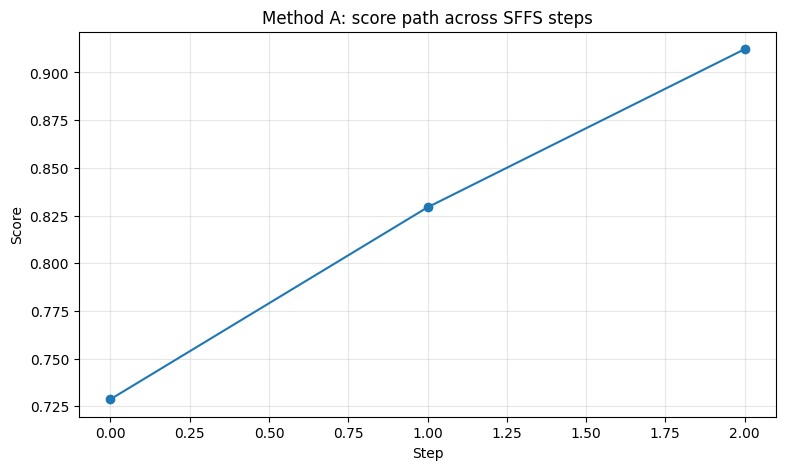

Method A selected_groups: ['dxy', 'ftse']
Method A final_score: 0.912188143652248


In [34]:
# ============================================================
# Method A - Input-group SFFS
# ============================================================

display(Markdown(
"""
## Method A: Input-group SFFS

This method searches over optional raw structural input groups and selects the ones
that improve the chosen objective the most, one step at a time.

Expected output:
- selected input groups
- trace table of the search path
- score path plot
"""
))

method_a_res = run_method_A_input_sffs(
    config=ABC_CFG,
    data=ABC_DATA,
    context_data=ABC_CONTEXT_DATA,
    objective=ABC_OBJECTIVE,
    seed_list=ABC_SEEDS,
    aggregate=ABC_AGGREGATE,
    min_improvement=0.0,
    verbose=ABC_VERBOSE,
)

display(Markdown("### Method A trace"))
display(method_a_res["trace"])

trace_a = method_a_res["trace"].copy()

plt.figure(figsize=(9, 5))
plt.plot(trace_a["step"], trace_a["score"], marker="o")
plt.title("Method A: score path across SFFS steps")
plt.xlabel("Step")
plt.ylabel("Score")
plt.grid(True, alpha=0.3)
plt.show()

print("Method A selected_groups:", method_a_res["selected_groups"])
print("Method A final_score:", method_a_res["final_score"])

In [34]:
# ============================================================
# Method A+ : Exhaustive raw-input subset search
# Global best subset over all structural input groups
# ============================================================

from itertools import combinations
from copy import deepcopy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def run_method_A_exhaustive_raw_input_search(
    config=None,
    data=None,
    context_data=None,
    candidate_groups=None,
    objective="sharpe",
    seed_list=(42,),
    aggregate="median",
    min_subset_size=0,
    max_subset_size=None,
    include_empty=True,
    verbose=True,
):
    """
    Exhaustive search over all subsets of candidate raw structural input groups.

    This is the "global" version of Method A for the raw-input groups only.
    It evaluates every subset of STRUCTURAL_INPUT_TO_FEATURE keys (or a custom candidate list)
    and returns the best subset under the chosen objective.

    Important:
    - Global only with respect to this subset-selection problem.
    - Everything else in the pipeline remains fixed by config.
    """
    cfg = get_default_research_config(config)
    candidate_groups = list(STRUCTURAL_INPUT_TO_FEATURE.keys()) if candidate_groups is None else list(candidate_groups)

    if max_subset_size is None:
        max_subset_size = len(candidate_groups)

    subset_rows = []

    # Enumerate subsets
    start_k = 0 if include_empty else max(1, min_subset_size)
    start_k = max(start_k, min_subset_size)

    total_evals = 0
    for k in range(start_k, max_subset_size + 1):
        total_evals += sum(1 for _ in combinations(candidate_groups, k))

    if verbose:
        display(Markdown(
            f"""
### Method A+ exhaustive search
Evaluating **{total_evals}** subsets over candidate groups:

`{candidate_groups}`

Objective: `{objective}`  
Aggregate across seeds: `{aggregate}`
"""
        ))

    done = 0
    for k in range(start_k, max_subset_size + 1):
        for subset in combinations(candidate_groups, k):
            subset = list(subset)

            bundle = build_research_bundle(
                cfg,
                data=data,
                context_data=context_data,
                selected_input_groups=subset,
                verbose=False,
            )

            ev = evaluate_embedded_bundle(
                bundle,
                objective=objective,
                seed_list=seed_list,
                aggregate=aggregate,
                verbose=False,
            )

            row = {
                "subset_size": len(subset),
                "groups": tuple(subset),
                "score": float(ev["score"]),
            }

            # attach detailed rows if available
            rows_df = ev.get("rows", pd.DataFrame())
            if isinstance(rows_df, pd.DataFrame) and not rows_df.empty:
                metric_col = normalize_objective_name(objective)
                row["metric_used"] = metric_col
                if metric_col in rows_df.columns:
                    row[f"{metric_col}_{aggregate}"] = float(aggregate_scores(rows_df, metric=metric_col, aggregate=aggregate))
                for c in ["net_sharpe", "alpha", "net_cagr", "final_equity", "net_maxdd", "avg_turnover"]:
                    if c in rows_df.columns:
                        row[c] = float(rows_df[c].median()) if aggregate == "median" else float(rows_df[c].mean())

            subset_rows.append(row)

            done += 1
            if verbose and (done % 20 == 0 or done == total_evals):
                print(f"[Method A+] progress: {done}/{total_evals}")

    results_df = pd.DataFrame(subset_rows).sort_values("score", ascending=False).reset_index(drop=True)

    best_row = results_df.iloc[0].to_dict()
    best_groups = list(best_row["groups"])

    best_bundle = build_research_bundle(
        cfg,
        data=data,
        context_data=context_data,
        selected_input_groups=best_groups,
        verbose=False,
    )

    # summary by subset size
    size_summary = (
        results_df.groupby("subset_size", as_index=False)["score"]
        .agg(["max", "mean", "median"])
        .reset_index()
    )
    size_summary.columns = ["subset_size", "score_max", "score_mean", "score_median"]

    if verbose:
        display(Markdown("### Top exhaustive subsets"))
        display(results_df.head(20))

        display(Markdown("### Best subset"))
        display(pd.Series(best_row))

        display(Markdown("### Summary by subset size"))
        display(size_summary)

        # Plot 1: best score by subset size
        plt.figure(figsize=(8, 5))
        plt.plot(size_summary["subset_size"], size_summary["score_max"], marker="o")
        plt.title("Method A+ exhaustive: best score by subset size")
        plt.xlabel("Subset size")
        plt.ylabel("Best score")
        plt.grid(True, alpha=0.3)
        plt.show()

        # Plot 2: distribution-ish scatter by subset size
        plt.figure(figsize=(9, 5))
        plt.scatter(results_df["subset_size"], results_df["score"], alpha=0.6)
        plt.title("Method A+ exhaustive: score across all subsets")
        plt.xlabel("Subset size")
        plt.ylabel("Score")
        plt.grid(True, alpha=0.3)
        plt.show()

    return {
        "candidate_groups": candidate_groups,
        "objective": objective,
        "aggregate": aggregate,
        "results": results_df,
        "best_groups": best_groups,
        "best_score": float(best_row["score"]),
        "best_row": best_row,
        "best_bundle": best_bundle,
        "size_summary": size_summary,
    }

In [35]:
# ============================================================
# Compare greedy Method A vs exhaustive Method A+
# ============================================================

def compare_method_A_vs_exhaustive(
    config=None,
    data=None,
    context_data=None,
    objective="sharpe",
    seed_list=(42,),
    aggregate="median",
    verbose=True,
):
    greedy = run_method_A_input_sffs(
        config=config,
        data=data,
        context_data=context_data,
        objective=objective,
        seed_list=seed_list,
        aggregate=aggregate,
        verbose=verbose,
    )

    exhaustive = run_method_A_exhaustive_raw_input_search(
        config=config,
        data=data,
        context_data=context_data,
        objective=objective,
        seed_list=seed_list,
        aggregate=aggregate,
        verbose=verbose,
    )

    compare_df = pd.DataFrame([
        {
            "method": "greedy_sffs",
            "groups": tuple(greedy["selected_groups"]),
            "score": float(greedy["final_score"]),
            "subset_size": len(greedy["selected_groups"]),
        },
        {
            "method": "exhaustive_global_best",
            "groups": tuple(exhaustive["best_groups"]),
            "score": float(exhaustive["best_score"]),
            "subset_size": len(exhaustive["best_groups"]),
        },
    ])

    if verbose:
        display(Markdown("## Greedy vs exhaustive comparison"))
        display(compare_df)

        gap = float(exhaustive["best_score"]) - float(greedy["final_score"])
        print(f"Score gap (exhaustive - greedy): {gap:.6f}")

    return {
        "greedy": greedy,
        "exhaustive": exhaustive,
        "comparison": compare_df,
    }

In [36]:
# ============================================================
# Run the upgraded Method A+
# ============================================================

ABC_CFG_EXH = get_default_research_config({
    "start": "2010-01-01",
    "end": "2025-12-31",
    "top_n": 20,
    "seq_len": 20,
    "train_end": "2017-12-31",
    "val_end": "2019-12-31",
    "feature_batches": ["intraday_lagged", "cross_sectional", "structural"],
    "universe_mode": "buffered_v2",
    "universe_buffer_mult": 1.5,
    "universe_min_dolv_short": 5e6,
    "epochs": 6,
    "lr": 1e-3,
    "lam_embedded": 0.8,
    "k_turn": 0.05,
    "k_conc": 0.05,
    "hidden": 64,
    "num_layers": 1,
    "dropout": 0.0,
    "grad_clip_norm": 5.0,
    "weight_mode": "long_short",
    "gross_long": 1.0,
    "gross_short": 1.0,
})

ABC_DATA_EXH = download_ohlcv(
    list(dict.fromkeys(ABC_CFG_EXH["tickers"] + ["SPY"])),
    start=ABC_CFG_EXH["start"],
    end=ABC_CFG_EXH["end"],
    auto_adjust=True,
)

ABC_CONTEXT_EXH = download_context_data(
    start=ABC_CFG_EXH["start"],
    end=ABC_CFG_EXH["end"],
)

method_a_plus = compare_method_A_vs_exhaustive(
    config=ABC_CFG_EXH,
    data=ABC_DATA_EXH,
    context_data=ABC_CONTEXT_EXH,
    objective="sharpe",
    seed_list=(42,),
    aggregate="median",
    verbose=True,
)

/tmp/ipykernel_2416532/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000074 | train mse 0.003790 | train turn 0.098420 | val pnl +0.000091 | val mse 0.000464 | val turn 0.027852
Epoch 02 | train pnl -0.000146 | train mse 0.000992 | train turn 0.023750 | val pnl -0.000072 | val mse 0.001750 | val turn 0.000043
Epoch 03 | train pnl -0.000261 | train mse 0.000796 | train turn 0.014585 | val pnl -0.000072 | val mse 0.001352 | val turn 0.000000
Epoch 04 | train pnl -0.000015 | train mse 0.000737 | train turn 0.016639 | val pnl +0.000072 | val mse 0.001128 | val turn 0.000000
Epoch 05 | train pnl +0.000231 | train mse 0.000651 | train turn 0.023341 | val pnl +0.000072 | val mse 0.001674 | val turn 0.000000
Epoch 06 | train pnl +0.000267 | train mse 0.000594 | train turn 0.016204 | val pnl +0.000072 | val mse 0.000207 | val turn 0.000001


/tmp/ipykernel_2416532/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl -0.000038 | train mse 0.004482 | train turn 0.109577 | val pnl -0.000048 | val mse 0.000659 | val turn 0.013581
Epoch 02 | train pnl -0.000051 | train mse 0.001036 | train turn 0.020556 | val pnl +0.000125 | val mse 0.001173 | val turn 0.019609
Epoch 03 | train pnl +0.000267 | train mse 0.000728 | train turn 0.006802 | val pnl +0.000072 | val mse 0.000473 | val turn 0.000002
Epoch 04 | train pnl +0.000282 | train mse 0.000649 | train turn 0.008844 | val pnl +0.000072 | val mse 0.000805 | val turn 0.000000
Epoch 05 | train pnl +0.000270 | train mse 0.000578 | train turn 0.008931 | val pnl +0.000073 | val mse 0.000198 | val turn 0.000079
Epoch 06 | train pnl +0.000281 | train mse 0.000560 | train turn 0.013620 | val pnl +0.000072 | val mse 0.000361 | val turn 0.000000


/tmp/ipykernel_2416532/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


...

Epoch 01 | train pnl +0.000142 | train mse 0.003061 | train turn 0.084479 | val pnl +0.000059 | val mse 0.000841 | val turn 0.001838
Epoch 02 | train pnl +0.000249 | train mse 0.000891 | train turn 0.012474 | val pnl -0.000053 | val mse 0.000375 | val turn 0.001941
Epoch 03 | train pnl +0.000129 | train mse 0.000810 | train turn 0.018369 | val pnl +0.000072 | val mse 0.001370 | val turn 0.000000
Epoch 04 | train pnl -0.000248 | train mse 0.000735 | train turn 0.024819 | val pnl -0.000072 | val mse 0.001368 | val turn 0.000000
Epoch 05 | train pnl +0.000123 | train mse 0.000656 | train turn 0.022533 | val pnl +0.000072 | val mse 0.001183 | val turn 0.000000
Epoch 06 | train pnl +0.000288 | train mse 0.000607 | train turn 0.016747 | val pnl +0.000072 | val mse 0.000813 | val turn 0.000000


/tmp/ipykernel_2416532/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000090 | train mse 0.006548 | train turn 0.117367 | val pnl +0.000071 | val mse 0.001192 | val turn 0.010776
Epoch 02 | train pnl +0.000183 | train mse 0.001176 | train turn 0.027760 | val pnl +0.000104 | val mse 0.000457 | val turn 0.020040
Epoch 03 | train pnl +0.000266 | train mse 0.000863 | train turn 0.009210 | val pnl +0.000140 | val mse 0.000197 | val turn 0.182379
Epoch 04 | train pnl +0.000070 | train mse 0.000740 | train turn 0.010239 | val pnl -0.000071 | val mse 0.000242 | val turn 0.000429
Epoch 05 | train pnl -0.000282 | train mse 0.000667 | train turn 0.007152 | val pnl -0.000072 | val mse 0.000297 | val turn 0.000000
Epoch 06 | train pnl -0.000274 | train mse 0.000609 | train turn 0.006848 | val pnl -0.000072 | val mse 0.000970 | val turn 0.000000
[Method A+] progress: 256/256


/tmp/ipykernel_2416532/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


ValueError: Length mismatch: Expected axis has 5 elements, new values have 4 elements


## Method B: Input-group mRMR

This method ranks raw structural input groups by balancing:
- standalone usefulness (relevance)
- overlap with other groups (redundancy)

Expected output:
- ranking table
- relevance table
- redundancy matrix
- top groups by mRMR score


/tmp/ipykernel_1270905/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000104 | train mse 0.003650 | train turn 0.083145 | val pnl +0.000076 | val mse 0.000513 | val turn 0.005250
Epoch 02 | train pnl +0.000279 | train mse 0.000899 | train turn 0.010170 | val pnl +0.000073 | val mse 0.001904 | val turn 0.000906
Epoch 03 | train pnl +0.000238 | train mse 0.000736 | train turn 0.010244 | val pnl -0.000069 | val mse 0.000305 | val turn 0.005290
Epoch 04 | train pnl -0.000270 | train mse 0.000686 | train turn 0.016527 | val pnl -0.000068 | val mse 0.000340 | val turn 0.003323
Epoch 05 | train pnl -0.000274 | train mse 0.000616 | train turn 0.008872 | val pnl -0.000072 | val mse 0.000688 | val turn 0.000000
Epoch 06 | train pnl -0.000269 | train mse 0.000550 | train turn 0.020366 | val pnl -0.000072 | val mse 0.000346 | val turn 0.000000


/tmp/ipykernel_1270905/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()
/tmp/ipykernel_1270905/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl -0.000065 | train mse 0.004511 | train turn 0.122045 | val pnl +0.000013 | val mse 0.001124 | val turn 0.058521
Epoch 02 | train pnl +0.000051 | train mse 0.001087 | train turn 0.022768 | val pnl +0.000085 | val mse 0.001686 | val turn 0.029708
Epoch 03 | train pnl +0.000292 | train mse 0.000753 | train turn 0.006774 | val pnl +0.000073 | val mse 0.000394 | val turn 0.000048
Epoch 04 | train pnl +0.000251 | train mse 0.000729 | train turn 0.011944 | val pnl +0.000072 | val mse 0.000817 | val turn 0.000000
Epoch 05 | train pnl +0.000270 | train mse 0.000593 | train turn 0.007538 | val pnl +0.000072 | val mse 0.000733 | val turn 0.000000
Epoch 06 | train pnl +0.000280 | train mse 0.000504 | train turn 0.007813 | val pnl +0.000072 | val mse 0.001032 | val turn 0.000000


...

,rank,group,mrmr_score,relevance_delta,avg_redundancy_to_selected
0,1,ftse,0.185468,0.185468,0.000000
1,2,gold,0.032375,0.047845,0.015470
2,3,oil,-0.070614,0.151281,0.221895
3,4,tnx,-0.139910,0.119926,0.259835
4,5,dax,-0.200228,0.158577,0.358805
5,6,vix,-0.242219,0.066105,0.308323
6,7,nikkei,-0.261571,-0.135298,0.126273
7,8,dxy,-1.460367,-1.339417,0.120950


### Method B relevance

,group,single_group_score,relevance_delta
2,ftse,0.848031,0.185468
1,dax,0.821139,0.158577
5,oil,0.813844,0.151281
4,tnx,0.782488,0.119926
3,vix,0.728667,0.066105
6,gold,0.710407,0.047845
0,nikkei,0.527265,-0.135298
7,dxy,-0.676854,-1.339417


### Method B redundancy

,nikkei,dax,ftse,vix,tnx,oil,gold,dxy
nikkei,0.000000,0.222611,0.236646,0.095990,0.112699,0.037953,0.051740,0.071552
dax,0.222611,0.000000,0.777221,0.446342,0.372075,0.224801,0.061121,0.007945
ftse,0.236646,0.777221,0.000000,0.459547,0.332294,0.270183,0.015470,0.034084
vix,0.095990,0.446342,0.459547,0.000000,0.339478,0.265099,0.031152,0.079438
tnx,0.112699,0.372075,0.332294,0.339478,0.000000,0.254975,0.192236,0.058842
oil,0.037953,0.224801,0.270183,0.265099,0.254975,0.000000,0.173608,0.206795
gold,0.051740,0.061121,0.015470,0.031152,0.192236,0.173608,0.000000,0.387997
dxy,0.071552,0.007945,0.034084,0.079438,0.058842,0.206795,0.387997,0.000000


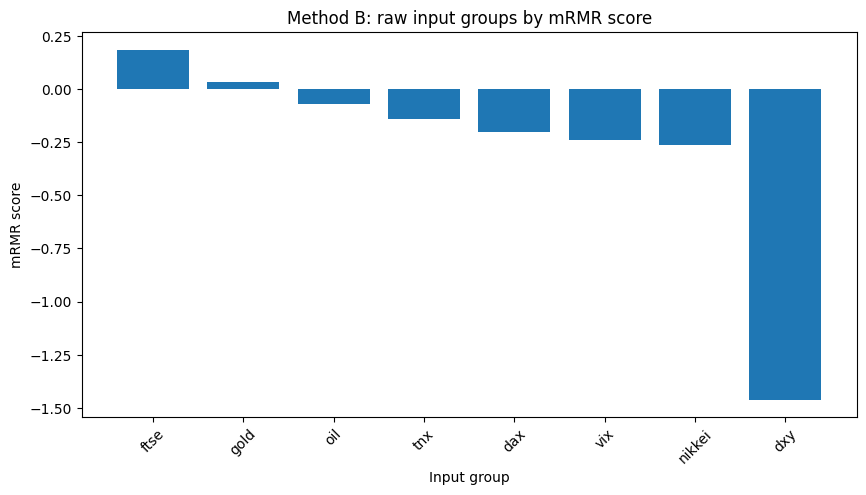

Method B selected_groups (ranking order): ['ftse', 'gold', 'oil', 'tnx', 'dax', 'vix', 'nikkei', 'dxy']


In [37]:
# ============================================================
# Method B - Input-group mRMR
# ============================================================

display(Markdown(
"""
## Method B: Input-group mRMR

This method ranks raw structural input groups by balancing:
- standalone usefulness (relevance)
- overlap with other groups (redundancy)

Expected output:
- ranking table
- relevance table
- redundancy matrix
- top groups by mRMR score
"""
))

method_b_res = run_method_B_input_mrmr(
    config=ABC_CFG,
    data=ABC_DATA,
    context_data=ABC_CONTEXT_DATA,
    objective=ABC_OBJECTIVE,
    seed_list=ABC_SEEDS,
    aggregate=ABC_AGGREGATE,
    verbose=ABC_VERBOSE,
)

display(Markdown("### Method B ranking"))
display(method_b_res["ranking"])

display(Markdown("### Method B relevance"))
display(method_b_res["relevance"])

display(Markdown("### Method B redundancy"))
display(method_b_res["redundancy"])

rank_b = method_b_res["ranking"].copy()

plt.figure(figsize=(10, 5))
plt.bar(rank_b["group"], rank_b["mrmr_score"])
plt.title("Method B: raw input groups by mRMR score")
plt.xlabel("Input group")
plt.ylabel("mRMR score")
plt.xticks(rotation=45)
plt.show()

print("Method B selected_groups (ranking order):", method_b_res["selected_groups"])

In [ ]:
# ============================================================
# Method C - Conditional permutation importance
# ============================================================

display(Markdown(
"""
## Method C: Conditional permutation importance

This method starts from a selected set of input groups and measures how much
performance drops when one group's contribution is conditionally permuted.

Recommended input:
- use the groups selected by Method A
- if Method A selected nothing, fall back to the top groups from Method B
"""
))

selected_groups_for_c = list(method_a_res["selected_groups"])
if not selected_groups_for_c:
    selected_groups_for_c = list(method_b_res["ranking"]["group"].head(3))

print("Groups used for Method C:", selected_groups_for_c)

method_c_res = run_method_C_input_conditional_permutation(
    config=ABC_CFG,
    data=ABC_DATA,
    context_data=ABC_CONTEXT_DATA,
    selected_groups=selected_groups_for_c,
    objective=ABC_OBJECTIVE,
    seed_list=ABC_SEEDS,
    aggregate=ABC_AGGREGATE,
    verbose=ABC_VERBOSE,
)

display(Markdown("### Method C importance table"))
display(method_c_res["importance"])

imp_c = method_c_res["importance"].copy()

plt.figure(figsize=(9, 5))
plt.bar(imp_c["group"], imp_c["importance_drop"])
plt.title("Method C: conditional permutation importance by input group")
plt.xlabel("Input group")
plt.ylabel("Importance drop")
plt.xticks(rotation=45)
plt.show()

print("Method C base_score:", method_c_res["base_score"])

## 12C. Methods D, E, F for engineered features

> **Run this after:** Section **12B** if you want input filtering first, or directly after `build_research_bundle(...)` if you want feature screening on the current active setup.  
> **What this does:** screens, ranks, and stress-tests engineered features or feature families.  
> **Connected to:** `make_features(...)`, `build_day_batches(...)`, and the embedded model evaluation helpers from Section **12A**.  
> **Expected output:**  
> - **Method D:** mRMR shortlist of features  
> - **Method E:** sequential floating selection trace for families or features  
> - **Method F:** stability-selection frequencies across time-block resamples  

Use this block when you want to answer: *which features add materially new information, which are redundant, and which survive repeated subsampling instead of just getting lucky once?*


In [31]:

# ----------------------------
# Methods D, E, F -> feature screening / selection
# ----------------------------
def run_method_D_feature_mrmr(config=None,
                              data=None,
                              context_data=None,
                              selected_input_groups=None,
                              candidate_feature_names=None,
                              top_k=12,
                              verbose=True):
    """
    Method D:
    mRMR-style feature prefilter on engineered features.
    Relevance = mutual information to target on train panel.
    Redundancy = absolute Spearman correlation.
    """
    cfg = get_default_research_config(config)
    bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                   selected_input_groups=selected_input_groups,
                                   verbose=False)
    feature_names = bundle["feat_names"] if candidate_feature_names is None else [f for f in candidate_feature_names if f in bundle["feat_names"]]
    train_dates = [b[0] for b in bundle["batches_train"]]

    relevance = []
    for fn in feature_names:
        rel = _score_feature_frame_single_feature(bundle["feats"], bundle["y"], fn, date_index=train_dates)
        relevance.append({"feature": fn, "relevance": rel})
    rel_df = pd.DataFrame(relevance).sort_values("relevance", ascending=False)
    redundancy = compute_abs_corr_redundancy(bundle["feats"], feature_names, bundle["y"], date_index=train_dates)

    selected = []
    ranking = []
    remaining = list(rel_df["feature"])
    top_k = int(min(top_k, len(remaining)))
    for rank in range(top_k):
        best_feature = None
        best_score = -np.inf
        best_red = 0.0
        for fn in remaining:
            rel = float(rel_df.loc[rel_df["feature"] == fn, "relevance"].iloc[0])
            red = float(np.mean([redundancy.loc[fn, s] for s in selected])) if selected else 0.0
            score = rel - red
            if score > best_score:
                best_feature = fn
                best_score = score
                best_red = red
        selected.append(best_feature)
        remaining.remove(best_feature)
        ranking.append({
            "rank": rank + 1,
            "feature": best_feature,
            "mrmr_score": best_score,
            "relevance": float(rel_df.loc[rel_df["feature"] == best_feature, "relevance"].iloc[0]),
            "avg_redundancy_to_selected": best_red,
        })
    ranking_df = pd.DataFrame(ranking)
    if verbose:
        print("[Method D] Feature mRMR ranking")
        display(ranking_df)
    return {
        "ranking": ranking_df,
        "relevance": rel_df,
        "redundancy": redundancy,
        "selected_features": selected,
        "bundle": bundle,
    }

def run_method_E_feature_sffs(config=None,
                              data=None,
                              context_data=None,
                              selected_input_groups=None,
                              candidate_mode="family",
                              candidate_items=None,
                              mandatory_features=None,
                              objective="sharpe",
                              seed_list=(42,),
                              aggregate="median",
                              min_improvement=0.0,
                              max_steps=None,
                              verbose=True):
    """
    Method E:
    Sequential Forward Floating Selection for feature families or feature names.
    """
    cfg = get_default_research_config(config)
    base_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                        selected_input_groups=selected_input_groups,
                                        verbose=False)
    feature_families = infer_feature_families_from_names(base_bundle["feat_names"])

    if candidate_mode == "family":
        candidate_items = list(feature_families.keys()) if candidate_items is None else list(candidate_items)
        mandatory_features = [] if mandatory_features is None else list(mandatory_features)
        def materialize(selection_items):
            feats_keep = list(mandatory_features)
            for fam in selection_items:
                feats_keep.extend(feature_families.get(fam, []))
            return sorted(set(feats_keep))
    else:
        candidate_items = list(base_bundle["feat_names"]) if candidate_items is None else [f for f in candidate_items if f in base_bundle["feat_names"]]
        mandatory_features = [] if mandatory_features is None else list(mandatory_features)
        def materialize(selection_items):
            return sorted(set(mandatory_features + list(selection_items)))

    selected = []
    remaining = [x for x in candidate_items if x not in selected]
    current_keep = materialize(selected)
    if len(current_keep) == 0:
        current_keep = list(base_bundle["feat_names"]) if candidate_mode == "family" and len(candidate_items) == 0 else []
    current_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                           selected_input_groups=selected_input_groups,
                                           selected_feature_names=current_keep if len(current_keep) else None,
                                           verbose=False)
    current_eval = evaluate_embedded_bundle(current_bundle, objective=objective, seed_list=seed_list,
                                            aggregate=aggregate, verbose=False)
    current_score = current_eval["score"]
    trace = [{"step": 0, "action": "start", "selected": tuple(selected), "score": current_score}]

    step = 0
    while remaining and (max_steps is None or step < max_steps):
        add_rows = []
        for item in remaining:
            trial_sel = selected + [item]
            keep = materialize(trial_sel)
            trial_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                                selected_input_groups=selected_input_groups,
                                                selected_feature_names=keep,
                                                verbose=False)
            trial_eval = evaluate_embedded_bundle(trial_bundle, objective=objective, seed_list=seed_list,
                                                  aggregate=aggregate, verbose=False)
            add_rows.append({"candidate": item, "score": trial_eval["score"], "delta": trial_eval["score"] - current_score})
        add_df = pd.DataFrame(add_rows).sort_values("score", ascending=False)
        if verbose:
            print(f"[Method E] Add step {step+1} | mode={candidate_mode}")
            display(add_df)
        if add_df.empty or add_df["delta"].iloc[0] <= min_improvement:
            break

        chosen = add_df.iloc[0]["candidate"]
        selected.append(chosen)
        remaining.remove(chosen)
        current_score = float(add_df.iloc[0]["score"])
        step += 1
        trace.append({"step": step, "action": f"add:{chosen}", "selected": tuple(selected), "score": current_score})

        improved = True
        while improved and len(selected) > 1:
            improved = False
            rem_rows = []
            for item in list(selected):
                trial_sel = [x for x in selected if x != item]
                keep = materialize(trial_sel)
                trial_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                                    selected_input_groups=selected_input_groups,
                                                    selected_feature_names=keep,
                                                    verbose=False)
                trial_eval = evaluate_embedded_bundle(trial_bundle, objective=objective, seed_list=seed_list,
                                                      aggregate=aggregate, verbose=False)
                rem_rows.append({"remove": item, "score": trial_eval["score"], "delta_vs_current": trial_eval["score"] - current_score})
            rem_df = pd.DataFrame(rem_rows).sort_values("score", ascending=False)
            if verbose and not rem_df.empty:
                print("[Method E] Floating remove check")
                display(rem_df)
            if (not rem_df.empty) and (rem_df["delta_vs_current"].iloc[0] > min_improvement):
                gone = rem_df.iloc[0]["remove"]
                selected.remove(gone)
                remaining.append(gone)
                current_score = float(rem_df.iloc[0]["score"])
                step += 1
                trace.append({"step": step, "action": f"remove:{gone}", "selected": tuple(selected), "score": current_score})
                improved = True

    final_keep = materialize(selected)
    final_bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                         selected_input_groups=selected_input_groups,
                                         selected_feature_names=final_keep if len(final_keep) else None,
                                         verbose=False)
    return {
        "mode": candidate_mode,
        "selected_items": selected,
        "selected_feature_names": final_keep,
        "trace": pd.DataFrame(trace),
        "final_bundle": final_bundle,
        "final_score": current_score,
    }

def _sample_training_dates_for_stability(bundle, frac=0.7, min_blocks=3, seed=42):
    rng = np.random.default_rng(seed)
    train_dates = pd.DatetimeIndex([b[0] for b in bundle["batches_train"]]).sort_values()
    if len(train_dates) == 0:
        return train_dates
    n = len(train_dates)
    target = max(10, int(np.ceil(frac * n)))
    block = max(5, int(np.ceil(n / max(min_blocks, 3))))
    chosen = []
    while len(chosen) < target:
        start = int(rng.integers(0, max(1, n - block + 1)))
        chosen.extend(list(train_dates[start:start + block]))
        chosen = sorted(set(chosen))
        if len(chosen) >= n:
            break
    return pd.DatetimeIndex(chosen[:target])

def run_method_F_feature_stability_selection(config=None,
                                             data=None,
                                             context_data=None,
                                             selected_input_groups=None,
                                             candidate_feature_names=None,
                                             n_boot=12,
                                             frac=0.7,
                                             top_k=10,
                                             verbose=True):
    """
    Method F:
    Stability selection via repeated time-block subsampling + mRMR screening.
    """
    cfg = get_default_research_config(config)
    bundle = build_research_bundle(cfg, data=data, context_data=context_data,
                                   selected_input_groups=selected_input_groups,
                                   verbose=False)
    feature_names = bundle["feat_names"] if candidate_feature_names is None else [f for f in candidate_feature_names if f in bundle["feat_names"]]
    counts = defaultdict(int)
    ranks = defaultdict(list)

    for i in range(int(n_boot)):
        sampled_dates = _sample_training_dates_for_stability(bundle, frac=frac, seed=1000 + i)
        relevance = []
        for fn in feature_names:
            rel = _score_feature_frame_single_feature(bundle["feats"], bundle["y"], fn, date_index=sampled_dates)
            relevance.append({"feature": fn, "relevance": rel})
        rel_df = pd.DataFrame(relevance).sort_values("relevance", ascending=False)
        redundancy = compute_abs_corr_redundancy(bundle["feats"], feature_names, bundle["y"], date_index=sampled_dates)

        selected = []
        remaining = list(rel_df["feature"])
        kk = int(min(top_k, len(remaining)))
        for rank in range(kk):
            best_feature = None
            best_score = -np.inf
            for fn in remaining:
                rel = float(rel_df.loc[rel_df["feature"] == fn, "relevance"].iloc[0])
                red = float(np.mean([redundancy.loc[fn, s] for s in selected])) if selected else 0.0
                score = rel - red
                if score > best_score:
                    best_feature = fn
                    best_score = score
            selected.append(best_feature)
            remaining.remove(best_feature)
            counts[best_feature] += 1
            ranks[best_feature].append(rank + 1)

    freq_rows = []
    for fn in feature_names:
        freq_rows.append({
            "feature": fn,
            "selection_frequency": counts[fn] / max(1, int(n_boot)),
            "avg_rank_when_selected": float(np.mean(ranks[fn])) if ranks[fn] else np.nan,
        })
    freq_df = pd.DataFrame(freq_rows).sort_values(["selection_frequency", "avg_rank_when_selected"], ascending=[False, True])
    if verbose:
        print("[Method F] Stability selection frequencies")
        display(freq_df)
    return {
        "frequency_table": freq_df,
        "stable_features": list(freq_df.loc[freq_df["selection_frequency"] >= 0.5, "feature"]),
        "bundle": bundle,
    }


## 12D. Methods G, H, I, J, K for hyperparameters

> **Run this after:** Sections **12A to 12C** once you have a reasonably clean input/feature set.  
> **What this does:** tunes the embedded model hyperparameters without jumping straight into exhaustive brute force.  
> **Connected to:** `train_model(...)`, `backtest_batches(...)`, and any bundle-defining settings such as `seq_len`, `top_n`, or the current feature selection if you pass them through the config.  
> **Expected output:**  
> - **Method G:** coordinate-search tables with stable-region choices  
> - **Method H:** local response-surface design and suggested center  
> - **Method I:** pattern-search history  
> - **Method J:** Bayesian-optimization history  
> - **Method K:** Hyperband / successive-halving history  

Recommended practical order: **G first**, then **H or I**, and use **J/K** only if you want a more automated follow-up pass.


In [32]:

# ----------------------------
# Methods G, H, I, J, K -> hyperparameter search
# ----------------------------
def _build_bundle_for_candidate_config(base_config, candidate_cfg, data=None, context_data=None,
                                       selected_input_groups=None, selected_feature_names=None):
    merged = get_default_research_config(base_config)
    merged.update(deepcopy(candidate_cfg))
    return build_research_bundle(
        merged,
        data=data,
        context_data=context_data,
        selected_input_groups=selected_input_groups,
        selected_feature_names=selected_feature_names,
        verbose=False,
    )

def evaluate_candidate_config(base_config,
                              candidate_cfg,
                              objective="sharpe",
                              seed_list=(42,),
                              aggregate="median",
                              data=None,
                              context_data=None,
                              selected_input_groups=None,
                              selected_feature_names=None):
    bundle = _build_bundle_for_candidate_config(
        base_config,
        candidate_cfg,
        data=data,
        context_data=context_data,
        selected_input_groups=selected_input_groups,
        selected_feature_names=selected_feature_names,
    )
    ev = evaluate_embedded_bundle(bundle, config_overrides=candidate_cfg,
                                  objective=objective, seed_list=seed_list,
                                  aggregate=aggregate, verbose=False)
    return {"bundle": bundle, "score": ev["score"], "rows": ev["rows"]}

def run_method_G_coordinate_search(base_config=None,
                                   param_grid=None,
                                   objective="sharpe",
                                   seed_list=(42,),
                                   aggregate="median",
                                   tolerance_frac=0.02,
                                   data=None,
                                   context_data=None,
                                   selected_input_groups=None,
                                   selected_feature_names=None,
                                   verbose=True):
    """
    Method G:
    Coarse-to-fine coordinate search with stable-region choice.
    """
    cfg = get_default_research_config(base_config)
    if param_grid is None:
        param_grid = {
            "lr": [1e-4, 3e-4, 1e-3, 3e-3],
            "lam_embedded": [0.2, 0.5, 0.8, 1.0],
            "k_turn": [0.0, 0.02, 0.05, 0.10],
            "k_conc": [0.0, 0.02, 0.05, 0.10],
            "max_w": [0.01, 0.02, 0.03],
        }

    history_tables = {}
    tuned_cfg = deepcopy(cfg)

    for param_name, candidates in param_grid.items():
        rows = []
        for cand in candidates:
            trial_cfg = {param_name: cand}
            ev = evaluate_candidate_config(
                tuned_cfg,
                trial_cfg,
                objective=objective,
                seed_list=seed_list,
                aggregate=aggregate,
                data=data,
                context_data=context_data,
                selected_input_groups=selected_input_groups,
                selected_feature_names=selected_feature_names,
            )
            rows.append({
                "param_name": param_name,
                "candidate_value": cand,
                normalize_objective_name(objective): ev["score"],
            })
        table = pd.DataFrame(rows).sort_values("candidate_value")
        best_value, best_metric = choose_stable_numeric_value(
            table, metric_col=normalize_objective_name(objective), objective="max",
            tolerance_frac=tolerance_frac
        )
        tuned_cfg[param_name] = best_value
        history_tables[param_name] = table
        if verbose:
            print(f"[Method G] {param_name} -> chosen {best_value} | best observed={best_metric:.6f}")
            display(table)

    return {"best_config": tuned_cfg, "tables": history_tables}

def _make_three_level_design(center_cfg, param_bounds):
    design = []
    levels = {}
    for p, (lo, hi) in param_bounds.items():
        mid = center_cfg[p]
        levels[p] = [lo, mid, hi]
    params = list(param_bounds.keys())
    seen = set()
    for combo in product(*[levels[p] for p in params]):
        row = dict(zip(params, combo))
        key = tuple(row[p] for p in params)
        if key not in seen:
            seen.add(key)
            design.append(row)
    return design

def _fit_quadratic_response_surface(X, y, param_names):
    cols = []
    mats = []
    for i, p in enumerate(param_names):
        mats.append(X[:, i:i+1]); cols.append(p)
    for i, p in enumerate(param_names):
        mats.append((X[:, i:i+1] ** 2)); cols.append(f"{p}__sq")
    for i in range(len(param_names)):
        for j in range(i + 1, len(param_names)):
            mats.append((X[:, i:i+1] * X[:, j:j+1])); cols.append(f"{param_names[i]}__x__{param_names[j]}")
    Phi = np.hstack([np.ones((X.shape[0], 1))] + mats)
    beta, *_ = np.linalg.lstsq(Phi, y, rcond=None)
    return beta, cols

def _predict_quadratic_surface(xrow, beta, param_names, cols):
    vals = [1.0]
    xmap = {p: xrow[i] for i, p in enumerate(param_names)}
    for c in cols:
        if "__x__" in c:
            a, b = c.split("__x__")
            vals.append(xmap[a] * xmap[b])
        elif c.endswith("__sq"):
            a = c[:-4]
            vals.append(xmap[a] ** 2)
        else:
            vals.append(xmap[c])
    vals = np.asarray(vals, dtype=float)
    return float(vals @ beta)

def run_method_H_response_surface(base_config=None,
                                  param_bounds=None,
                                  objective="sharpe",
                                  seed_list=(42,),
                                  aggregate="median",
                                  data=None,
                                  context_data=None,
                                  selected_input_groups=None,
                                  selected_feature_names=None,
                                  verbose=True):
    """
    Method H:
    Local response surface design around the current configuration.
    """
    cfg = get_default_research_config(base_config)
    if param_bounds is None:
        param_bounds = {
            "lr": (1e-4, 3e-3),
            "lam_embedded": (0.2, 1.0),
            "k_turn": (0.0, 0.10),
        }
    design = _make_three_level_design(cfg, param_bounds)
    rows = []
    for trial_cfg in design:
        ev = evaluate_candidate_config(
            cfg,
            trial_cfg,
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
            data=data,
            context_data=context_data,
            selected_input_groups=selected_input_groups,
            selected_feature_names=selected_feature_names,
        )
        row = deepcopy(trial_cfg)
        row[normalize_objective_name(objective)] = ev["score"]
        rows.append(row)
    design_df = pd.DataFrame(rows)
    param_names = list(param_bounds.keys())
    X = design_df[param_names].values.astype(float)
    yv = design_df[normalize_objective_name(objective)].values.astype(float)
    beta, cols = _fit_quadratic_response_surface(X, yv, param_names)

    best_pred = -np.inf
    best_cfg = None
    for row in design:
        x = np.array([row[p] for p in param_names], dtype=float)
        pred = _predict_quadratic_surface(x, beta, param_names, cols)
        if pred > best_pred:
            best_pred = pred
            best_cfg = row
    if verbose:
        print("[Method H] Response surface design")
        display(design_df.sort_values(normalize_objective_name(objective), ascending=False))
        print("Suggested local center:", best_cfg)
    return {"design": design_df, "suggested_config": best_cfg, "beta": beta, "cols": cols}

def _pattern_search_score(base_config, trial_cfg, objective, seed_list, aggregate,
                          data, context_data, selected_input_groups, selected_feature_names):
    ev = evaluate_candidate_config(
        base_config, trial_cfg, objective=objective, seed_list=seed_list,
        aggregate=aggregate, data=data, context_data=context_data,
        selected_input_groups=selected_input_groups,
        selected_feature_names=selected_feature_names,
    )
    return float(ev["score"])

def run_method_I_pattern_search(base_config=None,
                                param_steps=None,
                                objective="sharpe",
                                seed_list=(42,),
                                aggregate="median",
                                max_rounds=8,
                                shrink=0.5,
                                data=None,
                                context_data=None,
                                selected_input_groups=None,
                                selected_feature_names=None,
                                verbose=True):
    """
    Method I:
    Simple derivative-free pattern search / mesh adaptive direct search style loop.
    """
    cfg = get_default_research_config(base_config)
    if param_steps is None:
        param_steps = {"lr": 5e-4, "lam_embedded": 0.2, "k_turn": 0.02}
    current_cfg = deepcopy(cfg)
    current_score = _pattern_search_score(cfg, {}, objective, seed_list, aggregate, data, context_data,
                                          selected_input_groups, selected_feature_names)
    history = [{"round": 0, "action": "start", normalize_objective_name(objective): current_score, **{k: current_cfg[k] for k in param_steps}}]

    for rd in range(1, max_rounds + 1):
        improved = False
        for param, step in list(param_steps.items()):
            trials = []
            for sign in (-1, +1):
                cand_val = current_cfg[param] + sign * step
                if isinstance(current_cfg[param], int):
                    cand_val = int(max(1, round(cand_val)))
                else:
                    cand_val = float(max(1e-8, cand_val))
                trial_cfg = {param: cand_val}
                score = _pattern_search_score(
                    current_cfg,
                    trial_cfg,
                    objective,
                    seed_list,
                    aggregate,
                    data,
                    context_data,
                    selected_input_groups,
                    selected_feature_names,
                )
                trials.append((cand_val, score))
            best_val, best_score = max(trials, key=lambda x: x[1])
            if best_score > current_score:
                current_cfg[param] = best_val
                current_score = best_score
                improved = True
                history.append({"round": rd, "action": f"move:{param}", normalize_objective_name(objective): current_score, **{k: current_cfg[k] for k in param_steps}})
                if verbose:
                    print(f"[Method I] move on {param} -> {best_val} | score={best_score:.6f}")
        if not improved:
            for param in param_steps:
                param_steps[param] = param_steps[param] * shrink
            history.append({"round": rd, "action": "shrink", normalize_objective_name(objective): current_score, **{k: current_cfg[k] for k in param_steps}})
            if verbose:
                print(f"[Method I] no improvement, shrink mesh -> {param_steps}")
    return {"best_config": current_cfg, "history": pd.DataFrame(history)}

def _sample_from_search_space(search_space, rng):
    sample = {}
    for p, spec in search_space.items():
        if spec["type"] == "float":
            lo, hi = spec["bounds"]
            if spec.get("log", False):
                sample[p] = float(np.exp(rng.uniform(np.log(lo), np.log(hi))))
            else:
                sample[p] = float(rng.uniform(lo, hi))
        elif spec["type"] == "int":
            lo, hi = spec["bounds"]
            sample[p] = int(rng.integers(lo, hi + 1))
        elif spec["type"] == "categorical":
            sample[p] = rng.choice(spec["values"]).item() if hasattr(rng.choice(spec["values"]), "item") else rng.choice(spec["values"])
        else:
            raise ValueError(f"Unknown spec type for {p}")
    return sample

def _encode_search_space_points(points, search_space):
    params = list(search_space.keys())
    X = []
    for pt in points:
        row = []
        for p in params:
            val = pt[p]
            spec = search_space[p]
            if spec["type"] == "categorical":
                values = list(spec["values"])
                row.append(float(values.index(val)))
            else:
                if spec.get("log", False):
                    row.append(np.log(float(val)))
                else:
                    row.append(float(val))
        X.append(row)
    return np.asarray(X, dtype=float), params

def run_method_J_bayesian_optimization(base_config=None,
                                       search_space=None,
                                       objective="sharpe",
                                       seed_list=(42,),
                                       aggregate="median",
                                       n_init=6,
                                       n_iter=12,
                                       n_candidates=200,
                                       data=None,
                                       context_data=None,
                                       selected_input_groups=None,
                                       selected_feature_names=None,
                                       verbose=True):
    """
    Method J:
    GP-based Bayesian optimization with Expected Improvement over random candidates.
    """
    cfg = get_default_research_config(base_config)
    if search_space is None:
        search_space = {
            "lr": {"type": "float", "bounds": (1e-4, 3e-3), "log": True},
            "lam_embedded": {"type": "float", "bounds": (0.2, 1.0)},
            "k_turn": {"type": "float", "bounds": (0.0, 0.10)},
            "k_conc": {"type": "float", "bounds": (0.0, 0.10)},
        }

    rng = np.random.default_rng(123)
    history = []
    tested_cfgs = []
    scores = []

    def _score_cfg(trial_cfg):
        ev = evaluate_candidate_config(
            cfg, trial_cfg, objective=objective, seed_list=seed_list, aggregate=aggregate,
            data=data, context_data=context_data,
            selected_input_groups=selected_input_groups,
            selected_feature_names=selected_feature_names,
        )
        return float(ev["score"])

    for _ in range(int(n_init)):
        trial_cfg = _sample_from_search_space(search_space, rng)
        score = _score_cfg(trial_cfg)
        tested_cfgs.append(trial_cfg)
        scores.append(score)
        history.append({**trial_cfg, normalize_objective_name(objective): score, "stage": "init"})

    for _ in range(int(n_iter)):
        X_train, params = _encode_search_space_points(tested_cfgs, search_space)
        y_train = np.asarray(scores, dtype=float)
        kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(X_train.shape[1]), nu=2.5) + WhiteKernel(noise_level=1e-5)
        gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=2)
        gp.fit(X_train, y_train)

        candidate_cfgs = [_sample_from_search_space(search_space, rng) for _ in range(int(n_candidates))]
        X_cand, _ = _encode_search_space_points(candidate_cfgs, search_space)
        mu, std = gp.predict(X_cand, return_std=True)
        best_y = np.max(y_train)
        z = (mu - best_y) / (std + 1e-12)
        ei = (mu - best_y) * 0.5 * (1 + np.vectorize(math.erf)(z / np.sqrt(2))) + std * (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * z**2)
        best_idx = int(np.nanargmax(ei))
        next_cfg = candidate_cfgs[best_idx]
        next_score = _score_cfg(next_cfg)
        tested_cfgs.append(next_cfg)
        scores.append(next_score)
        history.append({**next_cfg, normalize_objective_name(objective): next_score, "stage": "bo"})
        if verbose:
            print(f"[Method J] tried {next_cfg} -> {next_score:.6f}")

    hist_df = pd.DataFrame(history).sort_values(normalize_objective_name(objective), ascending=False)
    best_cfg = hist_df.iloc[0][list(search_space.keys())].to_dict()
    return {"history": hist_df, "best_config": best_cfg}

def run_method_K_hyperband(base_config=None,
                           search_space=None,
                           budget_key="epochs",
                           max_budget=9,
                           eta=3,
                           objective="sharpe",
                           seed_list=(42,),
                           aggregate="median",
                           n0=9,
                           data=None,
                           context_data=None,
                           selected_input_groups=None,
                           selected_feature_names=None,
                           verbose=True):
    """
    Method K:
    Hyperband / successive halving style search.
    """
    cfg = get_default_research_config(base_config)
    if search_space is None:
        search_space = {
            "lr": {"type": "float", "bounds": (1e-4, 3e-3), "log": True},
            "lam_embedded": {"type": "float", "bounds": (0.2, 1.0)},
            "k_turn": {"type": "float", "bounds": (0.0, 0.10)},
            "k_conc": {"type": "float", "bounds": (0.0, 0.10)},
        }
    rng = np.random.default_rng(321)
    population = [_sample_from_search_space(search_space, rng) for _ in range(int(n0))]
    budgets = []
    b = 1
    while b <= max_budget:
        budgets.append(b)
        b *= eta

    history = []
    survivors = population
    for budget in budgets:
        scored = []
        for cand in survivors:
            trial_cfg = deepcopy(cand)
            trial_cfg[budget_key] = int(budget)
            ev = evaluate_candidate_config(
                cfg, trial_cfg, objective=objective, seed_list=seed_list, aggregate=aggregate,
                data=data, context_data=context_data,
                selected_input_groups=selected_input_groups,
                selected_feature_names=selected_feature_names,
            )
            score = float(ev["score"])
            scored.append((trial_cfg, score))
            history.append({**trial_cfg, normalize_objective_name(objective): score, "budget": budget})
        scored.sort(key=lambda x: x[1], reverse=True)
        keep_n = max(1, int(np.ceil(len(scored) / eta)))
        survivors = [deepcopy(cfg_) for cfg_, _ in scored[:keep_n]]
        if verbose:
            print(f"[Method K] budget={budget} | survivors={keep_n}")
    hist_df = pd.DataFrame(history).sort_values([normalize_objective_name(objective), "budget"], ascending=[False, False])
    best_cfg = hist_df.iloc[0].to_dict()
    return {"history": hist_df, "best_config": {k: best_cfg[k] for k in hist_df.columns if k in set(search_space.keys()) | {budget_key}}}


## 12E. Methods L, M, N for universe-selection hyperparameters

> **Run this after:** Section **12A**, and ideally after you already have a decent input/feature set.  
> **What this does:** screens and refines the parameters that change the investable universe itself.  
> **Connected to:** `make_universe_mask(...)`, `make_universe_mask_v2(...)`, `build_research_bundle(...)`, and the embedded evaluation helpers.  
> **Expected output:**  
> - **Method L:** Morris screening table (`mu`, `mu_star`, `sigma`)  
> - **Method M:** Sobol first-order and total-order sensitivity table  
> - **Method N:** local refinement output using either response-surface logic or pattern search  

Use this block when you want to answer: *which universe knobs actually move performance, which ones mostly do nothing, and which ones deserve local refinement instead of blind search?*


In [33]:

# ----------------------------
# Methods L, M, N -> universe-selection hyperparameters
# ----------------------------
def _coerce_universe_value(name, val):
    int_like = {"top_n", "target_n", "universe_short_w", "universe_long_w", "cap_max_names"}
    if name in int_like:
        return int(max(1, round(val)))
    return float(val)

def _map_universe_candidate_to_config(candidate_cfg):
    cfg = {}
    for k, v in candidate_cfg.items():
        if k == "target_n":
            cfg["top_n"] = int(v)
        else:
            cfg[k] = v
    return cfg

def run_method_L_morris_screening(base_config=None,
                                  param_bounds=None,
                                  n_trajectories=8,
                                  delta=0.25,
                                  objective="sharpe",
                                  seed_list=(42,),
                                  aggregate="median",
                                  data=None,
                                  context_data=None,
                                  selected_input_groups=None,
                                  selected_feature_names=None,
                                  verbose=True):
    """
    Method L:
    Morris elementary-effects screening for universe-selection parameters.
    """
    cfg = get_default_research_config(base_config)
    if param_bounds is None:
        param_bounds = {
            "target_n": (10, 40),
            "universe_buffer_mult": (1.0, 2.0),
            "universe_min_dolv_short": (1e6, 10e6),
        }
    rng = np.random.default_rng(77)
    params = list(param_bounds.keys())
    effects = defaultdict(list)
    all_rows = []

    for traj in range(int(n_trajectories)):
        x = {}
        for p, (lo, hi) in param_bounds.items():
            x[p] = rng.uniform(lo, hi)
        base_cfg = {p: _coerce_universe_value(p, x[p]) for p in params}
        base_eval = evaluate_candidate_config(
            cfg, _map_universe_candidate_to_config(base_cfg),
            objective=objective, seed_list=seed_list, aggregate=aggregate,
            data=data, context_data=context_data,
            selected_input_groups=selected_input_groups,
            selected_feature_names=selected_feature_names,
        )
        base_score = float(base_eval["score"])

        for p in params:
            lo, hi = param_bounds[p]
            step = delta * (hi - lo)
            x2 = deepcopy(x)
            x2[p] = min(hi, max(lo, x[p] + step))
            trial_cfg = {q: _coerce_universe_value(q, x2[q]) for q in params}
            trial_eval = evaluate_candidate_config(
                cfg, _map_universe_candidate_to_config(trial_cfg),
                objective=objective, seed_list=seed_list, aggregate=aggregate,
                data=data, context_data=context_data,
                selected_input_groups=selected_input_groups,
                selected_feature_names=selected_feature_names,
            )
            ee = (float(trial_eval["score"]) - base_score) / (step + 1e-12)
            effects[p].append(float(ee))
            all_rows.append({"trajectory": traj, "param": p, "base_score": base_score, "trial_score": float(trial_eval["score"]), "elementary_effect": ee})

    summary_rows = []
    for p in params:
        arr = np.asarray(effects[p], dtype=float)
        summary_rows.append({
            "param": p,
            "mu": float(np.mean(arr)),
            "mu_star": float(np.mean(np.abs(arr))),
            "sigma": float(np.std(arr, ddof=0)),
        })
    summary_df = pd.DataFrame(summary_rows).sort_values("mu_star", ascending=False)
    if verbose:
        print("[Method L] Morris screening summary")
        display(summary_df)
    return {"summary": summary_df, "raw_effects": pd.DataFrame(all_rows)}

def run_method_M_sobol_sensitivity(base_config=None,
                                   param_bounds=None,
                                   n_base=16,
                                   objective="sharpe",
                                   seed_list=(42,),
                                   aggregate="median",
                                   data=None,
                                   context_data=None,
                                   selected_input_groups=None,
                                   selected_feature_names=None,
                                   verbose=True):
    """
    Method M:
    First-order and total-order Sobol sensitivity on universe parameters.
    """
    cfg = get_default_research_config(base_config)
    if param_bounds is None:
        param_bounds = {
            "target_n": (10, 40),
            "universe_buffer_mult": (1.0, 2.0),
            "universe_min_dolv_short": (1e6, 10e6),
        }
    params = list(param_bounds.keys())
    d = len(params)

    sobol_engine = qmc.Sobol(d=2 * d, scramble=True, seed=101)
    U = sobol_engine.random_base2(m=int(np.ceil(np.log2(max(2, n_base)))))
    U = U[:n_base, :]
    A = U[:, :d]
    B = U[:, d:]

    def scale_sample(urow):
        out = {}
        for i, p in enumerate(params):
            lo, hi = param_bounds[p]
            val = lo + urow[i] * (hi - lo)
            out[p] = _coerce_universe_value(p, val)
        return out

    def score_cfg(sample_cfg):
        ev = evaluate_candidate_config(
            cfg, _map_universe_candidate_to_config(sample_cfg),
            objective=objective, seed_list=seed_list, aggregate=aggregate,
            data=data, context_data=context_data,
            selected_input_groups=selected_input_groups,
            selected_feature_names=selected_feature_names,
        )
        return float(ev["score"])

    A_cfg = [scale_sample(row) for row in A]
    B_cfg = [scale_sample(row) for row in B]
    YA = np.asarray([score_cfg(c) for c in A_cfg], dtype=float)
    YB = np.asarray([score_cfg(c) for c in B_cfg], dtype=float)
    VY = np.var(np.concatenate([YA, YB]), ddof=0) + 1e-12

    summary = []
    for i, p in enumerate(params):
        ABi = []
        for r in range(n_base):
            cfg_ab = deepcopy(A_cfg[r])
            cfg_ab[p] = B_cfg[r][p]
            ABi.append(score_cfg(cfg_ab))
        YABi = np.asarray(ABi, dtype=float)
        s1 = np.mean(YB * (YABi - YA)) / VY
        st = 0.5 * np.mean((YA - YABi) ** 2) / VY
        summary.append({"param": p, "S1": float(s1), "ST": float(st)})
    summary_df = pd.DataFrame(summary).sort_values("ST", ascending=False)
    if verbose:
        print("[Method M] Sobol sensitivity summary")
        display(summary_df)
    return {"summary": summary_df, "YA": YA, "YB": YB}

def run_method_N_universe_local_refinement(base_config=None,
                                           active_params=None,
                                           objective="sharpe",
                                           method="pattern_search",
                                           data=None,
                                           context_data=None,
                                           selected_input_groups=None,
                                           selected_feature_names=None,
                                           verbose=True):
    """
    Method N:
    Local refinement after Morris/Sobol screening.
    Uses either Method H (response surface) or Method I (pattern search).
    """
    cfg = get_default_research_config(base_config)
    if active_params is None:
        active_params = {
            "top_n": (10, 40),
            "universe_buffer_mult": (1.0, 2.0),
        }

    if method == "response_surface":
        bounds = {}
        center = deepcopy(cfg)
        for p, (lo, hi) in active_params.items():
            if p == "top_n":
                center["top_n"] = int(center.get("top_n", 20))
            bounds[p] = (lo, hi)
        result = run_method_H_response_surface(
            base_config=center,
            param_bounds=bounds,
            objective=objective,
            data=data,
            context_data=context_data,
            selected_input_groups=selected_input_groups,
            selected_feature_names=selected_feature_names,
            verbose=verbose,
        )
        return {"method": "response_surface", **result}

    param_steps = {}
    center = deepcopy(cfg)
    for p, (lo, hi) in active_params.items():
        span = hi - lo
        step = max(1, span / 4) if p in {"top_n", "target_n"} else span / 4
        param_steps[p] = step

    result = run_method_I_pattern_search(
        base_config=center,
        param_steps=param_steps,
        objective=objective,
        data=data,
        context_data=context_data,
        selected_input_groups=selected_input_groups,
        selected_feature_names=selected_feature_names,
        verbose=verbose,
    )
    return {"method": "pattern_search", **result}


## 12F. Run order and lightweight workflow wrappers

> **Run this after:** Sections **12A to 12E** are defined.  
> **What this does:** gives you a clean launch point so you know what to run first and how the methods chain together.  
> **Connected to:** all helper/method cells above.  
> **Expected output:** a reusable base config, a cached-asset helper, and a lightweight orchestrator for a minimal first pass.  

The quick-start path is:

1. `print_research_run_order()`
2. `assets = build_cached_research_assets(RESEARCH_BASE_CFG)`
3. `run_method_L_morris_screening(...)` if you want universe screening first
4. `run_method_A_input_sffs(...)`
5. `run_method_D_feature_mrmr(...)` and then `run_method_E_feature_sffs(...)`
6. `run_method_G_coordinate_search(...)`
7. confirm with `run_method_C_input_conditional_permutation(...)` and `run_method_F_feature_stability_selection(...)`
8. refine locally with `run_method_H_response_surface(...)`, `run_method_I_pattern_search(...)`, or `run_method_N_universe_local_refinement(...)`


In [34]:

# ----------------------------
# Optional helpers: run-order, base config, and lightweight workflow wrappers
# ----------------------------
RESEARCH_BASE_CFG = get_default_research_config()

def print_research_run_order():
    print(
        "Recommended run order:\n"
        "1) Run Sections 1-12 once so core functions are defined.\n"
        "2) Build a cached bundle with build_research_bundle(...).\n"
        "3) Run Method L (Morris) if you want to screen universe knobs first.\n"
        "4) Run Method A / B on raw inputs.\n"
        "5) Run Method D / E / F on features.\n"
        "6) Run Method G first for coarse hyperparameter tuning.\n"
        "7) Run Method H or I for local refinement.\n"
        "8) Run Method J or K only if you want a more automated follow-up.\n"
        "9) Run Method C and Method M as confirmation / sensitivity checks.\n"
        "10) Run Method N for the final universe local refinement pass.\n"
    )

def build_cached_research_assets(config=None, verbose=True):
    cfg = get_default_research_config(config)
    data = download_ohlcv(list(dict.fromkeys(cfg["tickers"] + ["SPY"])), start=cfg["start"], end=cfg["end"], auto_adjust=True)
    context_data = None
    if ("structural" in cfg["feature_batches"]) or ("interactions" in cfg["feature_batches"]):
        context_data = download_context_data(start=cfg["start"], end=cfg["end"])
    bundle = build_research_bundle(cfg, data=data, context_data=context_data, verbose=verbose)
    return {"config": cfg, "data": data, "context_data": context_data, "bundle": bundle}

def run_minimal_research_sequence(config=None, objective="sharpe", seed_list=(42,), verbose=True):
    """
    Lightweight orchestrator:
    Morris -> Input SFFS -> Feature mRMR -> Coordinate Search.
    """
    assets = build_cached_research_assets(config=config, verbose=False)
    cfg = assets["config"]
    data = assets["data"]
    context_data = assets["context_data"]

    morris = run_method_L_morris_screening(cfg, data=data, context_data=context_data, objective=objective, seed_list=seed_list, verbose=verbose)
    method_a = run_method_A_input_sffs(cfg, data=data, context_data=context_data, objective=objective, seed_list=seed_list, verbose=verbose)
    method_d = run_method_D_feature_mrmr(cfg, data=data, context_data=context_data, selected_input_groups=method_a["selected_groups"], verbose=verbose)
    shortlist = method_d["selected_features"][:min(10, len(method_d["selected_features"]))]
    method_g = run_method_G_coordinate_search(cfg, objective=objective, seed_list=seed_list, data=data, context_data=context_data,
                                              selected_input_groups=method_a["selected_groups"], selected_feature_names=shortlist, verbose=verbose)
    return {
        "assets": assets,
        "morris": morris,
        "method_a": method_a,
        "method_d": method_d,
        "method_g": method_g,
    }


## 12G. Minimal research execution and diagnostic dashboard

> **Insert position:** immediately after the lightweight orchestrator cell that defines `run_minimal_research_sequence(...)`, and before Section **13**.  
> **What this adds:** one execution cell that actually creates `res = ...`, plus a compact dashboard of tables and plots for Morris screening, raw-input SFFS, feature mRMR, and hyperparameter coordinate search.  
> **What this expects:** Sections **1 to 12F** must already be run so the methods and helpers exist.  
> **Expected output:**  
> - a cached first-pass result object `res`  
> - Morris importance tables and plots for universe-selection parameters  
> - SFFS trace tables and score-path plots for raw inputs  
> - mRMR ranking tables, shortlist display, and redundancy heatmap for features  
> - hyperparameter sweep tables and candidate-vs-objective plots  
> - one final compact research takeaway

Use this subsection as a **diagnostic dashboard**. It is not the final model report. Its role is to show where the signal seems to be, where redundancy may be hiding useful information, and where the next search pass should concentrate.

In [41]:
# ----------------------------
# 12G.1 Run the minimal research sequence
# ----------------------------
from copy import deepcopy
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Easy-to-edit research controls
RESEARCH_DASHBOARD_CFG = deepcopy(RESEARCH_BASE_CFG)
RESEARCH_DASHBOARD_OBJECTIVE = "sharpe"   # change later to "alpha", "final_equity", "cagr", etc.
RESEARCH_DASHBOARD_SEEDS = (42,)
RESEARCH_DASHBOARD_VERBOSE = True

print("Running minimal research sequence...")
print(f"Objective: {RESEARCH_DASHBOARD_OBJECTIVE}")
print(f"Seeds: {RESEARCH_DASHBOARD_SEEDS}")

res = run_minimal_research_sequence(
    config=RESEARCH_DASHBOARD_CFG,
    objective=RESEARCH_DASHBOARD_OBJECTIVE,
    seed_list=RESEARCH_DASHBOARD_SEEDS,
    verbose=RESEARCH_DASHBOARD_VERBOSE,
)

print("Done. Available top-level keys:", list(res.keys()))

Running minimal research sequence...
Objective: sharpe
Seeds: (42,)


/tmp/ipykernel_194933/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()
/tmp/ipykernel_194933/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000105 | train mse 0.006609 | train turn 0.124122 | val pnl +0.000039 | val mse 0.000496 | val turn 0.045935
Epoch 02 | train pnl +0.000284 | train mse 0.001153 | train turn 0.020034 | val pnl +0.000074 | val mse 0.000704 | val turn 0.005152
Epoch 03 | train pnl +0.000260 | train mse 0.000810 | train turn 0.010166 | val pnl +0.000072 | val mse 0.000624 | val turn 0.000000
Epoch 04 | train pnl +0.000276 | train mse 0.000702 | train turn 0.005580 | val pnl +0.000072 | val mse 0.000320 | val turn 0.000000
Epoch 05 | train pnl +0.000282 | train mse 0.000587 | train turn 0.006682 | val pnl +0.000072 | val mse 0.000920 | val turn 0.000000
Epoch 06 | train pnl +0.000268 | train mse 0.000526 | train turn 0.004534 | val pnl +0.000072 | val mse 0.000737 | val turn 0.000000


/tmp/ipykernel_194933/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl +0.000105 | train mse 0.006609 | train turn 0.124122 | val pnl +0.000039 | val mse 0.000496 | val turn 0.045935
Epoch 02 | train pnl +0.000284 | train mse 0.001153 | train turn 0.020034 | val pnl +0.000074 | val mse 0.000704 | val turn 0.005152
Epoch 03 | train pnl +0.000260 | train mse 0.000810 | train turn 0.010166 | val pnl +0.000072 | val mse 0.000624 | val turn 0.000000
Epoch 04 | train pnl +0.000276 | train mse 0.000702 | train turn 0.005580 | val pnl +0.000072 | val mse 0.000320 | val turn 0.000000
Epoch 05 | train pnl +0.000282 | train mse 0.000587 | train turn 0.006682 | val pnl +0.000072 | val mse 0.000920 | val turn 0.000000
Epoch 06 | train pnl +0.000268 | train mse 0.000526 | train turn 0.004534 | val pnl +0.000072 | val mse 0.000737 | val turn 0.000000


...

Epoch 01 | train pnl +0.000146 | train mse 0.002026 | train turn 0.059551 | val pnl +0.000072 | val mse 0.001152 | val turn 0.000368
Epoch 02 | train pnl +0.000254 | train mse 0.001008 | train turn 0.014234 | val pnl +0.000128 | val mse 0.000335 | val turn 0.025089
Epoch 03 | train pnl +0.000257 | train mse 0.000792 | train turn 0.010474 | val pnl +0.000072 | val mse 0.000922 | val turn 0.000000
Epoch 04 | train pnl +0.000272 | train mse 0.000693 | train turn 0.004317 | val pnl +0.000072 | val mse 0.000336 | val turn 0.000005
Epoch 05 | train pnl +0.000278 | train mse 0.000580 | train turn 0.002612 | val pnl +0.000072 | val mse 0.000532 | val turn 0.000000
Epoch 06 | train pnl +0.000279 | train mse 0.000459 | train turn 0.002149 | val pnl +0.000072 | val mse 0.000801 | val turn 0.000000


/tmp/ipykernel_194933/1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Epoch 01 | train pnl -0.000401 | train mse 0.001671 | train turn 0.051461 | val pnl -0.000108 | val mse 0.000423 | val turn 0.003856
Epoch 02 | train pnl -0.000420 | train mse 0.000818 | train turn 0.011745 | val pnl -0.000101 | val mse 0.000696 | val turn 0.036623
Epoch 03 | train pnl -0.000415 | train mse 0.000681 | train turn 0.005684 | val pnl -0.000110 | val mse 0.000362 | val turn 0.001120
Epoch 04 | train pnl -0.000414 | train mse 0.000582 | train turn 0.005630 | val pnl -0.000108 | val mse 0.001559 | val turn 0.000000
Epoch 05 | train pnl -0.000424 | train mse 0.000531 | train turn 0.006714 | val pnl -0.000109 | val mse 0.000238 | val turn 0.001035
Epoch 06 | train pnl -0.000419 | train mse 0.000473 | train turn 0.010907 | val pnl -0.000108 | val mse 0.000206 | val turn 0.000006
[Method G] max_w -> chosen 0.02 | best observed=0.819966


,param_name,candidate_value,net_sharpe
0,max_w,0.01,0.517174
1,max_w,0.02,0.819966
2,max_w,0.03,-0.820131


Done. Available top-level keys: ['assets', 'morris', 'method_a', 'method_d', 'method_g']


### 12G.2 Analysis helpers

> **What this does:** defines safe display and plotting helpers that read directly from `res` without assuming every sub-result is present.  
> **Why it matters:** the methods return structured objects, not a single final report. These helpers turn those objects into a dashboard you can inspect visually.  
> **Expected output:** no immediate output when this cell is run; it only defines reusable helper functions for the next cells.

In [39]:
# ----------------------------
# 12G.2 Diagnostic helper functions
# ----------------------------
def _norm_obj_name(obj_name):
    fn = globals().get("normalize_objective_name", None)
    return fn(obj_name) if callable(fn) else str(obj_name)

def _safe_display_df(df, title=None, sort_by=None, ascending=False, max_rows=30):
    if df is None:
        print(f"{title or 'Table'}: not available.")
        return
    if not isinstance(df, pd.DataFrame):
        try:
            df = pd.DataFrame(df)
        except Exception:
            print(f"{title or 'Object'} is not displayable as a DataFrame.")
            print(df)
            return
    out = df.copy()
    if sort_by is not None and sort_by in out.columns:
        out = out.sort_values(sort_by, ascending=ascending)
    if title:
        display(Markdown(f"**{title}**"))
    display(out.head(max_rows) if len(out) > max_rows else out)

def _is_numeric_like(series):
    return pd.api.types.is_numeric_dtype(series)

def _should_use_log_scale(values):
    try:
        vals = pd.Series(values).dropna().astype(float)
    except Exception:
        return False
    if len(vals) < 2:
        return False
    if (vals <= 0).any():
        return False
    vmin, vmax = vals.min(), vals.max()
    if vmin <= 0:
        return False
    return (vmax / vmin) >= 20

def _plot_morris_summary(morris_obj):
    if not isinstance(morris_obj, dict) or "summary" not in morris_obj:
        print("Morris summary not available.")
        return
    summary = morris_obj["summary"]
    if summary is None or len(summary) == 0:
        print("Morris summary is empty.")
        return

    summary = summary.sort_values("mu_star", ascending=False).reset_index(drop=True)

    _safe_display_df(summary, title="Method L - Morris summary", sort_by="mu_star", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(summary["param"].astype(str), summary["mu_star"].astype(float))
    ax.set_title("Morris screening: importance by parameter (mu_star)")
    ax.set_xlabel("Universe parameter")
    ax.set_ylabel("mu_star")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

    if {"mu_star", "sigma", "param"}.issubset(summary.columns):
        fig, ax = plt.subplots(figsize=(6.5, 5))
        ax.scatter(summary["mu_star"].astype(float), summary["sigma"].astype(float))
        for _, row in summary.iterrows():
            ax.annotate(str(row["param"]), (float(row["mu_star"]), float(row["sigma"])), fontsize=8)
        ax.set_title("Morris screening: mu_star vs sigma")
        ax.set_xlabel("mu_star (overall importance)")
        ax.set_ylabel("sigma (interaction / nonlinearity hint)")
        plt.tight_layout()
        plt.show()

def _plot_method_a_trace(method_a_obj):
    if not isinstance(method_a_obj, dict):
        print("Method A result not available.")
        return
    trace = method_a_obj.get("trace", None)
    selected_groups = method_a_obj.get("selected_groups", [])
    final_score = method_a_obj.get("final_score", None)

    if isinstance(trace, pd.DataFrame) and len(trace) > 0:
        _safe_display_df(trace, title="Method A - Input SFFS trace", max_rows=100)

        trace_plot = trace.copy()
        fig, ax = plt.subplots(figsize=(9, 4.5))
        ax.plot(trace_plot["step"], trace_plot["score"], marker="o")
        ax.set_title("Method A: score path across SFFS steps")
        ax.set_xlabel("Step")
        ax.set_ylabel("Score")
        plt.tight_layout()
        plt.show()

        if "action" in trace_plot.columns:
            fig, ax = plt.subplots(figsize=(9, 4.5))
            add_mask = trace_plot["action"].astype(str).str.startswith("add:")
            rem_mask = trace_plot["action"].astype(str).str.startswith("remove:")
            start_mask = trace_plot["action"].astype(str).eq("start")
            if start_mask.any():
                ax.scatter(trace_plot.loc[start_mask, "step"], trace_plot.loc[start_mask, "score"], marker="s", label="start")
            if add_mask.any():
                ax.scatter(trace_plot.loc[add_mask, "step"], trace_plot.loc[add_mask, "score"], marker="^", label="add")
            if rem_mask.any():
                ax.scatter(trace_plot.loc[rem_mask, "step"], trace_plot.loc[rem_mask, "score"], marker="v", label="remove")
            ax.plot(trace_plot["step"], trace_plot["score"], alpha=0.7)
            for _, row in trace_plot.iterrows():
                ax.annotate(str(row["action"]), (row["step"], row["score"]), fontsize=7, alpha=0.8)
            ax.set_title("Method A: add / remove actions over the score path")
            ax.set_xlabel("Step")
            ax.set_ylabel("Score")
            ax.legend()
            plt.tight_layout()
            plt.show()
    else:
        print("Method A trace is missing or empty.")

    print("Final selected input groups:", selected_groups)
    if final_score is not None:
        print("Final Method A score:", final_score)

def _plot_method_d_results(method_d_obj, top_n=15):
    if not isinstance(method_d_obj, dict):
        print("Method D result not available.")
        return

    ranking = method_d_obj.get("ranking", None)
    relevance = method_d_obj.get("relevance", None)
    redundancy = method_d_obj.get("redundancy", None)
    selected_features = method_d_obj.get("selected_features", [])

    if isinstance(ranking, pd.DataFrame) and len(ranking) > 0:
        sort_col = "mrmr_score" if "mrmr_score" in ranking.columns else ranking.columns[-1]
        _safe_display_df(ranking, title="Method D - Feature mRMR ranking", sort_by=sort_col, ascending=False, max_rows=50)

        plot_df = ranking.sort_values(sort_col, ascending=False).head(top_n)
        if "feature" in plot_df.columns:
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.bar(plot_df["feature"].astype(str), plot_df[sort_col].astype(float))
            ax.set_title(f"Method D: top {min(top_n, len(plot_df))} features by {sort_col}")
            ax.set_xlabel("Feature")
            ax.set_ylabel(sort_col)
            ax.tick_params(axis="x", rotation=75)
            plt.tight_layout()
            plt.show()

    if isinstance(relevance, pd.DataFrame) and len(relevance) > 0:
        _safe_display_df(relevance, title="Method D - Feature relevance", sort_by="relevance", ascending=False, max_rows=30)

    if isinstance(redundancy, pd.DataFrame) and redundancy.shape[0] > 0 and redundancy.shape[1] > 0:
        _safe_display_df(redundancy.iloc[:20, :20], title="Method D - Redundancy matrix (top-left preview)", max_rows=25)

        # Heatmap preview for readability
        preview = redundancy.copy()
        if preview.shape[0] > 20:
            # focus on selected features if available, else first 20
            if selected_features:
                keep = [f for f in selected_features[:20] if f in preview.index and f in preview.columns]
                if len(keep) >= 2:
                    preview = preview.loc[keep, keep]
                else:
                    preview = preview.iloc[:20, :20]
            else:
                preview = preview.iloc[:20, :20]

        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(preview.astype(float).values, aspect="auto")
        ax.set_title("Method D: redundancy heatmap")
        ax.set_xticks(range(len(preview.columns)))
        ax.set_xticklabels(preview.columns, rotation=90, fontsize=8)
        ax.set_yticks(range(len(preview.index)))
        ax.set_yticklabels(preview.index, fontsize=8)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plt.tight_layout()
        plt.show()

    print("Selected feature shortlist:", selected_features)

def _plot_method_g_results(method_g_obj, objective_name):
    if not isinstance(method_g_obj, dict):
        print("Method G result not available.")
        return

    obj_col = _norm_obj_name(objective_name)
    best_config = method_g_obj.get("best_config", None)
    tables = method_g_obj.get("tables", {})

    if best_config is not None:
        display(Markdown("**Method G - Best hyperparameter configuration**"))
        display(pd.DataFrame([best_config]).T.rename(columns={0: "value"}))

    if not isinstance(tables, dict) or len(tables) == 0:
        print("Method G tables are missing or empty.")
        return

    for param_name, table in tables.items():
        if not isinstance(table, pd.DataFrame) or len(table) == 0:
            continue

        if obj_col not in table.columns:
            possible = [c for c in table.columns if c not in {"param_name", "candidate_value"}]
            score_col = possible[0] if possible else None
        else:
            score_col = obj_col

        display(Markdown(f"**Method G - Sweep table for `{param_name}`**"))
        display(table)

        if score_col is None or "candidate_value" not in table.columns:
            continue

        plot_df = table.copy().sort_values("candidate_value")
        x = plot_df["candidate_value"]
        y = plot_df[score_col]

        fig, ax = plt.subplots(figsize=(7.5, 4.5))
        ax.plot(x, y, marker="o")
        if _is_numeric_like(x) and _should_use_log_scale(x):
            ax.set_xscale("log")
        chosen_val = None
        if isinstance(best_config, dict):
            chosen_val = best_config.get(param_name, None)
        if chosen_val is not None:
            ax.axvline(chosen_val, linestyle="--", alpha=0.8, label=f"chosen={chosen_val}")
            ax.legend()
        ax.set_title(f"Method G: {param_name} vs {score_col}")
        ax.set_xlabel(param_name)
        ax.set_ylabel(score_col)
        plt.tight_layout()
        plt.show()

def _print_research_takeaway(res_obj, objective_name):
    print("===== RESEARCH TAKEAWAY =====")

    morris = res_obj.get("morris", {})
    if isinstance(morris, dict) and isinstance(morris.get("summary", None), pd.DataFrame) and len(morris["summary"]) > 0:
        top_universe = morris["summary"].sort_values("mu_star", ascending=False).head(5)
        print("\nTop universe parameters by Morris mu_star:")
        display(top_universe)

    method_a = res_obj.get("method_a", {})
    print("\nSelected input groups:")
    print(method_a.get("selected_groups", []))

    method_d = res_obj.get("method_d", {})
    print("\nTop selected features:")
    print(method_d.get("selected_features", [])[:15])

    method_g = res_obj.get("method_g", {})
    print("\nBest hyperparameter configuration found so far:")
    best_cfg = method_g.get("best_config", None)
    if best_cfg is None:
        print("Not available.")
    else:
        display(pd.DataFrame([best_cfg]).T.rename(columns={0: "value"}))

    print(f"\nObjective used in this pass: {_norm_obj_name(objective_name)}")

### 12G.3 Dashboard execution

> **What this does:** runs the display and plotting sequence over the existing `res` object.  
> **Why it matters:** this is the actual visual layer that turns the research objects into tables, rankings, and plots you can inspect before moving to Methods H/I/J/K or the confirmatory methods.  
> **Expected output:** Morris importance plots, input-selection trace plots, feature-ranking visuals, hyperparameter sweep plots, and a compact final takeaway.

## Diagnostic dashboard from `res`

### A. Universe-selection sensitivity (Method L / Morris)

**Method L - Morris summary**

,param,mu,mu_star,sigma
0,universe_buffer_mult,0.023255,0.034754,0.080335
1,target_n,0.000941,0.000992,0.002568
2,universe_min_dolv_short,0.000000,0.000000,0.000000


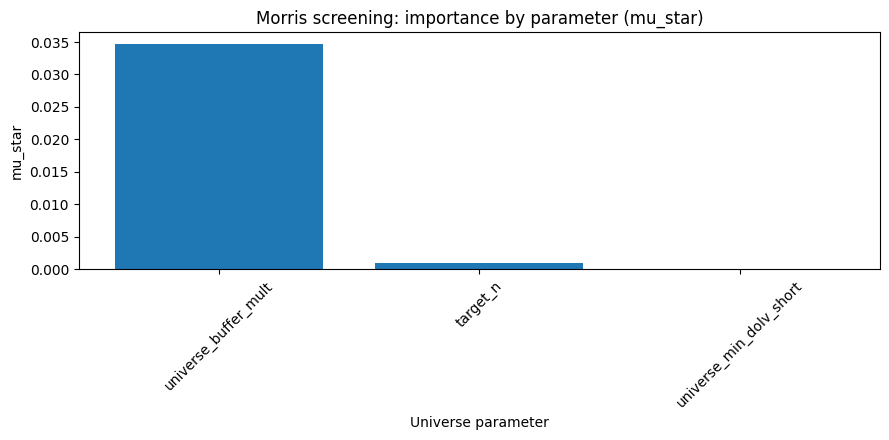

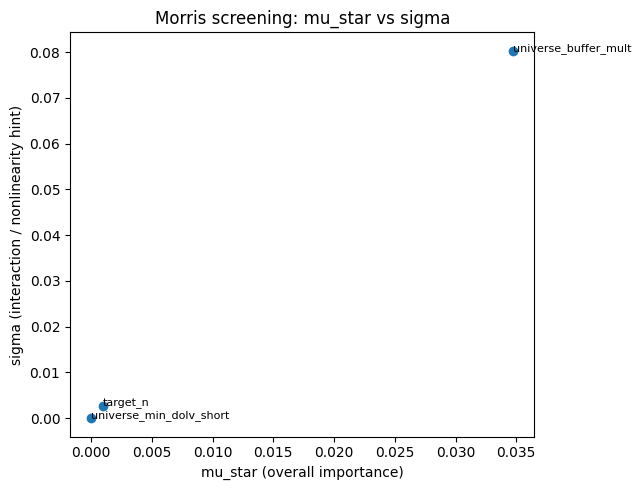

### B. Raw input selection path (Method A / SFFS)

**Method A - Input SFFS trace**

,step,action,groups,score
0,0,start,(),0.789313
1,1,add:dax,"(dax,)",0.874877


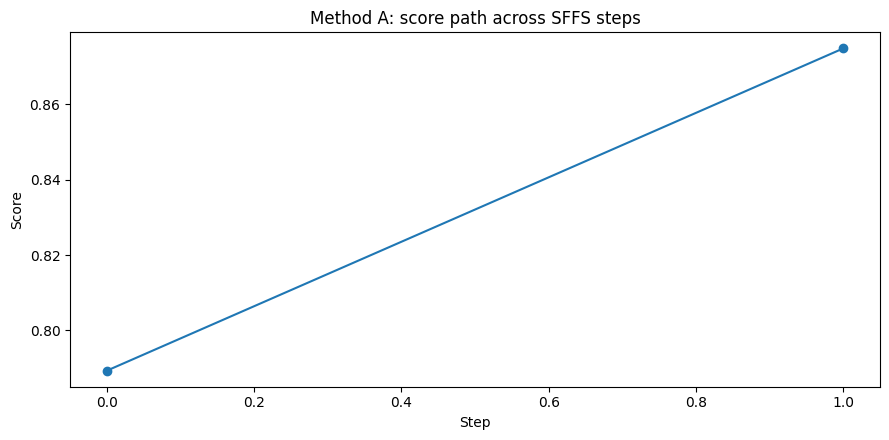

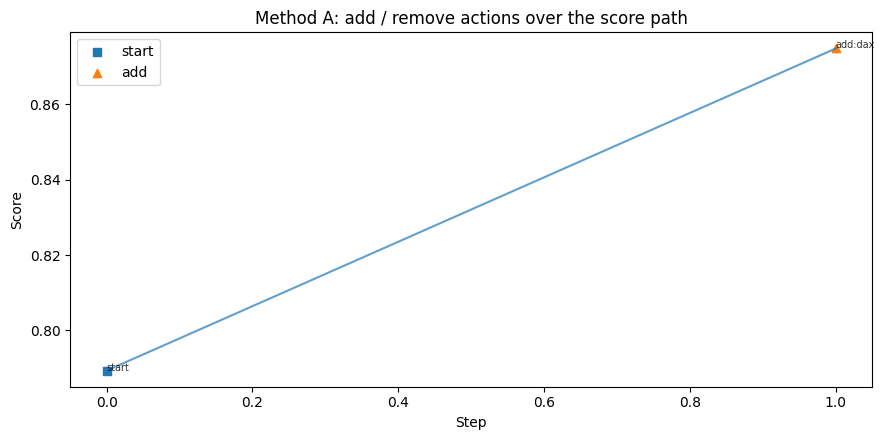

Final selected input groups: ['dax']
Final Method A score: 0.8748773971096427


### C. Feature relevance and redundancy (Method D / mRMR)

**Method D - Feature mRMR ranking**

,rank,feature,mrmr_score,relevance,avg_redundancy_to_selected
0,1,hl_range_lag1,0.074681,0.074681,0.000000
1,2,gap_lag1,0.017092,0.017822,0.000731
2,3,intraday_ret_lag1,0.016777,0.030557,0.013780
3,4,mom60,-0.030562,0.028717,0.059279
6,7,vol20,-0.059673,0.067120,0.126793
7,8,dax_ret,-0.060992,0.044388,0.105380
4,5,upper_wick_lag1,-0.071705,0.002144,0.073849
9,10,mom252_z,-0.075332,0.023564,0.098896
5,6,volz20_z,-0.079516,0.003691,0.083206
8,9,lower_wick_lag1,-0.079663,0.000000,0.079663


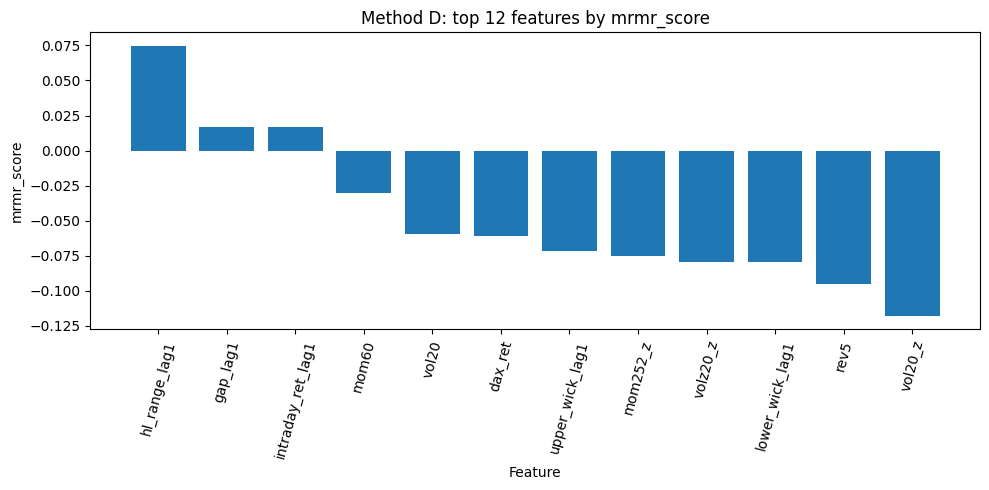

**Method D - Feature relevance**

,feature,relevance
11,hl_range_lag1,0.074681
4,vol20,0.067120
21,dax_ret,0.044388
16,vol20_z,0.041679
19,hl_range_lag1_z,0.034314
6,prc_ma60,0.032055
10,intraday_ret_lag1,0.030557
1,mom60,0.028717
0,mom20,0.027544
15,mom252_z,0.023564


**Method D - Redundancy matrix (top-left preview)**

,mom20,mom60,mom252,rev5,vol20,prc_ma20,prc_ma60,volz20,rsi14,gap_lag1,intraday_ret_lag1,hl_range_lag1,clv_lag1,upper_wick_lag1,lower_wick_lag1,mom252_z,vol20_z,volz20_z,intraday_ret_lag1_z,hl_range_lag1_z
mom20,1.000000,0.507774,0.273431,0.438498,0.036634,0.823972,0.797323,0.066653,0.773200,0.046374,0.178259,0.096931,0.171000,0.008015,0.033916,0.218897,0.040725,0.018509,0.134972,0.015641
mom60,0.507774,1.000000,0.467455,0.233435,0.044173,0.425770,0.813859,0.025423,0.405626,0.045591,0.086366,0.045880,0.087203,0.004041,0.018436,0.408366,0.069023,0.010949,0.073518,0.071377
mom252,0.273431,0.467455,1.000000,0.137191,0.115228,0.237635,0.413025,0.005155,0.209990,0.056697,0.035803,0.084265,0.049036,0.033228,0.014482,0.896409,0.228984,0.004605,0.030907,0.179459
rev5,0.438498,0.233435,0.137191,1.000000,0.040493,0.709139,0.419321,0.081650,0.524098,0.152409,0.339570,0.066900,0.303207,0.024590,0.002992,0.102742,0.032059,0.021239,0.252902,0.021112
vol20,0.036634,0.044173,0.115228,0.040493,1.000000,0.015610,0.052561,0.025818,0.101167,0.038693,0.011069,0.608627,0.001846,0.046608,0.040451,0.211672,0.806099,0.011587,0.001501,0.482112
prc_ma20,0.823972,0.425770,0.237635,0.709139,0.015610,1.000000,0.723428,0.090164,0.889322,0.114351,0.295760,0.096873,0.269477,0.015984,0.021107,0.185980,0.046651,0.001279,0.221984,0.021086
prc_ma60,0.797323,0.813859,0.413025,0.419321,0.052561,0.723428,1.000000,0.048946,0.678521,0.057783,0.164453,0.081395,0.153769,0.001360,0.019771,0.347530,0.054252,0.012994,0.131968,0.045295
volz20,0.066653,0.025423,0.005155,0.081650,0.025818,0.090164,0.048946,1.000000,0.082736,0.015069,0.020176,0.372814,0.033721,0.100300,0.120227,0.002288,0.005518,0.786448,0.045229,0.257218
rsi14,0.773200,0.405626,0.209990,0.524098,0.101167,0.889322,0.678521,0.082736,1.000000,0.058515,0.207540,0.163993,0.205223,0.009404,0.039552,0.148760,0.047492,0.013819,0.156602,0.042052
gap_lag1,0.046374,0.045591,0.056697,0.152409,0.038693,0.114351,0.057783,0.015069,0.058515,1.000000,0.009112,0.000731,0.038731,0.099905,0.060303,0.041721,0.034609,0.015342,0.035533,0.024117


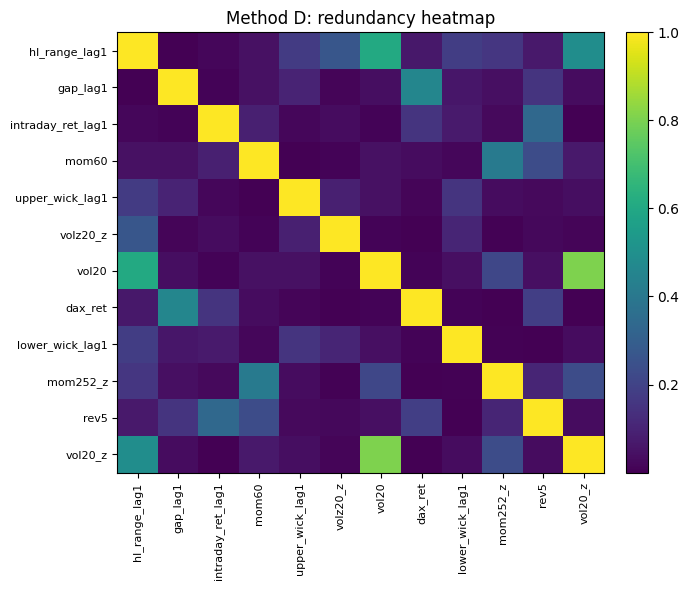

Selected feature shortlist: ['hl_range_lag1', 'gap_lag1', 'intraday_ret_lag1', 'mom60', 'upper_wick_lag1', 'volz20_z', 'vol20', 'dax_ret', 'lower_wick_lag1', 'mom252_z', 'rev5', 'vol20_z']


### D. Hyperparameter sweeps (Method G / Coordinate Search)

**Method G - Best hyperparameter configuration**

,value
start,2010-01-01
end,2025-12-31
tickers,"[AAPL, MSFT, AMZN, NVDA, GOOGL, META, BRK-B, J..."
top_n,20
seq_len,20
train_end,2017-12-31
val_end,2019-12-31
feature_batches,"[intraday_lagged, cross_sectional, structural]"
universe_mode,buffered_v2
universe_buffer_mult,1.5


**Method G - Sweep table for `lr`**

,param_name,candidate_value,net_sharpe
0,lr,0.0001,0.789091
1,lr,0.0003,0.790112
2,lr,0.0010,0.728667
3,lr,0.0030,0.624416


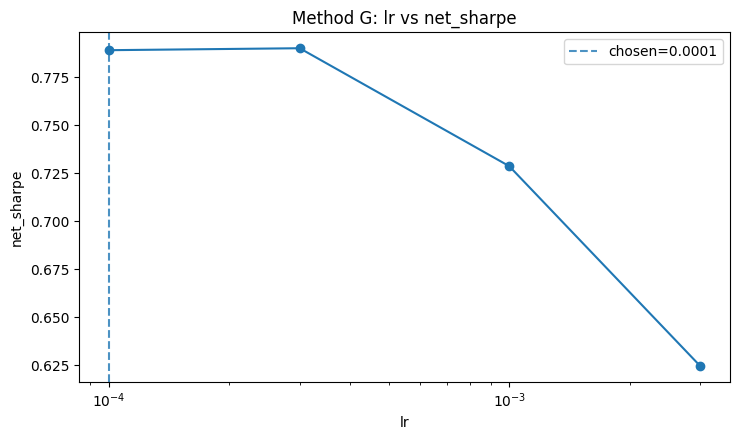

**Method G - Sweep table for `lam_embedded`**

,param_name,candidate_value,net_sharpe
0,lam_embedded,0.2,0.829670
1,lam_embedded,0.5,0.751398
2,lam_embedded,0.8,0.789091
3,lam_embedded,1.0,0.800614


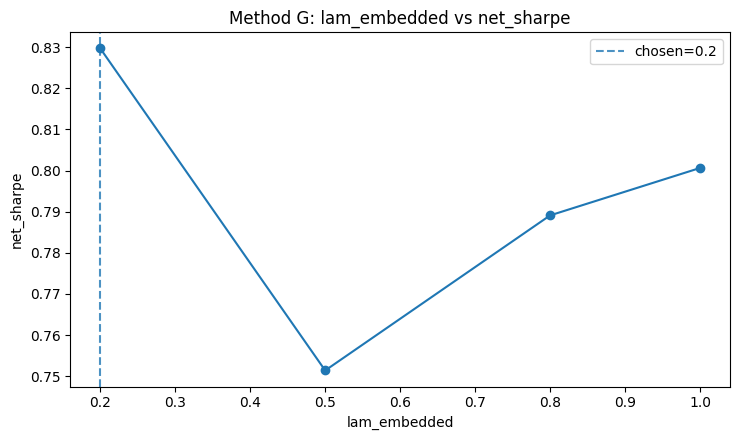

**Method G - Sweep table for `k_turn`**

,param_name,candidate_value,net_sharpe
0,k_turn,0.00,0.892004
1,k_turn,0.02,0.838223
2,k_turn,0.05,0.829670
3,k_turn,0.10,0.731622


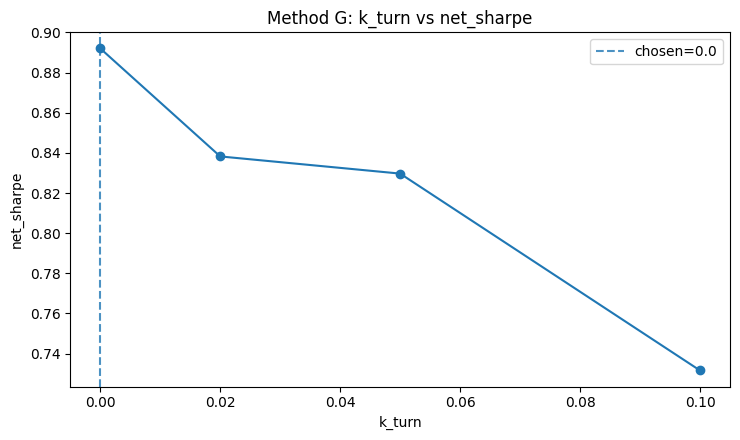

**Method G - Sweep table for `k_conc`**

,param_name,candidate_value,net_sharpe
0,k_conc,0.00,0.886924
1,k_conc,0.02,0.784969
2,k_conc,0.05,0.892004
3,k_conc,0.10,0.910412


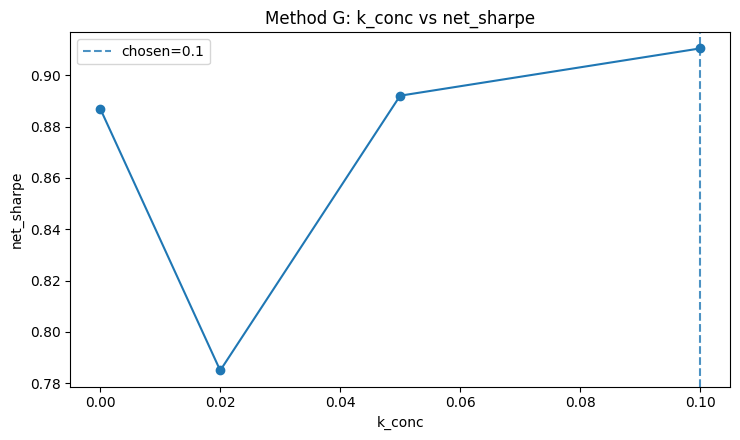

**Method G - Sweep table for `max_w`**

,param_name,candidate_value,net_sharpe
0,max_w,0.01,0.415969
1,max_w,0.02,0.910412
2,max_w,0.03,0.857672


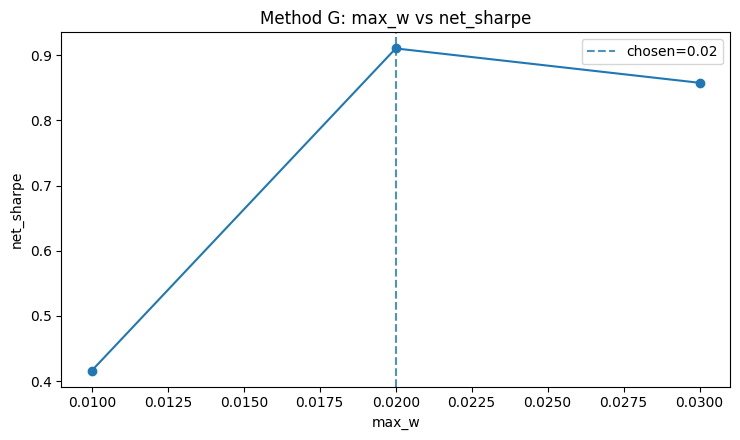

### E. Compact research takeaway

===== RESEARCH TAKEAWAY =====

Top universe parameters by Morris mu_star:


,param,mu,mu_star,sigma
1,universe_buffer_mult,0.023255,0.034754,0.080335
0,target_n,0.000941,0.000992,0.002568
2,universe_min_dolv_short,0.000000,0.000000,0.000000



Selected input groups:
['dax']

Top selected features:
['hl_range_lag1', 'gap_lag1', 'intraday_ret_lag1', 'mom60', 'upper_wick_lag1', 'volz20_z', 'vol20', 'dax_ret', 'lower_wick_lag1', 'mom252_z', 'rev5', 'vol20_z']

Best hyperparameter configuration found so far:


,value
start,2010-01-01
end,2025-12-31
tickers,"[AAPL, MSFT, AMZN, NVDA, GOOGL, META, BRK-B, J..."
top_n,20
seq_len,20
train_end,2017-12-31
val_end,2019-12-31
feature_batches,"[intraday_lagged, cross_sectional, structural]"
universe_mode,buffered_v2
universe_buffer_mult,1.5



Objective used in this pass: net_sharpe


In [40]:
# ----------------------------
# 12G.3 Run the diagnostic dashboard
# ----------------------------
display(Markdown("## Diagnostic dashboard from `res`"))

if not isinstance(res, dict):
    raise ValueError("`res` does not exist or is not a dictionary. Run the execution cell above first.")

display(Markdown("### A. Universe-selection sensitivity (Method L / Morris)"))
_plot_morris_summary(res.get("morris", None))

display(Markdown("### B. Raw input selection path (Method A / SFFS)"))
_plot_method_a_trace(res.get("method_a", None))

display(Markdown("### C. Feature relevance and redundancy (Method D / mRMR)"))
_plot_method_d_results(res.get("method_d", None), top_n=15)

display(Markdown("### D. Hyperparameter sweeps (Method G / Coordinate Search)"))
_plot_method_g_results(res.get("method_g", None), objective_name=RESEARCH_DASHBOARD_OBJECTIVE)

display(Markdown("### E. Compact research takeaway"))
_print_research_takeaway(res, objective_name=RESEARCH_DASHBOARD_OBJECTIVE)


## 12H. Stress tests connected to the research pipeline

> **What this section does:** adds stress-test helpers that plug directly into the updated research flow built around `res`, `build_research_bundle(...)`, and `evaluate_embedded_bundle(...)`.  
> **Why it matters:** these tests let you answer a sharper question than screening alone: after you choose inputs, features, hyperparameters, and universe knobs, **how fragile is the current choice if you remove or perturb one thing at a time?**

### What you should run **before** this section

Run these earlier cells first:

1. The main notebook setup and function-definition sections.
2. The research-method cells that define:
   - `build_research_bundle(...)`
   - `evaluate_embedded_bundle(...)`
   - Method A / D / G / L helpers
3. The minimal research sequence and dashboard cells:
   ```python
   res = run_minimal_research_sequence(...)
   ```
   and then the diagnostic dashboard section.

### How these stress tests are organized

This section uses the current research state stored in `res`:

- `res["method_a"]["selected_groups"]` for selected raw input groups
- `res["method_d"]["selected_features"]` for selected features
- `res["method_g"]["best_config"]` for the best hyperparameter configuration found so far
- `res["assets"]["config"]`, `res["assets"]["data"]`, and `res["assets"]["context_data"]` to avoid rebuilding from scratch

### Which stress test to use

- **Raw inputs:** leave-one-group-out ablation  
- **Features:** leave-one-feature-out ablation  
- **Feature families:** remove one family at a time  
- **Hyperparameters:** local one-at-a-time sensitivity sweep  
- **Universe-selection hyperparameters:** local one-at-a-time sensitivity sweep

### Expected output

Each stress test returns a DataFrame with the same evaluation backbone and then plots the chosen metric, usually `net_sharpe`, across the perturbations.

### Recommended run order

Run them in this order:

```python
stress_test_inputs_leave_one_out(res)
stress_test_feature_families(res)
stress_test_features_leave_one_out(res)

stress_test_hyperparameter(res, "lr", [5e-5, 1e-4, 2e-4, 5e-4, 1e-3])
stress_test_hyperparameter(res, "lam_embedded", [0.2, 0.4, 0.8, 1.2, 1.6])

stress_test_universe_param(res, "universe_buffer_mult", [1.1, 1.3, 1.5, 1.7, 1.9])
stress_test_universe_param(res, "top_n", [10, 15, 20, 25, 30])
```

A quick interpretation rule:

- **big deterioration after removing something** → that ingredient is important  
- **flat curve around a parameter value** → stable region  
- **sharp spike** → fragile tuning  
- **little change** → low sensitivity / likely lower priority


In [36]:

# ----------------------------
# 12H.1 Stress-test helpers wired to the research pipeline
# ----------------------------
from copy import deepcopy
from IPython.display import display, Markdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

STRESS_DEFAULT_OBJECTIVE = "sharpe"
STRESS_DEFAULT_SEEDS = (42,)
STRESS_DEFAULT_AGGREGATE = "median"
STRESS_DEFAULT_METRIC_COL = "net_sharpe"

def _stress_get_reference_state(res):
    if not isinstance(res, dict):
        raise ValueError("`res` must be the output of run_minimal_research_sequence(...).")

    if "assets" not in res or "config" not in res["assets"]:
        raise ValueError("`res['assets']['config']` is missing. Re-run the minimal research sequence.")

    cfg = deepcopy(res["assets"]["config"])
    data = res["assets"].get("data", None)
    context_data = res["assets"].get("context_data", None)

    selected_groups = []
    if isinstance(res.get("method_a"), dict):
        selected_groups = list(res["method_a"].get("selected_groups", []))

    selected_features = []
    if isinstance(res.get("method_d"), dict):
        selected_features = list(res["method_d"].get("selected_features", []))

    best_config = {}
    if isinstance(res.get("method_g"), dict):
        best_config = deepcopy(res["method_g"].get("best_config", {}))

    return {
        "config": cfg,
        "data": data,
        "context_data": context_data,
        "selected_groups": selected_groups,
        "selected_features": selected_features,
        "best_config": best_config,
    }

def _stress_metric_label(metric_col):
    aliases = {
        "net_sharpe": "Net Sharpe",
        "net_cagr": "Net CAGR",
        "net_maxdd": "Net MaxDD",
        "gross_sharpe": "Gross Sharpe",
        "final_equity": "Final equity",
        "alpha": "Alpha",
        "avg_turnover": "Average turnover",
    }
    return aliases.get(metric_col, metric_col)

def _stress_eval_from_state(
    res,
    *,
    cfg_override=None,
    selected_input_groups=None,
    selected_feature_names=None,
    config_override=None,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    return_details=False,
):
    state = _stress_get_reference_state(res)
    cfg = deepcopy(state["config"])
    if cfg_override:
        cfg.update(deepcopy(cfg_override))
    if config_override:
        cfg.update(deepcopy(config_override))
    if state["best_config"]:
        cfg.update(deepcopy(state["best_config"]))

    groups = state["selected_groups"] if selected_input_groups is None else list(selected_input_groups)
    feats = state["selected_features"] if selected_feature_names is None else list(selected_feature_names)

    bundle = build_research_bundle(
        cfg,
        data=state["data"],
        context_data=state["context_data"],
        selected_input_groups=groups,
        selected_feature_names=feats,
        verbose=False,
    )
    ev = evaluate_embedded_bundle(
        bundle,
        config_overrides=None,
        objective=objective,
        seed_list=seed_list,
        aggregate=aggregate,
        return_details=return_details,
        verbose=False,
    )
    return {"config": cfg, "bundle": bundle, "evaluation": ev}

def _stress_rows_to_df(rows, sort_by=None, ascending=False):
    df = pd.DataFrame(rows)
    if sort_by is not None and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)
    return df

def _stress_display_df(df, title=None):
    if title:
        display(Markdown(f"### {title}"))
    display(df)

def _stress_plot_barh(df, label_col, metric_col, title, figsize=(10, 6)):
    tmp = df.copy()
    if metric_col not in tmp.columns:
        raise ValueError(f"`{metric_col}` not found in DataFrame columns.")
    tmp = tmp.sort_values(metric_col)
    plt.figure(figsize=figsize)
    plt.barh(tmp[label_col].astype(str), tmp[metric_col])
    plt.title(title)
    plt.xlabel(_stress_metric_label(metric_col))
    plt.ylabel(label_col.replace("_", " ").title())
    plt.grid(True, axis="x", alpha=0.25)
    plt.show()

def _stress_plot_line(df, x_col, metric_col, title, use_log_if_wide=True, figsize=(8, 5)):
    tmp = df.copy()
    plt.figure(figsize=figsize)
    plt.plot(tmp[x_col], tmp[metric_col], marker="o")
    plt.title(title)
    plt.xlabel(x_col)
    plt.ylabel(_stress_metric_label(metric_col))
    x_num = pd.to_numeric(tmp[x_col], errors="coerce")
    if use_log_if_wide and x_num.notna().all() and len(x_num) > 1:
        positive = (x_num > 0).all()
        xmin, xmax = float(x_num.min()), float(x_num.max())
        if positive and xmin > 0 and (xmax / xmin) >= 50:
            plt.xscale("log")
    plt.grid(True, alpha=0.3)
    plt.show()

def _stress_pick_metric(df, preferred=STRESS_DEFAULT_METRIC_COL):
    if preferred in df.columns:
        return preferred
    numeric = list(df.select_dtypes(include=[np.number]).columns)
    if not numeric:
        raise ValueError("No numeric metric column found for plotting.")
    return numeric[0]

def _stress_selected_feature_families(selected_features):
    fam_map = {}
    for fam, feats in FEATURE_FAMILY_CANDIDATES.items():
        keep = [f for f in selected_features if f in feats]
        if keep:
            fam_map[fam] = keep
    return fam_map


In [37]:

# ----------------------------
# 12H.2 Stress tests
# ----------------------------
def stress_test_inputs_leave_one_out(
    res,
    *,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    verbose=True,
):
    state = _stress_get_reference_state(res)
    groups = list(state["selected_groups"])
    if not groups:
        raise ValueError("No selected input groups found in res['method_a']['selected_groups'].")

    rows = []
    ref = _stress_eval_from_state(res, objective=objective, seed_list=seed_list, aggregate=aggregate)
    row = {"dropped_input_group": "(none)"}
    row.update(ref["evaluation"]["rows"].mean(numeric_only=True).to_dict())
    rows.append(row)

    for grp in groups:
        kept = [g for g in groups if g != grp]
        out = _stress_eval_from_state(
            res,
            selected_input_groups=kept,
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
        )
        row = {"dropped_input_group": grp}
        row.update(out["evaluation"]["rows"].mean(numeric_only=True).to_dict())
        rows.append(row)

    df = _stress_rows_to_df(rows)
    if verbose:
        _stress_display_df(df, "Raw input-group leave-one-out stress test")
        metric_col = _stress_pick_metric(df, metric_col)
        _stress_plot_barh(df, "dropped_input_group", metric_col,
                          f"Raw input-group ablation: {_stress_metric_label(metric_col)}")
    return df

def stress_test_feature_families(
    res,
    *,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    verbose=True,
):
    state = _stress_get_reference_state(res)
    selected_features = list(state["selected_features"])
    if not selected_features:
        raise ValueError("No selected features found in res['method_d']['selected_features'].")

    fam_map = _stress_selected_feature_families(selected_features)
    if not fam_map:
        raise ValueError("Could not map selected features to known feature families.")

    rows = []
    ref = _stress_eval_from_state(res, objective=objective, seed_list=seed_list, aggregate=aggregate)
    row = {"removed_family": "(none)"}
    row.update(ref["evaluation"]["rows"].mean(numeric_only=True).to_dict())
    rows.append(row)

    for fam, fam_feats in fam_map.items():
        kept = [f for f in selected_features if f not in fam_feats]
        out = _stress_eval_from_state(
            res,
            selected_feature_names=kept,
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
        )
        row = {"removed_family": fam}
        row.update(out["evaluation"]["rows"].mean(numeric_only=True).to_dict())
        rows.append(row)

    df = _stress_rows_to_df(rows)
    if verbose:
        _stress_display_df(df, "Feature-family stress test")
        metric_col = _stress_pick_metric(df, metric_col)
        _stress_plot_barh(df, "removed_family", metric_col,
                          f"Feature-family stress test: {_stress_metric_label(metric_col)}")
    return df

def stress_test_features_leave_one_out(
    res,
    *,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    verbose=True,
):
    state = _stress_get_reference_state(res)
    feats = list(state["selected_features"])
    if not feats:
        raise ValueError("No selected features found in res['method_d']['selected_features'].")

    rows = []
    ref = _stress_eval_from_state(res, objective=objective, seed_list=seed_list, aggregate=aggregate)
    row = {"dropped_feature": "(none)"}
    row.update(ref["evaluation"]["rows"].mean(numeric_only=True).to_dict())
    rows.append(row)

    for feat in feats:
        kept = [f for f in feats if f != feat]
        out = _stress_eval_from_state(
            res,
            selected_feature_names=kept,
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
        )
        row = {"dropped_feature": feat}
        row.update(out["evaluation"]["rows"].mean(numeric_only=True).to_dict())
        rows.append(row)

    df = _stress_rows_to_df(rows)
    if verbose:
        _stress_display_df(df, "Feature leave-one-out stress test")
        metric_col = _stress_pick_metric(df, metric_col)
        _stress_plot_barh(df, "dropped_feature", metric_col,
                          f"Feature ablation: {_stress_metric_label(metric_col)} after dropping one feature")
    return df

def stress_test_hyperparameter(
    res,
    param_name,
    candidate_values,
    *,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    verbose=True,
):
    rows = []
    for val in candidate_values:
        out = _stress_eval_from_state(
            res,
            cfg_override={param_name: val},
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
        )
        row = {"param_name": param_name, "param_value": val}
        row.update(out["evaluation"]["rows"].mean(numeric_only=True).to_dict())
        rows.append(row)

    df = _stress_rows_to_df(rows, sort_by="param_value", ascending=True)
    if verbose:
        _stress_display_df(df, f"Hyperparameter local sensitivity: {param_name}")
        metric_col = _stress_pick_metric(df, metric_col)
        _stress_plot_line(df, "param_value", metric_col,
                          f"Hyperparameter stress test: {param_name} vs {_stress_metric_label(metric_col)}")
    return df

def stress_test_universe_param(
    res,
    param_name,
    candidate_values,
    *,
    objective=STRESS_DEFAULT_OBJECTIVE,
    seed_list=STRESS_DEFAULT_SEEDS,
    aggregate=STRESS_DEFAULT_AGGREGATE,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    verbose=True,
):
    rows = []
    for val in candidate_values:
        out = _stress_eval_from_state(
            res,
            cfg_override={param_name: val},
            objective=objective,
            seed_list=seed_list,
            aggregate=aggregate,
        )
        row = {"param_name": param_name, "param_value": val}
        row.update(out["evaluation"]["rows"].mean(numeric_only=True).to_dict())
        rows.append(row)

    df = _stress_rows_to_df(rows, sort_by="param_value", ascending=True)
    if verbose:
        _stress_display_df(df, f"Universe-parameter local sensitivity: {param_name}")
        metric_col = _stress_pick_metric(df, metric_col)
        _stress_plot_line(df, "param_value", metric_col,
                          f"Universe stress test: {param_name} vs {_stress_metric_label(metric_col)}")
    return df


In [38]:
# ----------------------------
# 12H.3 Application helpers
# ----------------------------
def stress_compare_to_reference(
    df,
    label_col,
    *,
    metric_col=STRESS_DEFAULT_METRIC_COL,
    reference_label="(none)",
    sort_desc=True,
):
    """
    Add delta-vs-reference columns for ablation-style tests.
    Positive delta means better than the reference for the selected metric.
    In a leave-one-out test, if dropping an item makes the metric worse,
    the dropped item was important.
    """
    if metric_col not in df.columns:
        metric_col = _stress_pick_metric(df, metric_col)

    out = df.copy()
    ref_rows = out[out[label_col].astype(str) == str(reference_label)]
    if ref_rows.empty:
        raise ValueError(f"Reference label `{reference_label}` not found in `{label_col}`.")
    ref_val = float(ref_rows.iloc[0][metric_col])

    out[f"delta_{metric_col}"] = out[metric_col] - ref_val

    # For leave-one-out ablations:
    # more negative delta => dropping this item hurt performance more => item is more important
    out["importance_proxy"] = -out[f"delta_{metric_col}"]
    out["reference_metric"] = ref_val

    order_cols = [label_col, metric_col, f"delta_{metric_col}", "importance_proxy"]
    other_cols = [c for c in out.columns if c not in order_cols]
    out = out[order_cols + other_cols]

    # keep reference row first, then sort the rest by importance
    ref_block = out[out[label_col].astype(str) == str(reference_label)]
    rest = out[out[label_col].astype(str) != str(reference_label)].sort_values("importance_proxy", ascending=False)
    return pd.concat([ref_block, rest], axis=0).reset_index(drop=True)


def stress_rank_local_sensitivity(
    df,
    *,
    param_col="param_value",
    metric_col=STRESS_DEFAULT_METRIC_COL,
):
    """
    Add a small diagnostic summary for hyperparameter/universe local sweeps:
    - best observed row
    - delta vs best
    - whether the curve looks flat-ish around the best value
    """
    if metric_col not in df.columns:
        metric_col = _stress_pick_metric(df, metric_col)

    out = df.copy().sort_values(param_col).reset_index(drop=True)
    best_idx = out[metric_col].idxmax()
    best_val = float(out.loc[best_idx, metric_col])

    out["delta_vs_best"] = out[metric_col] - best_val
    out["abs_delta_vs_best"] = out["delta_vs_best"].abs()

    return out


def stress_print_takeaway_ablation(df, label_col, *, metric_col=STRESS_DEFAULT_METRIC_COL, top_k=3):
    if metric_col not in df.columns:
        metric_col = _stress_pick_metric(df, metric_col)
    comp = stress_compare_to_reference(df, label_col, metric_col=metric_col)
    display(Markdown(f"#### Takeaway ranked by importance proxy ({_stress_metric_label(metric_col)})"))
    display(comp.head(top_k + 1))


def stress_print_takeaway_sensitivity(df, *, metric_col=STRESS_DEFAULT_METRIC_COL, top_k=5):
    if metric_col not in df.columns:
        metric_col = _stress_pick_metric(df, metric_col)
    comp = stress_rank_local_sensitivity(df, metric_col=metric_col)
    display(Markdown(f"#### Local sensitivity view ({_stress_metric_label(metric_col)})"))
    display(comp.head(top_k))

### 12H.4 How to run the stress tests

Run these **before** the application cells below:

1. All main setup and function-definition sections.
2. The research methods and dashboard sections.
3. The execution cell:
   ```python
   res = run_minimal_research_sequence(...)
   ```

Then run the stress-test application cells **from top to bottom**, one section at a time:

1. **Input-group stress test**
2. **Feature-family stress test**
3. **Feature leave-one-out stress test**
4. **Hyperparameter local stability test**
5. **Universe-parameter local stability test**

Each application cell is active code, not a template.  
Run one section, inspect the table and plot, then move to the next.

### 12H.5 Input-group stress test application

> **What this does:** removes one selected raw input group at a time, re-evaluates the embedded pipeline, and plots the chosen metric.  
> **What you should run before this:** the dashboard stress-test helper section and `res = run_minimal_research_sequence(...)`.  
> **How to read it:** if dropping one input group causes a strong deterioration versus `(none)`, that input group is important.

In [42]:
# ----------------------------
# 12H.5 Run input-group stress test
# ----------------------------
INPUT_STRESS_OBJECTIVE = STRESS_DEFAULT_OBJECTIVE
INPUT_STRESS_SEEDS = STRESS_DEFAULT_SEEDS
INPUT_STRESS_AGGREGATE = STRESS_DEFAULT_AGGREGATE
INPUT_STRESS_METRIC = STRESS_DEFAULT_METRIC_COL

input_stress_df = stress_test_inputs_leave_one_out(
    res,
    objective=INPUT_STRESS_OBJECTIVE,
    seed_list=INPUT_STRESS_SEEDS,
    aggregate=INPUT_STRESS_AGGREGATE,
    metric_col=INPUT_STRESS_METRIC,
    verbose=True,
)

input_stress_analysis = stress_compare_to_reference(
    input_stress_df,
    "dropped_input_group",
    metric_col=INPUT_STRESS_METRIC,
)

display(Markdown("#### Input-group stress test: delta vs reference"))
display(input_stress_analysis)
stress_print_takeaway_ablation(
    input_stress_df,
    "dropped_input_group",
    metric_col=INPUT_STRESS_METRIC,
)

ValueError: No selected input groups found in res['method_a']['selected_groups'].


### 12H.3 Optional execution examples

> **What this does:** gives you ready-to-run calls for the new stress tests.  
> **Important:** these are slower than the dashboard because each row is a fresh embedded-model evaluation. Start with the smaller tests first.

#### Minimal recommended sequence

```python
input_stress_df = stress_test_inputs_leave_one_out(res)
family_stress_df = stress_test_feature_families(res)
feature_stress_df = stress_test_features_leave_one_out(res)
```

#### Then check local stability around the chosen hyperparameters

```python
hp_lr_df = stress_test_hyperparameter(res, "lr", [5e-5, 1e-4, 2e-4, 5e-4, 1e-3])
hp_lam_df = stress_test_hyperparameter(res, "lam_embedded", [0.2, 0.4, 0.8, 1.2, 1.6])
```

#### Then check the main universe knobs

```python
u_buffer_df = stress_test_universe_param(res, "universe_buffer_mult", [1.1, 1.3, 1.5, 1.7, 1.9])
u_topn_df = stress_test_universe_param(res, "top_n", [10, 15, 20, 25, 30])
u_dolv_df = stress_test_universe_param(res, "universe_min_dolv_short", [2e6, 5e6, 1e7, 2e7])
```

### How to interpret the output

- If dropping one **input group** causes a big deterioration, that group is important.
- If dropping one **feature** causes a big deterioration, that feature is operationally important after retraining.
- If a **hyperparameter** plot is flat around the current value, that setting is stable.
- If a **hyperparameter** or **universe** plot has a sharp spike, your chosen value may be fragile.
- If a **universe parameter** barely moves the metric, it is probably lower priority than the others.


In [ ]:

# ----------------------------
# 12H.3 Example calls (run manually, one by one)
# ----------------------------
input_stress_df = stress_test_inputs_leave_one_out(res)
family_stress_df = stress_test_feature_families(res)
feature_stress_df = stress_test_features_leave_one_out(res)

# hp_lr_df = stress_test_hyperparameter(res, "lr", [5e-5, 1e-4, 2e-4, 5e-4, 1e-3])
# hp_lam_df = stress_test_hyperparameter(res, "lam_embedded", [0.2, 0.4, 0.8, 1.2, 1.6])

# u_buffer_df = stress_test_universe_param(res, "universe_buffer_mult", [1.1, 1.3, 1.5, 1.7, 1.9])
# u_topn_df = stress_test_universe_param(res, "top_n", [10, 15, 20, 25, 30])
# u_dolv_df = stress_test_universe_param(res, "universe_min_dolv_short", [2e6, 5e6, 1e7, 2e7])


## 13. Testing zone (plots, observation of the perfomance of the model)

In [30]:
# Example: long-short, buffered universe, weekly rebalance with shock exceptions + mild smoothing
out_ls = run_experiment(
    top_n=20,
    lam_embedded=0.8,
    weight_mode="long_short",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="buffered_v2",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="W-FRI",
    shock_consecutive_down=3,
    pred_smooth_span=5,
)

print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Embedded final equity:", out_ls["embedded"]["equity"].iloc[-1])


No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)
Train days: 1741, Val days: 503, Test days: 1507
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14']
Avg active universe size per day: 29.6 | target top_n=20 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=3, pred_smooth_span=5

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000061 | train mse 0.002750 | train turn 0.285657 | val pnl +0.000056 | val mse 0.000294 | val turn 0.103402
Epoch 02 | train pnl -0.000161 | train mse 0.000374 | train turn 0.260563 | val pnl +0.000097 | val mse 0.000368 | val turn 0.024909
Epoch 03 | train pnl -0.000046 | train mse 0.000296 | train turn 0.242431 | val pnl +0.000204 | val mse 0.000262 | val turn 0.125346
Epoch 04 | train pnl -0.000063 | train mse 0.000245 | train turn 0.225051 | val pnl +0.000268 | v

In [30]:
print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Baseline final equity:", out_ls["embedded"]["equity"].iloc[-1])
print("Embedded final gross:", out_ls["embedded"]["gross"].iloc[-1])


Baseline final equity: 1.103608150416529
Baseline final equity: 1.1193764450832462
Embedded final gross: 0.0002829181275854058


In [31]:
print("Avg turnover baseline:", out_ls["baseline"]["turnover"].mean())
print("Avg turnover embedded:", out_ls["embedded"]["turnover"].mean())

# If you stored weights: out["baseline"]["weights"] etc. If not, approximate cash as near-zero returns:
cash_like_embedded = (out_ls["embedded"]["gross"].abs() < 1e-8).mean()
print("Embedded ~cash days (gross≈0):", cash_like_embedded)


Avg turnover baseline: 0.02306065748953743
Avg turnover embedded: 0.0035749117628434534
Embedded ~cash days (gross≈0): 0.0


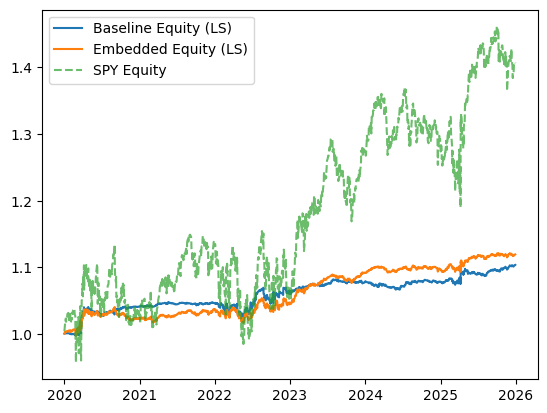

In [32]:
import matplotlib.pyplot as plt
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity (LS)")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity (LS)")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.show()


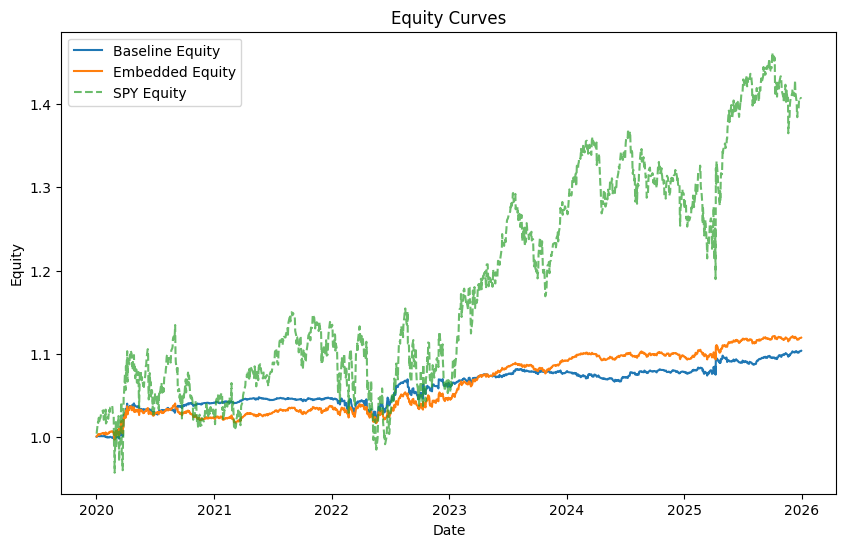

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

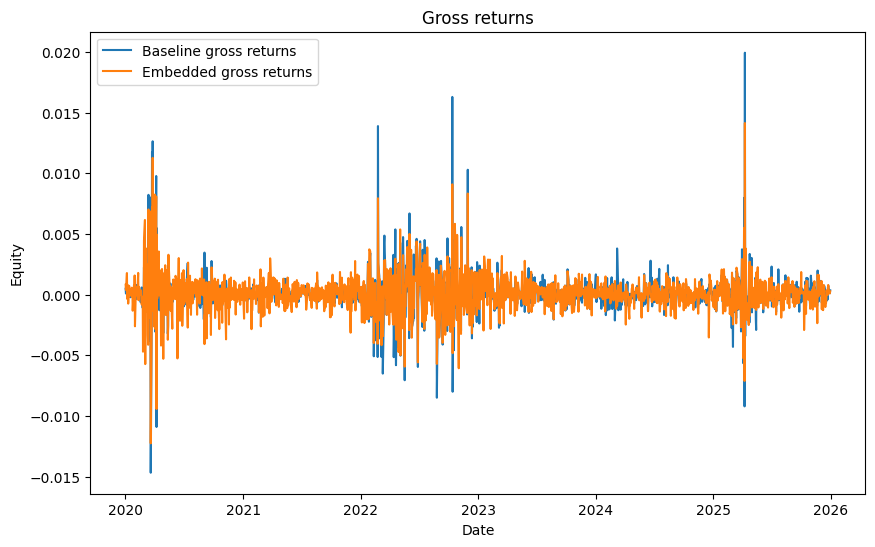

In [34]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["gross"], label="Baseline gross returns")
plt.plot(out_ls["embedded"]["gross"], label="Embedded gross returns")
plt.legend()
plt.title("Gross returns")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

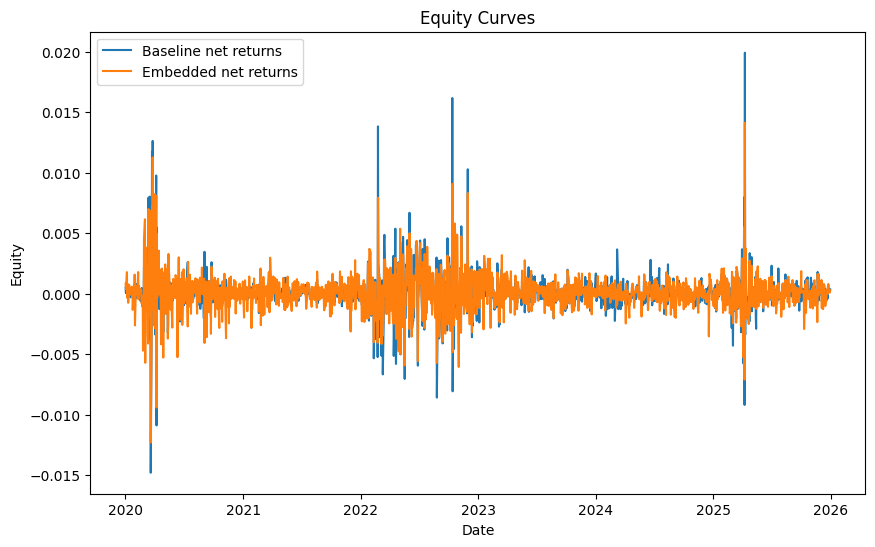

In [35]:
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["net"], label="Baseline net returns")
plt.plot(out_ls["embedded"]["net"], label="Embedded net returns")
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

In [36]:
print("Baseline sharpe - gross returns:", perf_summary(out_ls["baseline"]["gross"])["Sharpe"])
print("Embedded sharpe - gross returns:", perf_summary(out_ls["embedded"]["gross"])["Sharpe"])

print("Baseline sharpe - net returns:", perf_summary(out_ls["baseline"]["net"])["Sharpe"])
print("Embedded sharpe - net returns:", perf_summary(out_ls["embedded"]["net"])["Sharpe"])

Baseline sharpe - gross returns: 0.9453038565251424
Embedded sharpe - gross returns: 0.7970684909646646
Baseline sharpe - net returns: 0.6226443640922419
Embedded sharpe - net returns: 0.7445355262873871


In [37]:
print("Baseline maxDD - gross returns:", perf_summary(out_ls["baseline"]["gross"])["MaxDD"])
print("Embedded maxDD - gross returns:", perf_summary(out_ls["embedded"]["gross"])["MaxDD"])

print("Baseline maxDD - net returns:", perf_summary(out_ls["baseline"]["net"])["MaxDD"])
print("Embedded maxDD - net returns:", perf_summary(out_ls["embedded"]["net"])["MaxDD"])

Baseline maxDD - gross returns: -0.021486318238869595
Embedded maxDD - gross returns: -0.021723650410520157
Baseline maxDD - net returns: -0.024744237863767893
Embedded maxDD - net returns: -0.022725095033134024


In [38]:
perf_summary(out_ls["baseline"]["gross"])

{'CAGR': 0.025522268007303728,
 'Sharpe': 0.9453038565251424,
 'MaxDD': -0.021486318238869595,
 'AvgDailyTurnover': 1.0}

In [39]:
perf_summary(out_ls["embedded"]["gross"])

{'CAGR': 0.02041454416549704,
 'Sharpe': 0.7970684909646646,
 'MaxDD': -0.021723650410520157,
 'AvgDailyTurnover': 1.0}

In [40]:
perf_summary(out_ls["baseline"]["net"])

{'CAGR': 0.01662197277982802,
 'Sharpe': 0.6226443640922419,
 'MaxDD': -0.024744237863767893,
 'AvgDailyTurnover': 1.0}

In [41]:
perf_summary(out_ls["embedded"]["net"])

{'CAGR': 0.019036586022965096,
 'Sharpe': 0.7445355262873871,
 'MaxDD': -0.022725095033134024,
 'AvgDailyTurnover': 1.0}

In [42]:

alpha_e, beta_e, t_e = alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"])
alpha_b, beta_b, t_b = alpha_beta(out_ls["baseline"]["net"], out_ls["spy_rets"])

print("Embedded alpha/day, beta, t(alpha):", alpha_e, beta_e, t_e)
print("Baseline alpha/day, beta, t(alpha):", alpha_b, beta_b, t_b)
print("Embedded alpha/yr approx:", alpha_e * 252)


Embedded alpha/day, beta, t(alpha): 3.306567010049558e-05 0.1581294337930323 2.2832060444126103
Baseline alpha/day, beta, t(alpha): 3.307459396748618e-05 0.12403179538855989 1.0547457230066637
Embedded alpha/yr approx: 0.008332548865324887


In [43]:
# Holdings on the last backtest day (includes longs + shorts)
day = out_ls["embedded"]["holdings"]["date"].max()
(out_ls["embedded"]["holdings"]
 .query("date == @day")
 .sort_values("abs_weight", ascending=False)
 .head(20))


,date,ticker,weight,abs_weight,side,pred_used,pred_raw,ret,rebalanced
45200,2025-12-30,ADBE,0.007148,0.007148,long,0.006342,0.005429,0.001364,0
45189,2025-12-30,UNH,0.006757,0.006757,long,0.006382,0.006173,0.007370,0
45195,2025-12-30,PG,0.006638,0.006638,long,0.006314,0.005724,-0.001663,0
45196,2025-12-30,HD,0.006546,0.006546,long,0.005926,0.005020,0.000925,0
45201,2025-12-30,CRM,0.006544,0.006544,long,0.005794,0.005025,-0.002775,0
45185,2025-12-30,META,0.006517,0.006517,long,0.005863,0.005255,0.011022,0
45204,2025-12-30,ACN,0.006475,0.006475,long,0.005681,0.004588,-0.001590,0
45190,2025-12-30,V,0.006449,0.006449,long,0.006139,0.005640,-0.001073,0
45191,2025-12-30,MA,0.006231,0.006231,long,0.006114,0.005908,0.002326,0
45181,2025-12-30,MSFT,0.006007,0.006007,long,0.005613,0.005114,0.003190,0


In [44]:
alpha_roll, beta_roll = rolling_alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"], window=252)

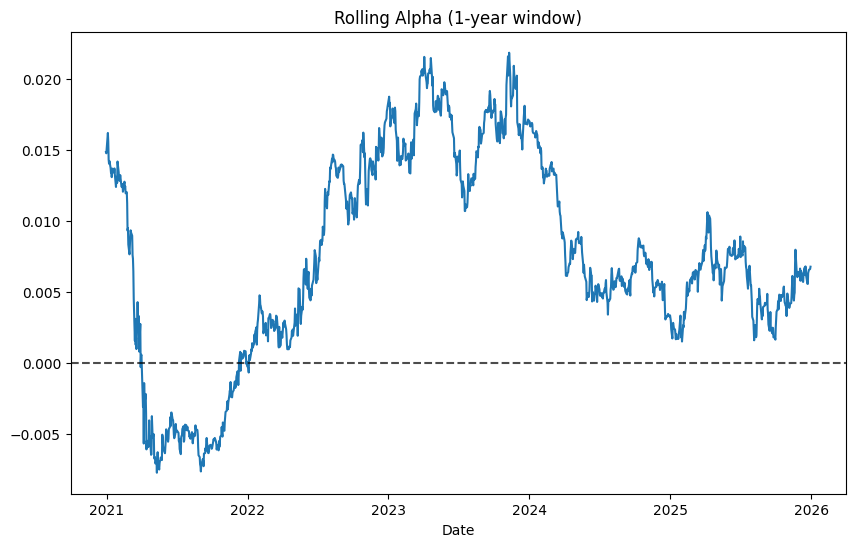

In [45]:
plt.figure(figsize=(10,6))
plt.plot(alpha_roll, label="Rolling Alpha (yr)")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Alpha (1-year window)")  
plt.xlabel("Date")
plt.show()  

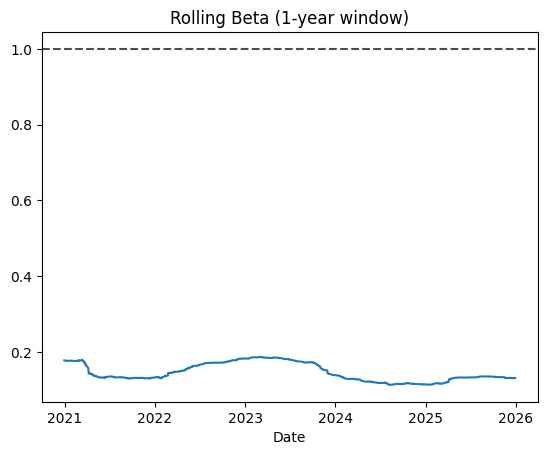

In [46]:
plt.Figure(figsize=(10,6))
plt.plot(beta_roll, label="Rolling Beta")  
plt.axhline(1, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Beta (1-year window)")
plt.xlabel("Date")
plt.show()

In [ ]:
# Example: long-short, buffered universe, weekly rebalance with shock exceptions + mild smoothing
out_ls = run_experiment(
    top_n=20,
    lam_embedded=0.8,
    weight_mode="long_short",
    gross_long=1.0,
    gross_short=1.0,
    universe_mode="buffered_v2",
    universe_buffer_mult=1.5,
    universe_min_dolv_short=5e6,
    rebalance_rule="W-FRI",
    shock_consecutive_down=5,
    pred_smooth_span=0,
    feature_batches=["intraday_lagged", "cross_sectional", "structural"]
)
#    valid = {"intraday_lagged", "cross_sectional", "structural", "interactions"}
print("Baseline final equity:", out_ls["baseline"]["equity"].iloc[-1])
print("Embedded final equity:", out_ls["embedded"]["equity"].iloc[-1])


No tickers provided. Using a minimal liquid default list. (Recommended: pass your own ticker list.)


C:\Users\diego\AppData\Local\Temp\ipykernel_39500\1151844885.py:7: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  ctx_ret = close_ctx.pct_change()


Train days: 1741, Val days: 503, Test days: 1507
Features: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14', 'gap_lag1', 'intraday_ret_lag1', 'hl_range_lag1', 'clv_lag1', 'upper_wick_lag1', 'lower_wick_lag1', 'mom252_z', 'vol20_z', 'volz20_z', 'intraday_ret_lag1_z', 'hl_range_lag1_z', 'clv_lag1_z', 'nikkei_ret', 'dax_ret', 'ftse_ret', 'vix_ret', 'tnx_ret', 'oil_ret', 'gold_ret', 'dxy_ret']
Avg active universe size per day: 29.6 | target top_n=20 | universe_mode=buffered_v2
Weight mode: long_short | gross_long=1.0, gross_short=1.0
Execution: rebalance_rule=W-FRI, shock_consecutive_down=5, pred_smooth_span=0

=== Train baseline (MSE only) ===
Epoch 01 | train pnl -0.000073 | train mse 0.001833 | train turn 0.293745 | val pnl +0.000097 | val mse 0.001188 | val turn 0.046273
Epoch 02 | train pnl -0.000034 | train mse 0.000428 | train turn 0.267859 | val pnl +0.000178 | val mse 0.000417 | val turn 0.163700


In [48]:
print(perf_summary(out_ls["embedded"]["net"]))
print(perf_summary(out_ls["baseline"]["net"]))

{'CAGR': 0.009032103678552783, 'Sharpe': 0.3491542440936378, 'MaxDD': -0.03790733224793108, 'AvgDailyTurnover': 1.0}
{'CAGR': 0.005936465691590342, 'Sharpe': 0.3273426818389238, 'MaxDD': -0.023633026721024852, 'AvgDailyTurnover': 1.0}


In [49]:
alpha_roll, beta_roll = rolling_alpha_beta(out_ls["embedded"]["net"], out_ls["spy_rets"], window=252)

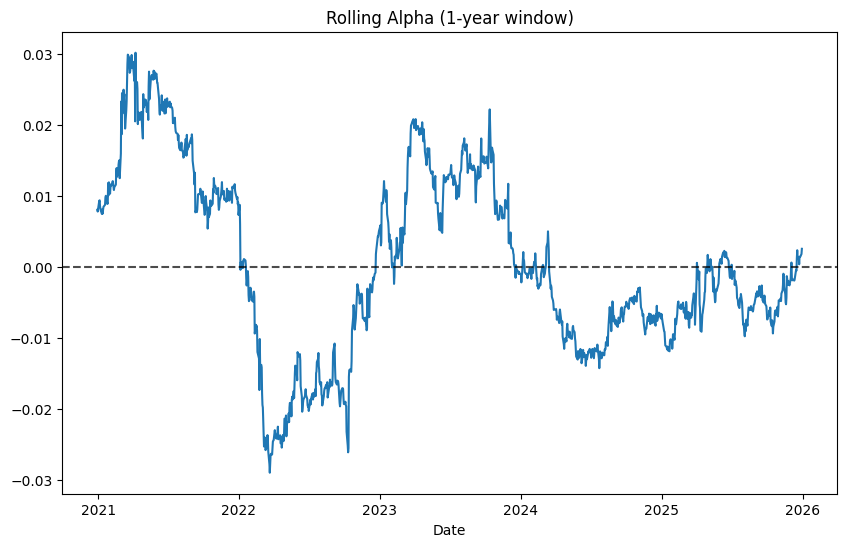

In [50]:
plt.figure(figsize=(10,6))
plt.plot(alpha_roll, label="Rolling Alpha (yr)")
plt.axhline(0, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Alpha (1-year window)")  
plt.xlabel("Date")
plt.show()  

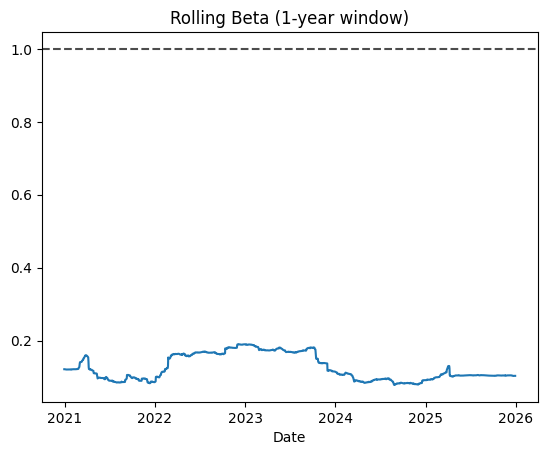

In [51]:
plt.Figure(figsize=(10,6))
plt.plot(beta_roll, label="Rolling Beta")  
plt.axhline(1, color="black", linestyle="--", alpha=0.7)
plt.title("Rolling Beta (1-year window)")
plt.xlabel("Date")
plt.show()

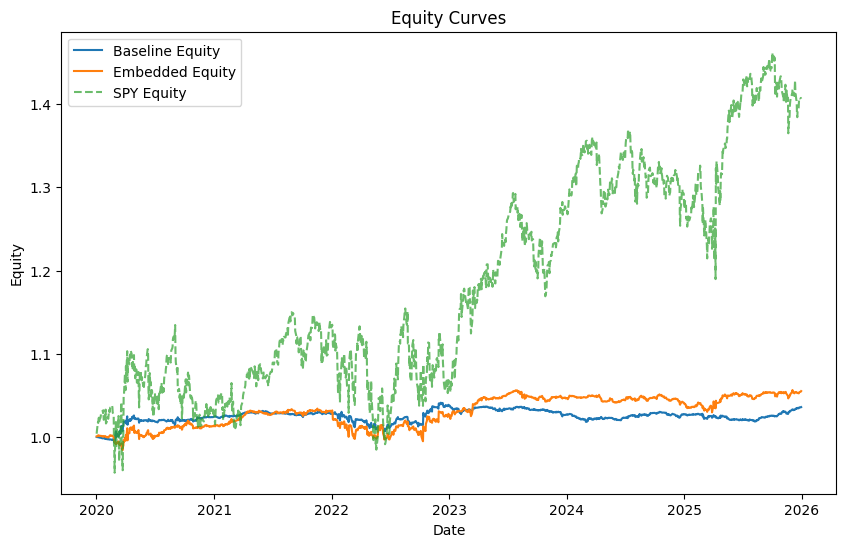

In [52]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(out_ls["baseline"]["equity"], label="Baseline Equity")
plt.plot(out_ls["embedded"]["equity"], label="Embedded Equity")
plt.plot(out_ls["spy_eq"], label="SPY Equity", linestyle="--", alpha=0.7)
plt.legend()
plt.title("Equity Curves")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.show()

## Stress tests (Long-Short)

This section assumes you already ran:

```python
out_ls = run_experiment(..., weight_mode="long_short", gross_long=..., gross_short=...)
```

and uses `out_ls` directly where possible.

We run 4 tests:
1. Cost + slippage sweep (fast, uses stored gross + turnover)
2. Feature ablation (retrain; slower)
3. Placebo: shuffle Y in training (retrain; should kill edge)
4. Monte Carlo (50k bootstrap paths on embedded net returns)


In [53]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helpers: metrics & recompute net under alternative cost assumptions
# ----------------------------

def perf_summary_with_turnover(bt_out, which="net", freq=252):
    'Compute CAGR/Sharpe/MaxDD, plus avg turnover and final equity.'
    r = bt_out[which].dropna()
    if len(r) < 10:
        return {}
    mu = r.mean()
    sd = r.std(ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    eq = (1 + r).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1
    mdd = dd.min()

    cagr = eq.iloc[-1] ** (freq / len(r)) - 1

    avg_to = float(bt_out.get("turnover", pd.Series(index=r.index, data=np.nan)).reindex(r.index).mean())
    return {
        "CAGR": float(cagr),
        "Sharpe": float(sharpe),
        "MaxDD": float(mdd),
        "AvgTurnover": float(avg_to) if np.isfinite(avg_to) else np.nan,
        "FinalEquity": float(eq.iloc[-1]),
        "N": int(len(r)),
    }

def recompute_net_from_gross_and_turnover(bt_out, tc_bps_per_side, slip_bps):
    'Recompute net returns and equity for new costs WITHOUT rerunning the model.'
    gross = bt_out["gross"].copy()
    turnover = bt_out["turnover"].reindex(gross.index).fillna(0.0)

    cost_rate = (tc_bps_per_side + slip_bps) / 1e4
    net = gross - cost_rate * turnover
    eq = (1 + net.fillna(0)).cumprod()

    out = dict(bt_out)  # shallow copy
    out["net_recosted"] = net
    out["equity_recosted"] = eq
    return out

# Sanity: confirm out_ls exists
assert "out_ls" in globals(), "Run your main experiment first so out_ls exists."
print("Using universe size:", len(out_ls["universe"]))
print("Feature names:", out_ls["feat_names"])


Using universe size: 30
Feature names: ['mom20', 'mom60', 'mom252', 'rev5', 'vol20', 'prc_ma20', 'prc_ma60', 'volz20', 'rsi14', 'gap_lag1', 'intraday_ret_lag1', 'hl_range_lag1', 'clv_lag1', 'upper_wick_lag1', 'lower_wick_lag1']


,tc_bps_per_side,slip_bps,total_bps,baseline_sharpe,embedded_sharpe,baseline_cagr,embedded_cagr,baseline_maxdd,embedded_maxdd,baseline_final_eq,embedded_final_eq,avg_turnover_baseline,avg_turnover_embedded
0,5.0,2.0,7.0,0.634540,0.594598,0.011683,0.015666,-0.020329,-0.032827,1.071927,1.097418,0.028251,0.032503
1,10.0,5.0,15.0,0.327343,0.349154,0.005936,0.009032,-0.023633,-0.037907,1.036030,1.055243,0.028251,0.032503
2,20.0,10.0,30.0,-0.244604,-0.109104,-0.004751,-0.003293,-0.060321,-0.054269,0.971920,0.980470,0.028251,0.032503
3,30.0,15.0,45.0,-0.803641,-0.560886,-0.015328,-0.015470,-0.111454,-0.100943,0.911765,0.910979,0.028251,0.032503
4,60.0,30.0,90.0,-2.331823,-1.837277,-0.046402,-0.051134,-0.254230,-0.271394,0.752665,0.730603,0.028251,0.032503


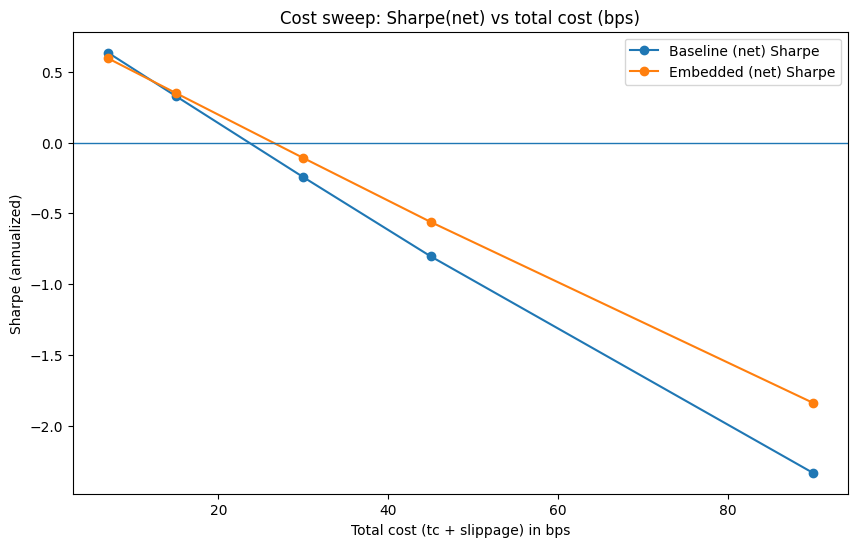

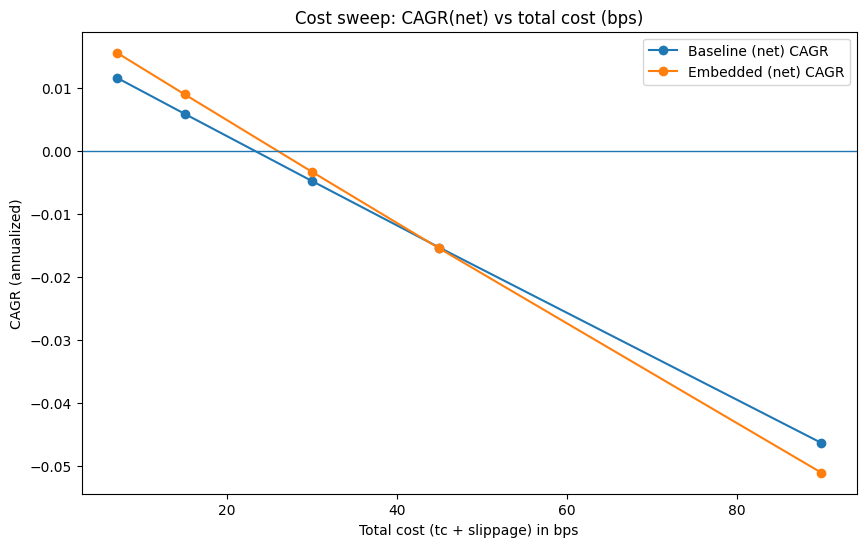

In [54]:

# ----------------------------
# 1) Cost + slippage sweep (FAST)
# ----------------------------

COST_GRID = [
    (5.0, 2.0),   # tc, slip (bps)
    (10.0, 5.0),
    (20.0, 10.0),
    (30.0, 15.0),
    (60.0, 30.0),
]

rows = []
for tc, slip in COST_GRID:
    base_rc = recompute_net_from_gross_and_turnover(out_ls["baseline"], tc, slip)
    emb_rc  = recompute_net_from_gross_and_turnover(out_ls["embedded"], tc, slip)

    s_base = perf_summary_with_turnover(base_rc, which="net_recosted")
    s_emb  = perf_summary_with_turnover(emb_rc,  which="net_recosted")

    rows.append({
        "tc_bps_per_side": tc,
        "slip_bps": slip,
        "total_bps": tc + slip,
        "baseline_sharpe": s_base.get("Sharpe", np.nan),
        "embedded_sharpe": s_emb.get("Sharpe", np.nan),
        "baseline_cagr": s_base.get("CAGR", np.nan),
        "embedded_cagr": s_emb.get("CAGR", np.nan),
        "baseline_maxdd": s_base.get("MaxDD", np.nan),
        "embedded_maxdd": s_emb.get("MaxDD", np.nan),
        "baseline_final_eq": s_base.get("FinalEquity", np.nan),
        "embedded_final_eq": s_emb.get("FinalEquity", np.nan),
        "avg_turnover_baseline": s_base.get("AvgTurnover", np.nan),
        "avg_turnover_embedded": s_emb.get("AvgTurnover", np.nan),
    })

cost_df = pd.DataFrame(rows).sort_values("total_bps")
display(cost_df)

# Plot: Sharpe vs total cost (two lines)
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_sharpe"], marker="o", label="Baseline (net) Sharpe")
plt.plot(cost_df["total_bps"], cost_df["embedded_sharpe"], marker="o", label="Embedded (net) Sharpe")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: Sharpe(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("Sharpe (annualized)")
plt.legend()
plt.show()

# Optional: CAGR vs cost
plt.figure(figsize=(10,6))
plt.plot(cost_df["total_bps"], cost_df["baseline_cagr"], marker="o", label="Baseline (net) CAGR")
plt.plot(cost_df["total_bps"], cost_df["embedded_cagr"], marker="o", label="Embedded (net) CAGR")
plt.axhline(0.0, linewidth=1)
plt.title("Cost sweep: CAGR(net) vs total cost (bps)")
plt.xlabel("Total cost (tc + slippage) in bps")
plt.ylabel("CAGR (annualized)")
plt.legend()
plt.show()


In [55]:
ABL_EPOCHS = 3

# Reuse the same universe/tickers from the main run
ABL_TICKERS = out_ls["universe"]
ABL_TOP_N = len(ABL_TICKERS)

# Reuse the same feature batches used in the main run
ABL_FEATURE_BATCHES = out_ls.get("feature_batches", ["intraday_lagged"])

# Reuse the same strategy config
ABL_WEIGHT_MODE = "long_short"
ABL_GROSS_LONG = 1.0
ABL_GROSS_SHORT = 1.0
ABL_GAMMA = 0.0
ABL_MAX_W = 0.02
ABL_TC_BPS = 10.0
ABL_SLIP_BPS = 5.0
ABL_LAM = 0.8
ABL_LR = 1e-3

ABL_REBALANCE_RULE = "W-FRI"
ABL_SHOCK_CONSECUTIVE_DOWN = 3
ABL_PRED_SMOOTH_SPAN = 5

ABL_UNIVERSE_MODE = "buffered_v2"
ABL_UNIVERSE_BUFFER_MULT = 1.5
ABL_UNIVERSE_MIN_DOLV_SHORT = 5e6

ABL_SEQ_LEN = 20
ABL_TRAIN_END = "2017-12-31"
ABL_VAL_END = "2019-12-31"

In [56]:
def run_embedded_only_with_custom_feats(
    feats_override, y_override, *,
    tickers,
    universe_mask=None,
    seq_len=20,
    train_end="2017-12-31",
    val_end="2019-12-31",
    gamma=0.0,
    max_w=0.02,
    tc_bps=10.0,
    slip_bps=5.0,
    epochs=3,
    lr=1e-3,
    lam_embedded=0.8,
    weight_mode="long_short",
    gross_long=1.0,
    gross_short=1.0,
    rebalance_rule="D",
    shock_consecutive_down=0,
    shock_proxy_rets=None,
    pred_smooth_span=None,
):
    batches_all, feat_names = build_day_batches(
        feats_override,
        y_override,
        tickers=tickers,
        seq_len=seq_len,
        universe_mask=universe_mask,
    )

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    n_features = len(feat_names)

    model_emb = train_model(
        batches_train,
        batches_val,
        n_features,
        lam=lam_embedded,
        k_turn=0.05,
        k_conc=0.05,
        gamma=gamma,
        max_w=max_w,
        lr=lr,
        epochs=epochs,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
    )

    bt_emb = backtest_batches(
        model_emb,
        batches_test,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=gamma,
        max_w=max_w,
        weight_mode=weight_mode,
        gross_long=gross_long,
        gross_short=gross_short,
        rebalance_rule=rebalance_rule,
        shock_consecutive_down=shock_consecutive_down,
        shock_proxy_rets=shock_proxy_rets,
        pred_smooth_span=pred_smooth_span,
    )
    return bt_emb, feat_names

In [57]:
# Main OHLCV
data = download_ohlcv(
    list(dict.fromkeys(ABL_TICKERS + ["SPY"])),
    start="2010-01-01",
    end=None,
    auto_adjust=True,   # IMPORTANT: keep aligned with your current main run
)

# Optional structural context
context_data = None
if ("structural" in ABL_FEATURE_BATCHES) or ("interactions" in ABL_FEATURE_BATCHES):
    context_data = download_context_data(start="2010-01-01", end=None)

# Build full feature set with the same feature batches
feats_full, y_full = make_features(
    data,
    feature_batches=ABL_FEATURE_BATCHES,
    context_data=context_data,
)

# Build the same universe mask used by the strategy
if ABL_UNIVERSE_MODE == "buffered_v2":
    universe_mask = make_universe_mask_v2(
        data,
        tickers=ABL_TICKERS,
        target_n=ABL_TOP_N,
        min_dolv_short=ABL_UNIVERSE_MIN_DOLV_SHORT,
        buffer_mult=ABL_UNIVERSE_BUFFER_MULT,
    )
else:
    universe_mask = make_universe_mask(
        data,
        tickers=ABL_TICKERS,
        top_n=ABL_TOP_N,
    )

# Shock proxy consistent with the strategy
spy_rets_full = (data["Close"][["SPY"]] / data["Open"][["SPY"]] - 1.0)["SPY"]

feat_list = list(feats_full.keys())

In [58]:
results = []

# Full embedded model first
bt_full, _ = run_embedded_only_with_custom_feats(
    feats_full,
    y_full,
    tickers=ABL_TICKERS,
    universe_mask=universe_mask,
    seq_len=ABL_SEQ_LEN,
    train_end=ABL_TRAIN_END,
    val_end=ABL_VAL_END,
    gamma=ABL_GAMMA,
    max_w=ABL_MAX_W,
    tc_bps=ABL_TC_BPS,
    slip_bps=ABL_SLIP_BPS,
    epochs=ABL_EPOCHS,
    lr=ABL_LR,
    lam_embedded=ABL_LAM,
    weight_mode=ABL_WEIGHT_MODE,
    gross_long=ABL_GROSS_LONG,
    gross_short=ABL_GROSS_SHORT,
    rebalance_rule=ABL_REBALANCE_RULE,
    shock_consecutive_down=ABL_SHOCK_CONSECUTIVE_DOWN,
    shock_proxy_rets=spy_rets_full,
    pred_smooth_span=ABL_PRED_SMOOTH_SPAN,
)
s_full = perf_summary_with_turnover(bt_full, which="net")
results.append({"dropped_feature": "(none)", **s_full})

# Drop one at a time
for drop in feat_list:
    feats_abl = {k: v for k, v in feats_full.items() if k != drop}

    bt_abl, _ = run_embedded_only_with_custom_feats(
        feats_abl,
        y_full,
        tickers=ABL_TICKERS,
        universe_mask=universe_mask,
        seq_len=ABL_SEQ_LEN,
        train_end=ABL_TRAIN_END,
        val_end=ABL_VAL_END,
        gamma=ABL_GAMMA,
        max_w=ABL_MAX_W,
        tc_bps=ABL_TC_BPS,
        slip_bps=ABL_SLIP_BPS,
        epochs=ABL_EPOCHS,
        lr=ABL_LR,
        lam_embedded=ABL_LAM,
        weight_mode=ABL_WEIGHT_MODE,
        gross_long=ABL_GROSS_LONG,
        gross_short=ABL_GROSS_SHORT,
        rebalance_rule=ABL_REBALANCE_RULE,
        shock_consecutive_down=ABL_SHOCK_CONSECUTIVE_DOWN,
        shock_proxy_rets=spy_rets_full,
        pred_smooth_span=ABL_PRED_SMOOTH_SPAN,
    )

    s = perf_summary_with_turnover(bt_abl, which="net")
    results.append({"dropped_feature": drop, **s})

abl_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)
display(abl_df)

plt.figure(figsize=(11, 7))
tmp = abl_df.sort_values("Sharpe")
plt.barh(tmp["dropped_feature"], tmp["Sharpe"])
plt.title(f"Feature ablation: embedded Sharpe(net) | batches={ABL_FEATURE_BATCHES}")
plt.xlabel("Sharpe (annualized)")
plt.ylabel("Dropped feature")
plt.show()

Epoch 01 | train pnl -0.000010 | train mse 0.002202 | train turn 0.052727 | val pnl -0.000071 | val mse 0.000504 | val turn 0.001858
Epoch 02 | train pnl -0.000289 | train mse 0.001029 | train turn 0.018747 | val pnl -0.000059 | val mse 0.000223 | val turn 0.029128
Epoch 03 | train pnl -0.000291 | train mse 0.000787 | train turn 0.012363 | val pnl -0.000072 | val mse 0.000516 | val turn 0.000000
Epoch 01 | train pnl -0.000053 | train mse 0.002335 | train turn 0.061642 | val pnl +0.000071 | val mse 0.000393 | val turn 0.116109
Epoch 02 | train pnl +0.000250 | train mse 0.001095 | train turn 0.019094 | val pnl +0.000072 | val mse 0.003508 | val turn 0.000000
Epoch 03 | train pnl +0.000269 | train mse 0.000888 | train turn 0.010625 | val pnl +0.000093 | val mse 0.000241 | val turn 0.019405
Epoch 01 | train pnl +0.000224 | train mse 0.002382 | train turn 0.063328 | val pnl +0.000073 | val mse 0.001952 | val turn 0.000044
Epoch 02 | train pnl +0.000248 | train mse 0.001174 | train turn 0.01

KeyboardInterrupt: 

Epoch 01 | train pnl +0.000142 | train mse 0.002781 | train turn 0.065973 | val pnl -0.000070 | val mse 0.000665 | val turn 0.008406
Epoch 02 | train pnl -0.000241 | train mse 0.000995 | train turn 0.027849 | val pnl -0.000072 | val mse 0.000335 | val turn 0.000079
Epoch 03 | train pnl -0.000283 | train mse 0.000858 | train turn 0.026109 | val pnl -0.000072 | val mse 0.001686 | val turn 0.000000
Epoch 01 | train pnl +0.000052 | train mse 0.002754 | train turn 0.071604 | val pnl +0.000074 | val mse 0.001074 | val turn 0.000556
Epoch 02 | train pnl -0.000034 | train mse 0.001232 | train turn 0.023906 | val pnl +0.000011 | val mse 0.000189 | val turn 0.184337
Epoch 03 | train pnl +0.000276 | train mse 0.000986 | train turn 0.018370 | val pnl +0.000072 | val mse 0.001937 | val turn 0.000000
Epoch 01 | train pnl +0.000100 | train mse 0.002823 | train turn 0.055303 | val pnl +0.000072 | val mse 0.001479 | val turn 0.000000
Epoch 02 | train pnl +0.000243 | train mse 0.001010 | train turn 0.01

,dropped_feature,CAGR,Sharpe,MaxDD,AvgTurnover,FinalEquity,N
2,mom60,0.064697,0.748791,-0.087494,0.000014,1.473054,1557
3,mom252,0.064657,0.748364,-0.087536,0.000000,1.472714,1557
5,vol20,0.064657,0.748364,-0.087536,0.000000,1.472714,1557
1,mom20,0.063111,0.741225,-0.085084,0.004996,1.459544,1557
8,volz20,0.059272,0.722351,-0.086006,0.002336,1.427289,1557
9,rsi14,0.039270,0.540933,-0.095970,0.035332,1.268692,1557
4,rev5,0.009123,0.344744,-0.039839,0.034984,1.057714,1557
6,prc_ma20,-0.067956,-0.747216,-0.364838,0.001149,0.647382,1557
7,prc_ma60,-0.067266,-0.887349,-0.360934,0.033136,0.650348,1557
0,(none),-0.080976,-1.053537,-0.418006,0.068875,0.593487,1557


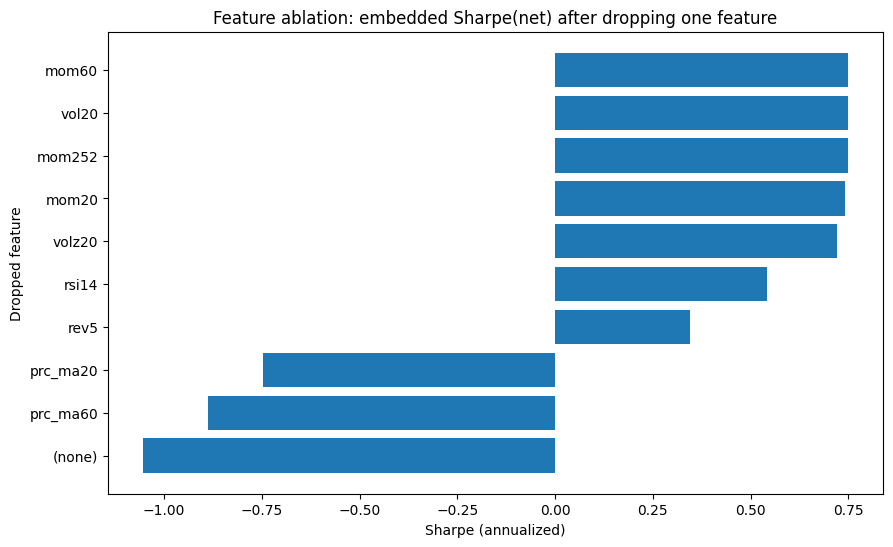

In [ ]:

# ----------------------------
# 2) Feature ablation (RETRAIN; SLOWER)
# ----------------------------
# Idea: remove one feature at a time, retrain embedded model, test on the same splits.

ABL_EPOCHS = 3  # lower this to go faster

ABL_TICKERS = out_ls["universe"]
ABL_TOP_N = len(ABL_TICKERS)

def run_embedded_only_with_custom_feats(
    feats_override, y_override, *,
    tickers, seq_len=20,
    train_end="2017-12-31", val_end="2019-12-31",
    gamma=0.0, max_w=0.02,
    tc_bps=10.0, slip_bps=5.0,
    epochs=3, lr=1e-3, lam_embedded=0.8,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
):
    batches_all, feat_names = build_day_batches(feats_override, y_override, tickers=tickers, seq_len=seq_len)

    train_end_dt = pd.to_datetime(train_end)
    val_end_dt = pd.to_datetime(val_end)

    batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
    batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
    batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

    n_features = len(feat_names)

    model_emb = train_model(
        batches_train, batches_val, n_features,
        lam=lam_embedded, k_turn=0.05, k_conc=0.05,
        gamma=gamma, max_w=max_w,
        lr=lr, epochs=epochs,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short,
    )

    bt_emb = backtest_batches(
        model_emb, batches_test,
        tc_bps_per_side=tc_bps, slip_bps=slip_bps,
        gamma=gamma, max_w=max_w,
        weight_mode=weight_mode, gross_long=gross_long, gross_short=gross_short
    )
    return bt_emb, feat_names

# Re-download data (yfinance variability warning). If you want perfect reproducibility, cache data locally.
data = download_ohlcv(list(dict.fromkeys(ABL_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_full, y_full = make_features(data)

feat_list = list(feats_full.keys())

results = []

# Full embedded model first
bt_full, _ = run_embedded_only_with_custom_feats(
    feats_full, y_full,
    tickers=ABL_TICKERS,
    epochs=ABL_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
s_full = perf_summary_with_turnover(bt_full, which="net")
results.append({"dropped_feature": "(none)", **s_full})

# Drop one at a time
for drop in feat_list:
    feats_abl = {k:v for k,v in feats_full.items() if k != drop}
    bt_abl, _ = run_embedded_only_with_custom_feats(
        feats_abl, y_full,
        tickers=ABL_TICKERS,
        epochs=ABL_EPOCHS,
        weight_mode="long_short", gross_long=1.0, gross_short=1.0
    )
    s = perf_summary_with_turnover(bt_abl, which="net")
    results.append({"dropped_feature": drop, **s})

abl_df = pd.DataFrame(results).sort_values("Sharpe", ascending=False)
display(abl_df)

# Plot: Sharpe by ablation
plt.figure(figsize=(10,6))
tmp = abl_df.sort_values("Sharpe")
plt.barh(tmp["dropped_feature"], tmp["Sharpe"])
plt.title("Feature ablation: embedded Sharpe(net) after dropping one feature")
plt.xlabel("Sharpe (annualized)")
plt.ylabel("Dropped feature")
plt.show()


In [ ]:

# ----------------------------
# 3) Placebo: shuffle Y in TRAINING (RETRAIN; should kill edge)
# ----------------------------
# Shuffle labels within each day across tickers for train+val only, then evaluate on real test.

PLACEBO_EPOCHS = 3
PLACEBO_TICKERS = out_ls["universe"]

data_p = download_ohlcv(list(dict.fromkeys(PLACEBO_TICKERS + ["SPY"])), start="2010-01-01", end=None, auto_adjust=False)
feats_p, y_p = make_features(data_p)

batches_all, feat_names = build_day_batches(feats_p, y_p, tickers=PLACEBO_TICKERS, seq_len=20)

train_end_dt = pd.to_datetime("2017-12-31")
val_end_dt = pd.to_datetime("2019-12-31")
batches_train = [b for b in batches_all if pd.to_datetime(b[0]) <= train_end_dt]
batches_val   = [b for b in batches_all if train_end_dt < pd.to_datetime(b[0]) <= val_end_dt]
batches_test  = [b for b in batches_all if pd.to_datetime(b[0]) > val_end_dt]

def shuffle_batch_Y(batches, seed):
    rng = np.random.default_rng(seed)
    out = []
    for (dt, X, Y) in batches:
        Y2 = Y.copy()
        rng.shuffle(Y2)  # permutes across tickers within the day
        out.append((dt, X, Y2))
    return out

batches_train_shuf = shuffle_batch_Y(batches_train, seed=1)
batches_val_shuf   = shuffle_batch_Y(batches_val,   seed=2)

n_features = len(feat_names)

print("Training placebo baseline (MSE only) on shuffled labels...")
model_base_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.0, k_turn=0.0, k_conc=0.0,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nTraining placebo embedded on shuffled labels...")
model_emb_p = train_model(
    batches_train_shuf, batches_val_shuf, n_features,
    lam=0.8, k_turn=0.05, k_conc=0.05,
    gamma=0.0, max_w=0.02,
    lr=1e-3, epochs=PLACEBO_EPOCHS,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

bt_base_p = backtest_batches(
    model_base_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)
bt_emb_p = backtest_batches(
    model_emb_p, batches_test,
    tc_bps_per_side=10.0, slip_bps=5.0,
    gamma=0.0, max_w=0.02,
    weight_mode="long_short", gross_long=1.0, gross_short=1.0
)

print("\nPlacebo results (should be near 0 or negative after costs):")
print("Baseline placebo:", perf_summary_with_turnover(bt_base_p, "net"))
print("Embedded placebo:", perf_summary_with_turnover(bt_emb_p, "net"))

# Plot: placebo equity curves
plt.figure(figsize=(10,6))
plt.plot(bt_base_p["equity"], label="Baseline placebo equity")
plt.plot(bt_emb_p["equity"], label="Embedded placebo equity")
plt.title("Placebo (shuffled Y in training): equity curves on real test")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()
plt.show()


ValueError: too many values to unpack (expected 3)

,value
CAGR_p01,-0.046224
CAGR_p05,-0.005551
CAGR_p25,0.055491
CAGR_p50,0.099690
CAGR_p75,0.145844
CAGR_p95,0.217133
CAGR_p99,0.268854
CAGR_mean,0.101876
CAGR_std,0.067587
Sharpe_p01,-0.245599


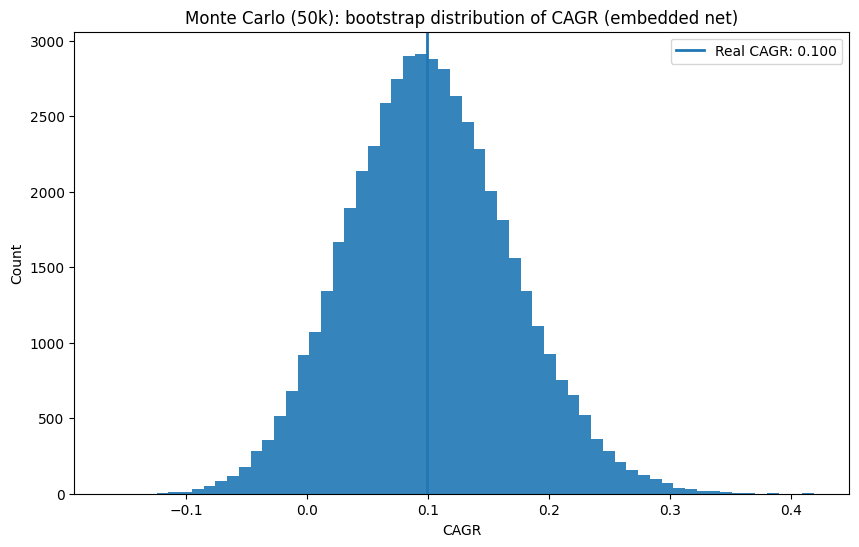

In [ ]:

# ----------------------------
# 4) Monte Carlo bootstrap (50k sims) on embedded NET returns
# ----------------------------
# Resampling Monte Carlo on realized daily returns.
# Note: IID bootstrap is fast but ignores volatility clustering; block bootstrap is more realistic.

MC_SIMS = 50_000
CHUNK = 1000  # adjust for memory/speed

r = out_ls["embedded"]["net"].dropna().values.astype(np.float64)
T = len(r)
freq = 252

if T < 50:
    raise RuntimeError("Not enough returns for Monte Carlo.")

def mc_metrics_chunk(r, n_sims, rng):
    idx = rng.integers(0, len(r), size=(n_sims, len(r)))
    R = r[idx]  # [n_sims, T]

    mu = R.mean(axis=1)
    sd = R.std(axis=1, ddof=0)
    sharpe = (mu / (sd + 1e-12)) * np.sqrt(freq)

    EQ = np.cumprod(1.0 + R, axis=1)
    final_eq = EQ[:, -1]
    cagr = final_eq ** (freq / T) - 1.0

    peak = np.maximum.accumulate(EQ, axis=1)
    dd = EQ / (peak + 1e-12) - 1.0
    mdd = dd.min(axis=1)

    return sharpe, cagr, mdd

rng = np.random.default_rng(12345)
sharpes = np.empty(MC_SIMS, dtype=np.float64)
cagrs   = np.empty(MC_SIMS, dtype=np.float64)
mdds    = np.empty(MC_SIMS, dtype=np.float64)

pos = 0
while pos < MC_SIMS:
    n = min(CHUNK, MC_SIMS - pos)
    s, c, m = mc_metrics_chunk(r, n, rng)
    sharpes[pos:pos+n] = s
    cagrs[pos:pos+n]   = c
    mdds[pos:pos+n]    = m
    pos += n

def summarize_mc(arr, name):
    p = np.percentile(arr, [1, 5, 25, 50, 75, 95, 99])
    return {
        f"{name}_p01": p[0],
        f"{name}_p05": p[1],
        f"{name}_p25": p[2],
        f"{name}_p50": p[3],
        f"{name}_p75": p[4],
        f"{name}_p95": p[5],
        f"{name}_p99": p[6],
        f"{name}_mean": float(arr.mean()),
        f"{name}_std": float(arr.std(ddof=0)),
    }

mc_summary = {}
mc_summary.update(summarize_mc(cagrs, "CAGR"))
mc_summary.update(summarize_mc(sharpes, "Sharpe"))
mc_summary.update(summarize_mc(mdds, "MaxDD"))

mc_summary["P(CAGR<0)"] = float((cagrs < 0).mean())
mc_summary["P(Sharpe<0)"] = float((sharpes < 0).mean())
mc_summary["P(MaxDD<-0.3)"] = float((mdds < -0.3).mean())

display(pd.DataFrame([mc_summary]).T.rename(columns={0:"value"}))

# Plot: histogram of CAGR
plt.figure(figsize=(10,6))
plt.hist(cagrs, bins=60, alpha=0.9)
real_cagr = perf_summary_with_turnover(out_ls["embedded"], "net").get("CAGR", np.nan)
plt.axvline(real_cagr, linewidth=2, label=f"Real CAGR: {real_cagr:.3f}")
plt.title("Monte Carlo (50k): bootstrap distribution of CAGR (embedded net)")
plt.xlabel("CAGR")
plt.ylabel("Count")
plt.legend()
plt.show()


## MonteVarlo simulation

In [ ]:

# ============================================================
# (NEW) Freeze model + Market Monte Carlo (simulate the market)
# Uses the FINAL trained model (no retraining)
# ============================================================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded"):
    """
    Save the final trained model from the most recent run_experiment().
    This respects your workflow: run_experiment(...) -> out_ls exists,
    and we also expose LAST_MODEL_EMB/LAST_MODEL_BASE from inside run_experiment.
    """
    if which not in ("embedded","baseline"):
        raise ValueError("which must be 'embedded' or 'baseline'")

    model = LAST_MODEL_EMB if which=="embedded" else LAST_MODEL_BASE
    if model is None:
        raise RuntimeError("No trained model found. Run run_experiment(...) first.")

    meta = dict(
        which=which,
        feat_names=LAST_FEAT_NAMES,
        n_features=len(LAST_FEAT_NAMES),
        hidden=64,  # must match train_model() architecture
        seq_len=LAST_RUN_CFG["seq_len"],
        gamma=LAST_RUN_CFG["gamma"],
        max_w=LAST_RUN_CFG["max_w"],
        weight_mode=LAST_RUN_CFG["weight_mode"],
        gross_long=LAST_RUN_CFG["gross_long"],
        gross_short=LAST_RUN_CFG["gross_short"],
    )

    torch.save({"state_dict": model.state_dict(), "meta": meta}, path)
    print(f"Saved frozen {which} model to: {path}")
    return path

def load_frozen_model(path="frozen_embedded_longshort.pt", device=DEVICE):
    payload = torch.load(path, map_location=device)
    meta = payload["meta"]
    model = LSTMAlpha(n_features=meta["n_features"], hidden=meta["hidden"]).to(device)
    model.load_state_dict(payload["state_dict"])
    model.eval()
    print(f"Loaded frozen model from: {path}")
    return model, meta


# ----------------------------
# Market simulator (factor model + bull/bear regimes)
# ----------------------------
def calibrate_factor_model(data, tickers, k=3):
    """
    Calibrate a simple k-factor model from historical close-to-close log returns.
    This gives realistic cross-sectional correlation (important for long/short).
    """
    close = data["Close"][tickers].dropna()
    rets = np.log(close).diff().dropna()  # log returns, shape [T, N]
    R = rets.values
    mu = R.mean(axis=0)
    Rc = R - mu

    cov = np.cov(Rc, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]

    W = eigvecs[:, :k]
    S = np.diag(np.sqrt(np.maximum(eigvals[:k], 1e-12)))
    betas = W @ S  # [N, k]

    B = betas
    BtB_inv = np.linalg.pinv(B.T @ B)
    F = (BtB_inv @ B.T @ Rc.T).T  # factor returns [T, k]

    factor_mu = F.mean(axis=0)
    factor_cov = np.cov(F, rowvar=False)

    R_hat = F @ B.T
    E = Rc - R_hat
    resid_std = E.std(axis=0, ddof=0)

    calib = dict(
        tickers=tickers,
        start_prices=close.iloc[0].values,
        dates=close.index,
        betas=betas,
        factor_mu=factor_mu,
        factor_cov=factor_cov,
        resid_std=resid_std,
    )
    return calib

def simulate_ohlcv_factor_regime(
    calib,
    dates,
    seed=0,
    bull_mu_shift=0.0003,
    bear_mu_shift=-0.0008,
    bull_vol_mult=1.0,
    bear_vol_mult=1.6,
    p_switch=0.01,
    gap_frac=0.25,
    vol_logn_mu=12.0,
    vol_logn_sigma=0.7,
):
    """
    Produce a dict with keys Open, Close, Volume, High, Low matching your pipeline.
    """
    rng = np.random.default_rng(seed)
    tickers = calib["tickers"]
    n = len(tickers)
    T = len(dates)

    B = calib["betas"]
    f_mu = calib["factor_mu"]
    f_cov = calib["factor_cov"]
    eps_std = calib["resid_std"]
    Lf = np.linalg.cholesky(f_cov + 1e-12*np.eye(f_cov.shape[0]))

    reg = np.zeros(T, dtype=int)
    for t in range(1, T):
        if rng.random() < p_switch:
            reg[t] = 1 - reg[t-1]
        else:
            reg[t] = reg[t-1]

    open_px = np.zeros((T, n))
    close_px = np.zeros((T, n))
    volu = np.zeros((T, n))

    close_prev = calib["start_prices"].copy()

    for t in range(T):
        is_bear = (reg[t] == 1)
        mu_shift = bear_mu_shift if is_bear else bull_mu_shift
        vol_mult = bear_vol_mult if is_bear else bull_vol_mult

        zf = rng.standard_normal(Lf.shape[0])
        f_t = f_mu + (Lf @ zf) * vol_mult

        ze = rng.standard_normal(n)
        eps_t = ze * eps_std * vol_mult

        r_total = (B @ f_t) + eps_t + mu_shift  # log return close-to-close

        # Split into overnight gap + intraday move
        gap = rng.standard_normal(n) * (np.std(r_total) + 1e-6) * gap_frac
        intraday = r_total - gap

        open_t = close_prev * np.exp(gap)
        close_t = open_t * np.exp(intraday)

        # volume: lognormal base * (1 + activity)
        baseV = rng.lognormal(mean=vol_logn_mu, sigma=vol_logn_sigma, size=n)
        vol_t = baseV * (1.0 + 10.0*np.abs(intraday))

        open_px[t] = open_t
        close_px[t] = close_t
        volu[t] = vol_t
        close_prev = close_t

    df_open = pd.DataFrame(open_px, index=dates, columns=tickers)
    df_close = pd.DataFrame(close_px, index=dates, columns=tickers)
    df_vol = pd.DataFrame(volu, index=dates, columns=tickers)

    df_high = pd.DataFrame(np.maximum(df_open, df_close), index=dates, columns=tickers)
    df_low  = pd.DataFrame(np.minimum(df_open, df_close), index=dates, columns=tickers)

    return {"Open": df_open, "Close": df_close, "Volume": df_vol, "High": df_high, "Low": df_low, "regime": reg}


# ----------------------------
# Run frozen model on a simulated market
# ----------------------------
def backtest_frozen_on_simulated_market(
    model_frozen,
    meta,
    data_sim,
    tickers,
    tc_bps=10.0,
    slip_bps=5.0,
):
    feats, y = make_features(data_sim)
    batches_all, feat_names = build_day_batches(feats, y, tickers=tickers, seq_len=meta["seq_len"])

    bt = backtest_batches(
        model_frozen,
        batches_all,
        tc_bps_per_side=tc_bps,
        slip_bps=slip_bps,
        gamma=meta["gamma"],
        max_w=meta["max_w"],
        weight_mode=meta["weight_mode"],
        gross_long=meta["gross_long"],
        gross_short=meta["gross_short"],
    )
    return bt


def market_monte_carlo(
    model_frozen,
    meta,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=10.0,
    slip_bps=5.0,
    sim_params=None,
):
    """
    Monte Carlo market simulation with the frozen final model.
    Returns:
      eq_df: [date x sim] equity paths
      met_df: per-sim performance summary table
    """
    if sim_params is None:
        sim_params = {}

    dates = calib["dates"]
    tickers = calib["tickers"]

    equities = []
    rows = []

    for s in range(n_sims):
        data_sim = simulate_ohlcv_factor_regime(
            calib,
            dates=dates,
            seed=seed0 + s,
            **sim_params
        )
        bt = backtest_frozen_on_simulated_market(
            model_frozen, meta,
            data_sim=data_sim,
            tickers=tickers,
            tc_bps=tc_bps,
            slip_bps=slip_bps,
        )

        eq = bt["equity"].copy()
        equities.append(eq.rename(f"sim_{s}"))

        summ = perf_summary(bt["net"])
        summ["FinalEquity"] = float(eq.iloc[-1])
        rows.append(summ)

    eq_df = pd.concat(equities, axis=1)
    met_df = pd.DataFrame(rows)
    return eq_df, met_df


def plot_fanchart_and_variance(eq_df, title="Monte Carlo Equity Fan Chart"):
    eq = eq_df.ffill().dropna(how="all")
    mean = eq.mean(axis=1)
    p05 = eq.quantile(0.05, axis=1)
    p25 = eq.quantile(0.25, axis=1)
    p75 = eq.quantile(0.75, axis=1)
    p95 = eq.quantile(0.95, axis=1)
    var = eq.var(axis=1)

    plt.figure(figsize=(10,6))
    plt.plot(mean, label="Mean equity")
    plt.plot(p05, linestyle="--", alpha=0.7, label="p05")
    plt.plot(p95, linestyle="--", alpha=0.7, label="p95")
    plt.plot(p25, linestyle=":", alpha=0.7, label="p25")
    plt.plot(p75, linestyle=":", alpha=0.7, label="p75")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,6))
    plt.plot(var)
    plt.title("Variance of equity across simulations (robustness over time)")
    plt.xlabel("Date")
    plt.ylabel("Var(Equity)")
    plt.show()


def plot_metric_histograms(met_df, real_metrics=None):
    for col in ["CAGR", "Sharpe", "MaxDD", "FinalEquity"]:
        if col not in met_df.columns:
            continue
        plt.figure(figsize=(10,6))
        plt.hist(met_df[col].dropna().values, bins=50)
        if real_metrics is not None and col in real_metrics:
            plt.axvline(real_metrics[col])
        plt.title(f"Distribution of {col} across market simulations")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    if "CAGR" in met_df.columns:
        print("P(CAGR < 0):", float((met_df["CAGR"] < 0).mean()))
    if "Sharpe" in met_df.columns:
        print("P(Sharpe < 0):", float((met_df["Sharpe"] < 0).mean()))
    if "MaxDD" in met_df.columns:
        print("P(MaxDD < -0.30):", float((met_df["MaxDD"] < -0.30).mean()))


Saved frozen embedded model to: frozen_embedded_longshort.pt
Loaded frozen model from: frozen_embedded_longshort.pt


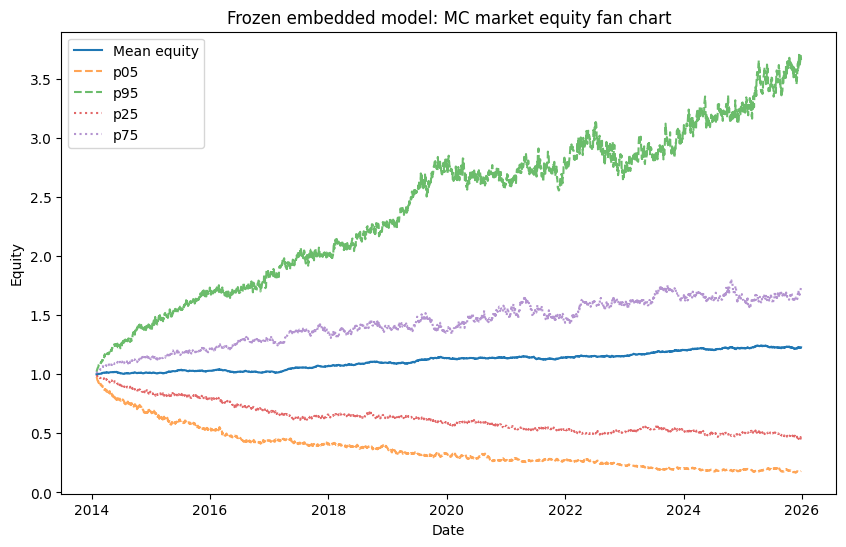

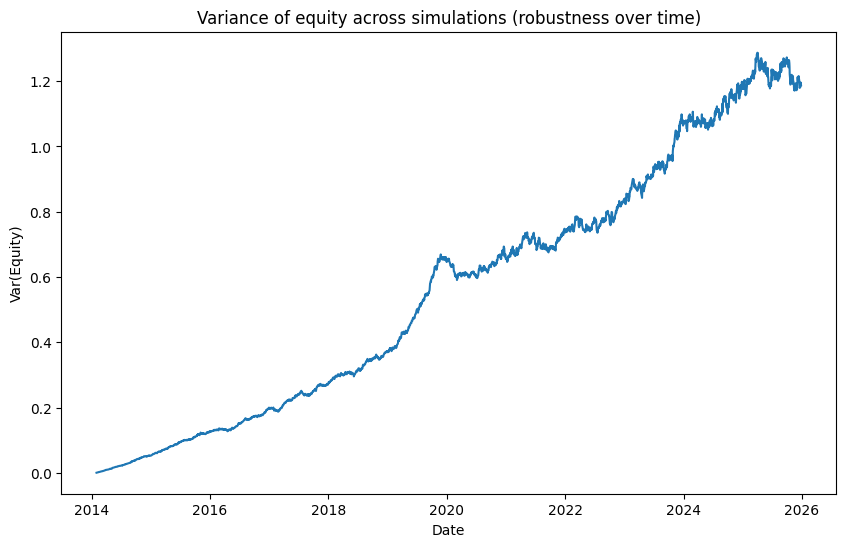

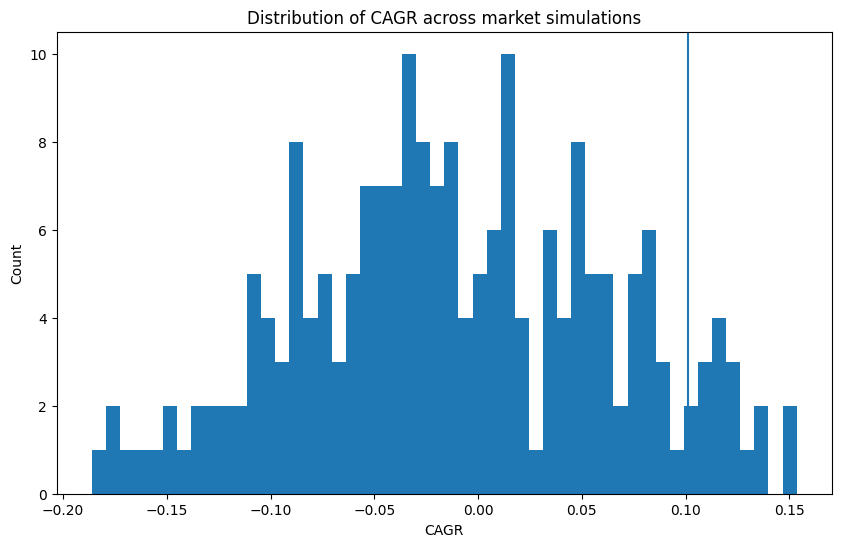

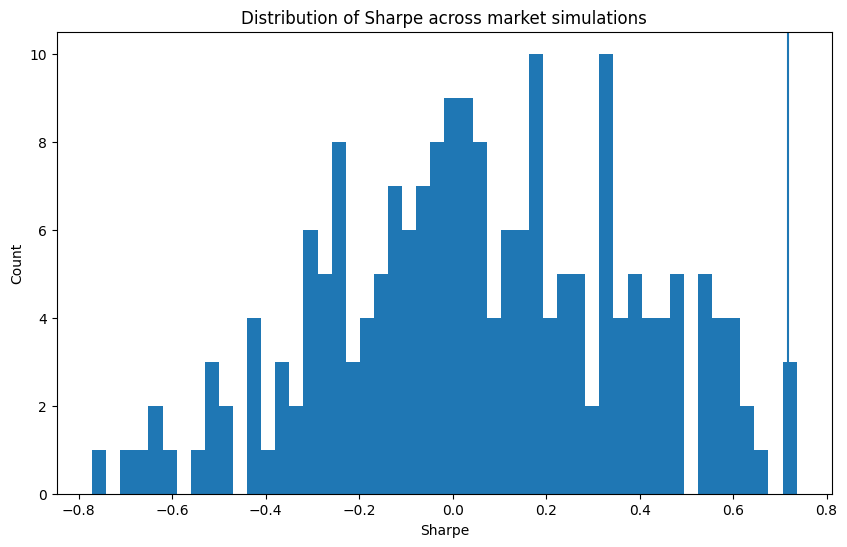

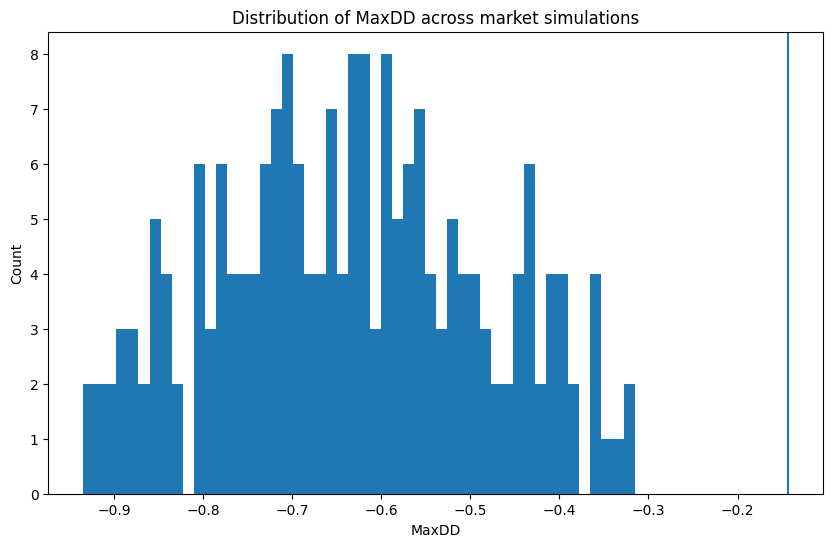

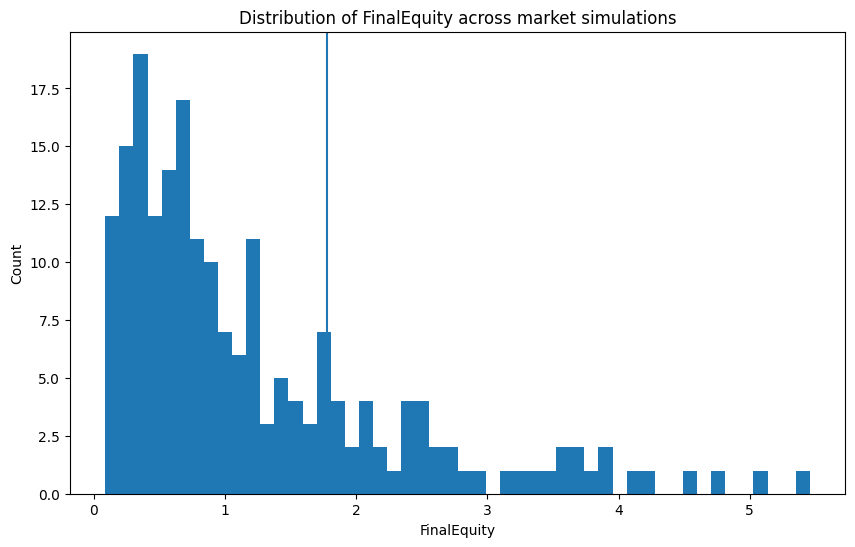

P(CAGR < 0): 0.575
P(Sharpe < 0): 0.43
P(MaxDD < -0.30): 1.0
Real (historical) metrics: {'CAGR': 0.10108238402341874, 'Sharpe': 0.7176726144467378, 'MaxDD': -0.14338132655938263, 'AvgDailyTurnover': 1.0, 'FinalEquity': 1.7772856139402502}
MC metrics summary (mean/median):


,CAGR,Sharpe,MaxDD,AvgDailyTurnover,FinalEquity
count,200.000000,200.000000,200.000000,200.0,200.000000
mean,-0.011388,0.061449,-0.635522,1.0,1.227895
std,0.074719,0.321026,0.149621,0.0,1.089712
min,-0.185997,-0.771031,-0.934805,1.0,0.086656
1%,-0.174114,-0.661144,-0.922030,1.0,0.102945
5%,-0.133992,-0.490930,-0.878215,1.0,0.180922
25%,-0.062633,-0.152296,-0.740026,1.0,0.463609
50%,-0.015517,0.051954,-0.635043,1.0,0.830631
75%,0.047652,0.316002,-0.528181,1.0,1.738919
95%,0.115373,0.581003,-0.390298,1.0,3.660891


In [ ]:

# ============================================================
# (NEW) How to run market Monte Carlo with your final model
# ============================================================

from IPython.display import display

# 1) Save the final trained embedded model from your last run_experiment()
frozen_path = save_frozen_model(path="frozen_embedded_longshort.pt", which="embedded")

# 2) Load it (to prove we are using the frozen final model)
model_frozen, meta_frozen = load_frozen_model(frozen_path, device=DEVICE)

# 3) Calibrate the market simulator from historical data for the SAME universe
tickers_sim = out_ls["universe"]
data_hist = download_ohlcv(tickers_sim, start="2010-01-01", end=None, auto_adjust=False)
calib = calibrate_factor_model(data_hist, tickers=tickers_sim, k=3)

# 4) Run market Monte Carlo (start with 200 sims; increase if you want)
#    Note: true "50k market sims" is usually too heavy; if you insist, raise n_sims carefully.
eq_mc, met_mc = market_monte_carlo(
    model_frozen,
    meta_frozen,
    calib,
    n_sims=200,
    seed0=123,
    tc_bps=out_ls.get("tc_bps", 10.0) if isinstance(out_ls, dict) else 10.0,
    slip_bps=out_ls.get("slip_bps", 5.0) if isinstance(out_ls, dict) else 5.0,
    sim_params=dict(
        # You can stress the market here:
        # bear_mu_shift=-0.0012,
        # p_switch=0.02,
        # bear_vol_mult=2.0,
    ),
)

# 5) Plot robustness over time: fan chart + variance curve
plot_fanchart_and_variance(eq_mc, title="Frozen embedded model: MC market equity fan chart")

# 6) Compare distributions to the REAL backtest metrics from your historical test set
real = perf_summary(out_ls["embedded"]["net"])
real["FinalEquity"] = float(out_ls["embedded"]["equity"].iloc[-1])

plot_metric_histograms(met_mc, real_metrics=real)

print("Real (historical) metrics:", real)
print("MC metrics summary (mean/median):")
display(met_mc.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]))
